In [1]:
from time import perf_counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.preprocessing import PolynomialFeatures
from scipy.integrate import solve_ivp
# from sklearn.linear_model import Lasso
# from scipy.io import loadmat
# from sklearn.metrics import mean_squared_error
from SindyODEs import lorenz

import torch

from EqLearner import EqLearner1D
from func_libraries import ODE_Poly_Deriv_Library
from sparse_regress_algs import SparseRegressAlg, RFE, Cross_Val_RFE, Cross_Val_RFE_V2, SSR
from data_sampling import Rand_Col_Sampler
# from PinnSrPlusPlusComparisonSettings import DefaultEQsModelParameters, OptimizedEQsModelParameters 
# from data_loaders import PDELearningMatDataVerB, PDELearningMatData
import Networks
from CustomActivationFuncs import SinAct, Rational

from extra_loss_functions import Torch_Lp_Loss
from PartialDerivFunctions import Nth_temporal_prtls
from EqLearner import solve_svd, Specified_Optim_Regres
from sparse_regress_algs import RFESparseRegression, Numpy_SSR

# integration keywords for solve_ivp, typically needed for chaotic systems
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "LSODA"
integrator_keywords["atol"] = 1e-12

d_seed = np.random.SeedSequence().entropy
rng = np.random.default_rng(d_seed)

In [2]:
def linear_damped_SHO(t, x):
    return [-0.1 * x[0] + 2 * x[1], -2 * x[0] - 0.1 * x[1]]


# Cubic, damped harmonic oscillator
def cubic_damped_SHO(t, x):
    return [
        -0.1 * x[0] ** 3 + 2 * x[1] ** 3,
        -2 * x[0] ** 3 - 0.1 * x[1] ** 3,
    ]


# Linear 3D toy system
def linear_3D(t, x):
    return [-0.1 * x[0] + 2 * x[1], -2 * x[0] - 0.1 * x[1], -0.3 * x[2]]


# Van der Pol ODE
def van_der_pol(t, x, p=[0.5]):
    return [x[1], p[0] * (1 - x[0] ** 2) * x[1] - x[0]]


# Duffing ODE
def duffing(t, x, p=[0.2, 0.05, 1]):
    return [x[1], -p[0] * x[1] - p[1] * x[0] - p[2] * x[0] ** 3]


# Lotka model
def lotka(t, x, p=[1, 10]):
    return [p[0] * x[0] - p[1] * x[0] * x[1], p[1] * x[0] * x[1] - 2 * p[0] * x[1]]


# Generic cubic oscillator model
def cubic_oscillator(t, x, p=[-0.1, 2, -2, -0.1]):
    return [p[0] * x[0] ** 3 + p[1] * x[1] ** 3, p[2] * x[0] ** 3 + p[3] * x[1] ** 3]


# Rossler model
def rossler(t, x, p=[0.2, 0.2, 5.7]):
    return [-x[1] - x[2], x[0] + p[0] * x[1], p[1] + (x[0] - p[2]) * x[2]]


# Hopf bifurcation model
def hopf(t, x, mu=-0.05, omega=1, A=1):
    return [
        mu * x[0] - omega * x[1] - A * x[0] * (x[0] ** 2 + x[1] ** 2),
        omega * x[0] + mu * x[1] - A * x[1] * (x[0] ** 2 + x[1] ** 2),
    ]

# Lorenz model
def lorenz(t, x, sigma=10, beta=2.66667, rho=28):
    return [
        sigma * (x[1] - x[0]),
        x[0] * (rho - x[2]) - x[1],
        x[0] * x[1] - beta * x[2],
    ]

In [3]:
dvc = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [4]:
# Generate measurement data
dt = 0.001
t_train = np.arange(0, 25, dt)
t_train_span = (t_train[0], t_train[-1])
u0_train = [2, 0]

# Simple Start Off Examples (From Original SINDy Paper)

#### First 2D Linear Harmonic Oscillator 

In [5]:
lin_har_ouput = solve_ivp(
    linear_damped_SHO, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
)

lin_evals = lin_har_ouput.y.T
sol_times = lin_har_ouput.t.T
lin_t = np.empty_like(lin_evals)
lin_t[1:-1] = (lin_evals[2:] - lin_evals[:-2])/(2*dt)
lin_t[0] = (-3*lin_evals[0] + 4*lin_evals[1] - lin_evals[2])/(2*dt)
lin_t[-1] = (1*lin_evals[-3] - 4*lin_evals[-2] + 3*lin_evals[-1])/(2*dt)

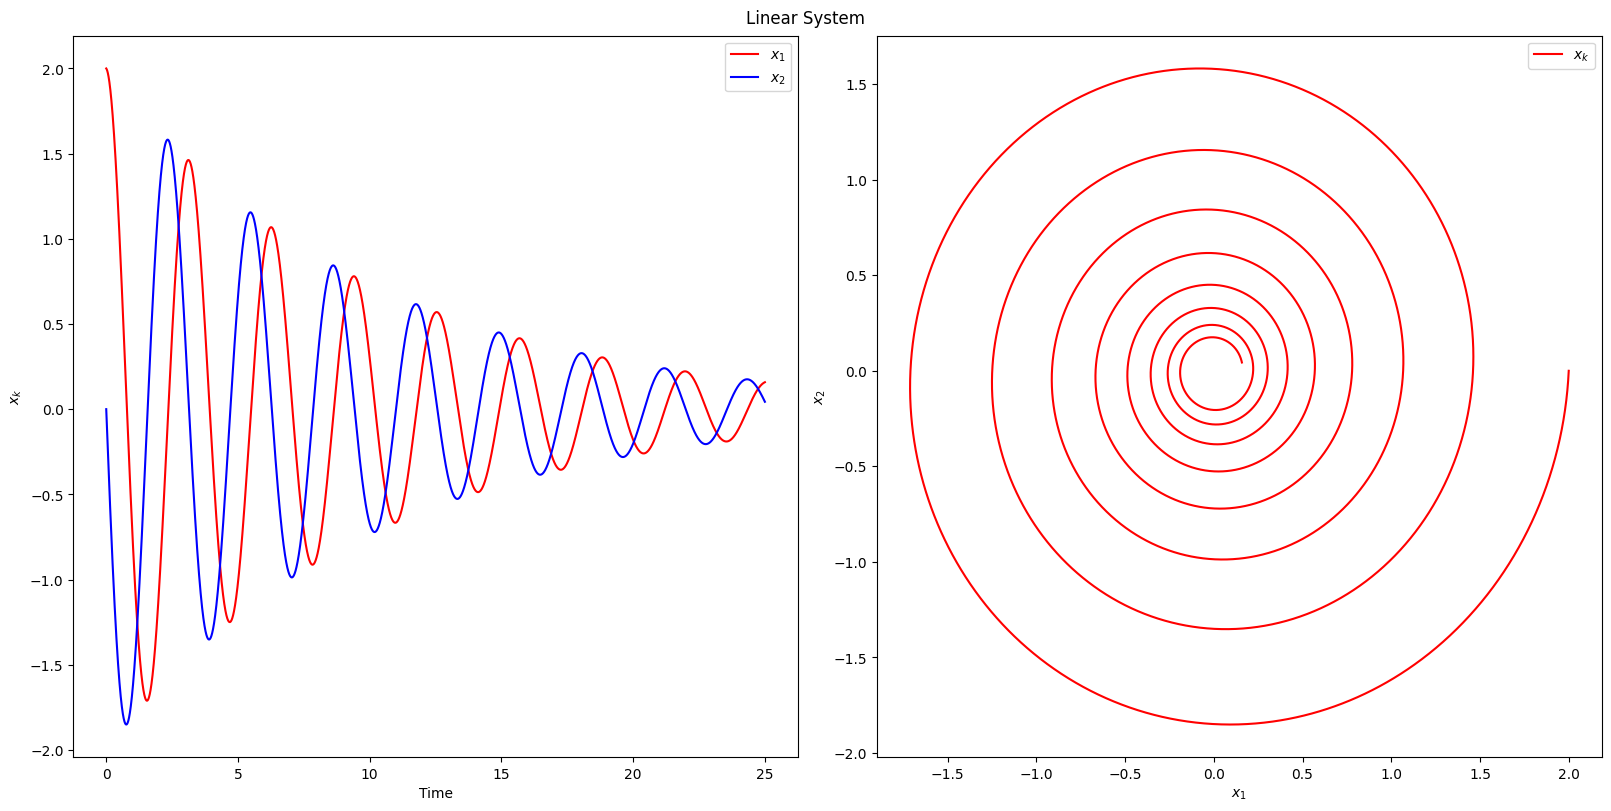

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(16,8))

axes[0].plot(t_train, lin_evals[:,0], 'r-', label=r"$x_{1}$")
axes[0].plot(t_train, lin_evals[:,1], 'b-', label=r"$x_{2}$")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$x_{k}$")
axes[0].legend()

axes[1].plot(lin_evals[:,0], lin_evals[:,1], 'r-', label=r"$x_{k}$")
axes[1].set_xlabel(r"$x_{1}$")
axes[1].set_ylabel(r"$x_{2}$")
axes[1].legend()

fig.suptitle("Linear System");

In [7]:
lin_evals.std()

np.float64(0.6300989570795903)

In [178]:
nDpnts = 5_000
nTst = nDpnts//4
# noise = 0.50
noise = 0.10

u_t = lin_evals + rng.normal(loc=0.0, scale=lin_evals.std()*noise, size=lin_evals.shape, )

# normalize since the 3 outputs are in differing ranges
normalize=False
if normalize:
    u_maxes = u_t.max(0)
    u_mins = u_t.min(0)
else:
    u_maxes = np.ones(shape=(2,))
    u_mins = np.zeros(shape=(2,))

data = (u_t - u_mins) / (u_maxes - u_mins)

pnts = np.copy(sol_times[:, np.newaxis])

trn_ids = rng.choice(a=np.arange(lin_evals.shape[0]), size=nDpnts, replace=False, )
valNtst_ids = np.setdiff1d(ar1=np.arange(lin_evals.shape[0]), ar2=trn_ids,)
tst_ids = rng.choice(a=valNtst_ids, size=nTst, replace=False)
val_ids = np.setdiff1d(valNtst_ids, tst_ids)

X_trn = np.copy( pnts[trn_ids, :])
U_trn = np.copy( data[trn_ids, :])
X_tst = np.copy( pnts[tst_ids, :])
U_tst = np.copy( data[tst_ids, :])

bounds = np.vstack((pnts.min(0), pnts.max(0)),).T

In [179]:
# slvr = RFE(alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=5)
# slvr = Cross_Val_RFE(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=ADO_iters)
# slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
slvr = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=6, thrshld_val=1e-8)
# slvr = SSR(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), percent_redux=0.70, criteria="coefficient_value", ADO_iters=ADO_iters, normalize=True)

In [180]:
libr = ODE_Poly_Deriv_Library(
        # poly_degree=2,
        poly_degree=4,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=0,
        include_bias=False,
        deriv_exclude_inds=None,
        device=dvc,
        data_type=torch.float32)

d_dict = {"Train_Inputs":X_trn, "Train_Targets":U_trn, "Test_Inputs":X_tst, "Test_Targets":U_tst}

col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=1, seed=None, 
                             bounds=bounds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)   

In [181]:
prd_stuff = None
four_stuff = {'scale':2.0, 'inpt_dim':X_trn.shape[1], 'embd_dim':20}
rnd_wght_fct = True

# prd_stuff = None
# four_stuff = None
# rnd_wght_fct = False

numLyrsU = 5
nPrLU = 56

In [182]:
if prd_stuff or four_stuff or rnd_wght_fct:
    # net = Networks.MLP(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,out_dim=U_trn.shape[1],
    #                 #   activ_func=torch.nn.Tanh(),
    #                   activ_func=SinAct(),
    #                   prd_stuff=prd_stuff, four_stuff=four_stuff,
    #                   rnd_wght_fct=rnd_wght_fct).to(device=dvc)
    
    net = Networks.PirateNet(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,
                             out_dim=U_trn.shape[1],
                             activ_func=torch.nn.Tanh(),
                            #  activ_func=SinAct(), 
                             alpha=0.0,
                             prd_stuff=prd_stuff, 
                             four_stuff=four_stuff, 
                             rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    net = torch.nn.Sequential(
            torch.nn.Linear(in_features=X_trn.shape[1], out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=U_trn.shape[1], bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in net.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)
    

In [183]:
libr.fit(network=net, inpts=torch.rand(size=(2,1), device=dvc, dtype=torch.float32))
lib_names = libr.get_library_names(net_out_func_names=["x", "y",])

init_lmbda = torch.zeros(size=(len(lib_names),2), device=dvc,)

lrnr = EqLearner1D(net=net,
        Lmbda=init_lmbda.requires_grad_(True),
        lib_func=libr,
        sprs_slvr=slvr,
        data_dict=d_dict,
        tmprl_ords=[1, 1],
        col_pnts_smplr=col_smplr,
        N_col_pnts=50_000,
        ntwk_out_names=["x", "y"],
        device=dvc,
        data_type=torch.float32
)

In [184]:
lrnr.lmbda

tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]], device='cuda:0', requires_grad=True)

In [185]:
run_time = 0
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="pre", alpha=0.001, gamma=1e-6, min_epochs=500, max_epochs=10_000, 
                        lrn_rt=0.001, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.30191e+00 | 1.18298e+00 | 0.0000e+00
            | Test Data  | 1.41713e+00 | 1.17000e+00 | 
Epoch   200 | Train Data | 2.22937e-02 | 1.40250e+00 | 3.3711e+00
            | Test Data  | 2.75978e-02 | 1.36873e+00 | 
Epoch   400 | Train Data | 7.99427e-03 | 6.70726e-01 | 3.8065e+00
            | Test Data  | 8.44688e-03 | 6.45131e-01 | 
Epoch   600 | Train Data | 7.76911e-03 | 4.23103e-01 | 4.1694e+00
            | Test Data  | 8.17427e-03 | 4.02149e-01 | 
Epoch   800 | Train Data | 7.74307e-03 | 3.48231e-01 | 4.8492e+00
            | Test Data  | 8.15910e-03 | 3.35990e-01 | 
Epoch  1000 | Train Data | 7.72982e-03 | 3.04434e-01 | 5.2841e+00
            | Test Data  | 8.15658e-03 | 2.96944e-01 | 
Epoch  1200 | Train Data | 7.72005e-03 | 2.67581e-01 | 5.5640e+00
            | Tes

In [186]:
lrnr.lmbda

tensor([[-1.1852e-01, -1.7195e+00],
        [ 1.6855e+00, -7.4934e-02],
        [-6.3731e-05, -7.0016e-05],
        [ 5.1629e-05,  6.2044e-02],
        [-9.3071e-02,  4.0889e-05],
        [ 2.4676e-02, -1.1803e-01],
        [ 1.6204e-01, -6.1529e-02],
        [ 1.3346e-02, -1.4487e-01],
        [ 1.3548e-01, -3.2391e-03],
        [ 9.1578e-03,  8.1098e-03],
        [ 3.0335e-02, -2.2492e-02],
        [ 5.4190e-02, -4.0247e-02],
        [-1.8148e-04, -7.2112e-02],
        [ 4.7193e-02,  2.5530e-04]], device='cuda:0', requires_grad=True)

In [187]:
lrnr.Learned_EQ(output=True, dec_rnd=3);

The current Learned Equation(s) is(are) ... 
x_t = -1.19000000e-01*x + 1.68500000e+00*y + -9.30000000e-02*(y)^2 + 2.50000000e-02*(x)^3 + 1.62000000e-01*(x)^2(y) + 1.30000000e-02*(x)(y)^2 + 1.35000000e-01*(y)^3 + 9.00000000e-03*(x)^4 + 3.00000000e-02*(x)^3(y) + 5.40000000e-02*(x)^2(y)^2 + 4.70000000e-02*(y)^4
y_t = -1.72000000e+00*x + -7.50000000e-02*y + 6.20000000e-02*(x)(y) + -1.18000000e-01*(x)^3 + -6.20000000e-02*(x)^2(y) + -1.45000000e-01*(x)(y)^2 + -3.00000000e-03*(y)^3 + 8.00000000e-03*(x)^4 + -2.20000000e-02*(x)^3(y) + -4.00000000e-02*(x)^2(y)^2 + -7.20000000e-02*(x)(y)^3 


In [172]:
net_preds = lrnr.net(torch.from_numpy(sol_times[:,np.newaxis]).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

C:\Users\urzua\AppData\Local\Temp\ipykernel_46548\1984113170.py:5: RuntimeWarning: divide by zero encountered in divide
  mn_rel_errs = np.abs(lin_evals - net_preds) / np.abs(lin_evals)


MSE = [0.00041412 0.00047568], Mean ABS = [0.01601186 0.01739072], Mean Rel Error = [0.21246038 0.28686126]


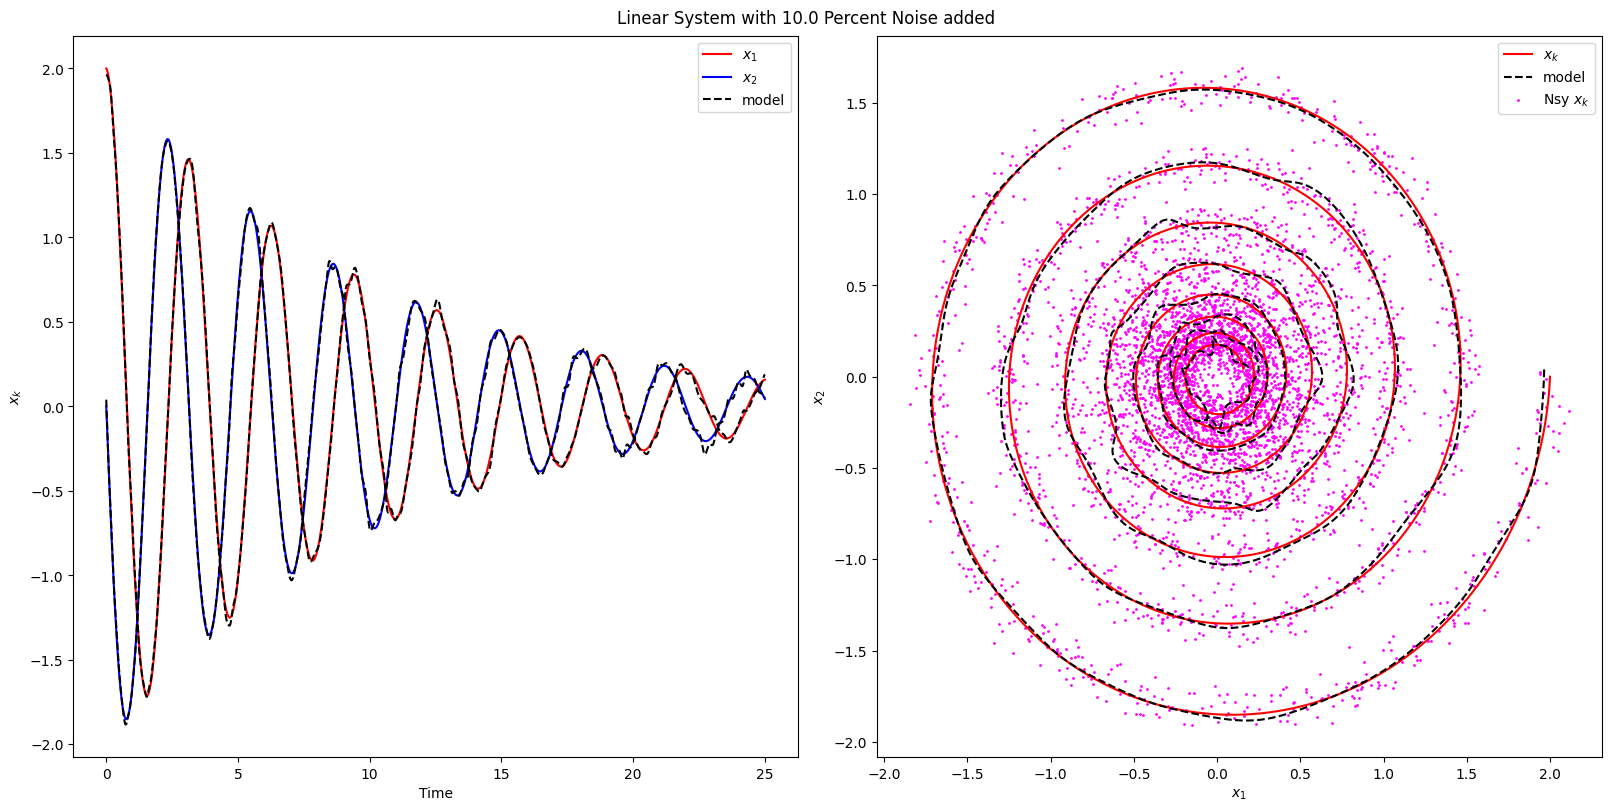

In [206]:
fig, axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(16,8))

mse = np.mean((lin_evals - net_preds)**2, axis=0)
mn_abs_err = np.mean(np.abs(lin_evals - net_preds), axis=0)
mn_rel_errs = np.abs(lin_evals - net_preds) / np.abs(lin_evals)
mn_rel_errs = np.where(np.logical_not(np.isfinite(mn_rel_errs)), np.abs(lin_evals - net_preds), mn_rel_errs)
print(f"MSE = {mse}, Mean ABS = {mn_abs_err}, Mean Rel Error = {np.mean(mn_rel_errs, axis=0)}")

axes[0].plot(t_train, lin_evals[:,0], 'r-', label=r"$x_{1}$")
axes[0].plot(t_train, lin_evals[:,1], 'b-', label=r"$x_{2}$")
axes[0].plot(t_train, net_preds[:,0], 'k--', label="model")
# axes[0].scatter(x=X_trn, y=U_trn[:,0], s=2.0, marker='.', color='red', label=r"noisy $x_{1}$")
# axes[0].scatter(x=X_trn, y=U_trn[:,1], s=2.0, marker='.', color='blue', label=r"noisy $x_{2}$")
axes[0].plot(t_train, net_preds[:,1], 'k--', )
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"$x_{k}$")
axes[0].legend()

axes[1].plot(lin_evals[:,0], lin_evals[:,1], 'r-', label=r"$x_{k}$")
axes[1].plot(net_preds[:,0], net_preds[:,1], 'k--', label="model")
axes[1].scatter(x=U_trn[:,0], y=U_trn[:,1], s=4.0, marker=".",color="magenta", label=r"Nsy $x_{k}$")
# axes[1].plot(U_trn[:,0], U_trn[:,1], 'm.', label=r"Nsy $x_k{k}$")

axes[1].set_xlabel(r"$x_{1}$")
axes[1].set_ylabel(r"$x_{2}$")
axes[1].legend()

fig.suptitle(f"Linear System with {noise*100} Percent Noise added");

In [189]:
col_pnts = torch.from_numpy(col_smplr.sample(50_000)).to(device=dvc, dtype=lrnr.data_type).requires_grad_(True)
col_prds = net(col_pnts)
t_prtls = Nth_temporal_prtls(values=col_prds, pts=col_pnts, orders=lrnr.tmprl_ords).detach()
lib_evals = lrnr.lib_func.Calc(network=lrnr.net, inpts=col_pnts).detach()

In [190]:
combs = PolynomialFeatures._combinations(
            n_features=2,
            min_degree=1,
            max_degree=4,
            interaction_only=False,
            include_bias=False,
        )
exact_lib = np.empty(shape=(lin_evals.shape[0], lib_evals.size(1)))
exact_lib[:,:2] = lin_evals

for i, combo in enumerate(combs):
    exact_lib[:,i] = np.prod(exact_lib[:, combo], axis=1)

exct_trch_lib = torch.from_numpy(exact_lib).to(device=dvc, dtype=torch.float32)
exct_trch_t = torch.from_numpy(lin_t).to(device=dvc, dtype=torch.float32)

In [191]:
torch.linalg.lstsq(exct_trch_lib, exct_trch_t)[0]

tensor([[-1.0000e-01, -2.0000e+00],
        [ 2.0000e+00, -1.0000e-01],
        [-1.9296e-08,  1.0602e-07],
        [-1.7804e-07,  5.8477e-07],
        [-3.7037e-08, -1.0255e-07],
        [ 1.7378e-08,  1.7863e-07],
        [-1.6844e-08,  3.7458e-08],
        [ 5.1233e-08,  3.1873e-07],
        [-9.6929e-08,  2.4297e-08],
        [ 2.9506e-08, -2.8389e-08],
        [ 9.0061e-08, -1.2485e-07],
        [-2.8318e-08, -3.9856e-08],
        [ 5.7938e-08, -1.6561e-07],
        [ 5.7443e-09,  4.5955e-08]], device='cuda:0')

In [192]:
torch.linalg.lstsq(lib_evals[:, [0,1]], t_prtls)[0]

tensor([[-0.0955, -2.0059],
        [ 1.9954, -0.0986]], device='cuda:0')

In [193]:
gready_sparse = Specified_Optim_Regres(A=lib_evals, b=t_prtls[:,0:1], activ_ids=list(range(len(lib_names))), alpha=0.0 )
# gready_sparse =Specified_Optim_Regres(A=exct_trch_lib, b=exct_trch_t[:,1:2], activ_ids=list(range(len(lib_names))), alpha=0.0 )

In [194]:
gready_sparse[:,-3]

tensor([-0.0955,  1.9954,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000], device='cuda:0')

In [195]:
RFESparseRegression(A=exct_trch_lib, b=exct_trch_t[:,1:2], annealing_factor=2, best=True)

(tensor([[-2.0000e+00],
         [-1.0000e-01],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 1.1274e-08],
         [ 3.2579e-08],
         [ 0.0000e+00],
         [ 4.5555e-08],
         [ 0.0000e+00],
         [ 0.0000e+00],
         [ 3.4634e-08],
         [-3.2478e-08],
         [ 0.0000e+00],
         [-1.6589e-08]], device='cuda:0'),
 tensor([[-2.0000],
         [-0.1000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000],
         [ 0.0000]], device='cuda:0'))

In [196]:
RFESparseRegression(A=lib_evals, b=t_prtls[:,:1], annealing_factor=2, best=True)

(tensor([[-0.1244],
         [ 1.9804],
         [ 0.0000],
         [ 0.0000],
         [-0.0037],
         [ 0.0253],
         [ 0.0348],
         [ 0.0000],
         [ 0.0000],
         [ 0.0079],
         [ 0.0352],
         [ 0.0000],
         [-0.0125],
         [ 0.0000]], device='cuda:0'),
 tensor([[0.0000],
         [2.0001],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000],
         [0.0000]], device='cuda:0'))

In [28]:
if lrnr.lmbda.nonzero().size(0)==0:
    lrnr.lmbda.data = torch.ones_like(lrnr.lmbda.data)

In [29]:
lrnr.sprs_slvr.cmplted_ADO_iter

0

In [198]:
lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=True, Save_File_Name=None, Early_RFE_Term=True, p=0.5)
# lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)
# lrnr.ADO_Training(iters=0, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
x_t = -1.24954840e-01*x + 1.98069715e+00*y + -4.03920000e-03*(y)^2 + 2.60942400e-02*(x)^3 + 3.43325400e-02*(x)^2(y) + 8.10950000e-03*(x)^4 + 3.54333600e-02*(x)^3(y) + -1.26535800e-02*(x)(y)^3 
y_t = -2.00159764e+00*x + -8.74159000e-02*y + 1.50764500e-02*(x)^2 + -3.25465900e-02*(x)^2(y) + -1.21918500e-02*(x)(y)^2 + 3.31217900e-02*(x)^3(y) + -3.26477500e-02*(x)^2(y)^2 + -4.24132800e-02*(x)(y)^3 
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 7.59077e-03 | 5.70853e-02 | 4.4833e+00
            | Test Data  | 8.50214e-03 | 4.69379e-02 | 
Epoch   100 | Train Data | 7.91627e-03 | 2.61131e-04 | 4.4603e+00
            | Test Data  | 7.96159e-03 | 2.61302e-04 | 
Epoch   200 | Train Data | 7.91594e-03 | 1.08831e-04 | 4.4038e+00
            | Test Data  | 7.95940e-

In [199]:
lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
x_t = -1.00844920e-01*x + 1.99528468e+00*y 
y_t = -2.00419974e+00*x + -9.78394700e-02*y 


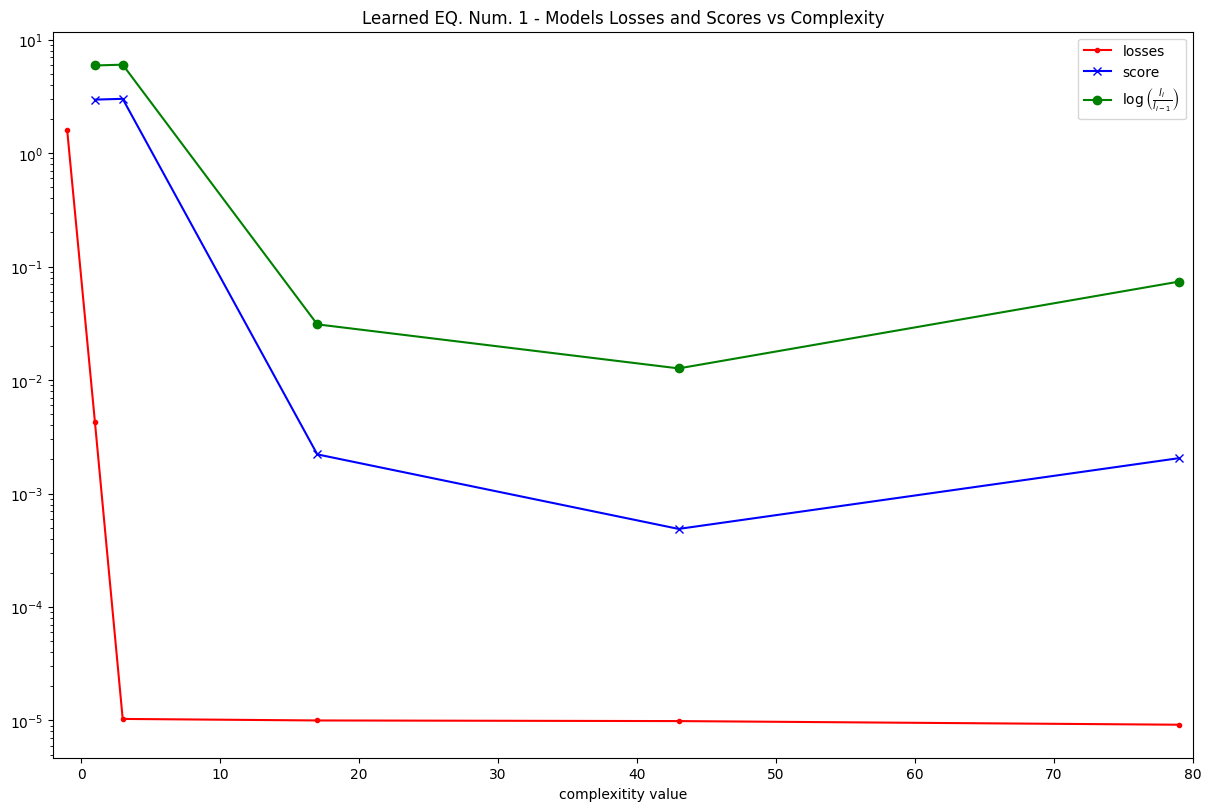

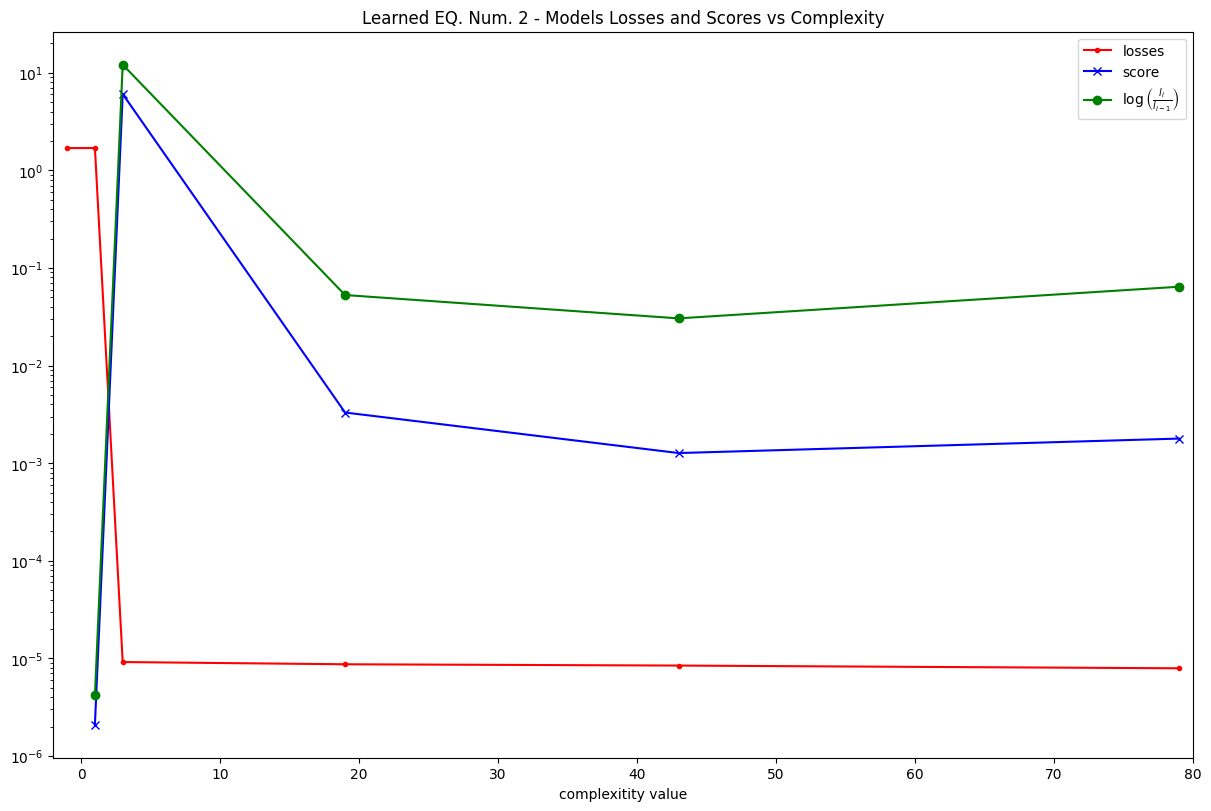

In [200]:
lrnr.Loss_Score_Complexity_Plot(dataset_name="Test", save_dir_name="LinearHarmonic", save_figs=False)

In [201]:
eq1_ls = np.array(lrnr._model_losses[0])

In [202]:
eq1_plx = np.array(lrnr._model_complxtys[0])

In [204]:
# eq1_plx
eq1_plx[0]=0

In [205]:
-np.log(eq1_ls[1:]/eq1_ls[:-1]) / (eq1_plx[1:] - eq1_plx[:-1])

array([5.93216753e+00, 3.01506305e+00, 2.21375043e-03, 4.87599343e-04,
       2.05007320e-03])

In [44]:
-np.log(eq1_ls[1:]/eq1_ls[:-1]) / (eq1_plx[1:] - eq1_plx[:-1])

array([3.02961636e+00, 4.50584745e+00, 1.22220337e-03, 1.11333691e-03,
       8.63410605e-05, 3.60376955e-04])

#### First 2D Cubic Harmonic Oscillator 

In [8]:
cub_har_ouput = solve_ivp(
    cubic_damped_SHO, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
)

cub_evals = cub_har_ouput.y.T
sol_times = cub_har_ouput.t.T
cub_t = np.empty_like(cub_evals)
cub_t[1:-1] = (cub_evals[2:] - cub_evals[:-2])/(2*dt)
cub_t[0] = (-3*cub_evals[0] + 4*cub_evals[1] - cub_evals[2])/(2*dt)
cub_t[-1] = (1*cub_evals[-3] - 4*cub_evals[-2] + 3*cub_evals[-1])/(2*dt)

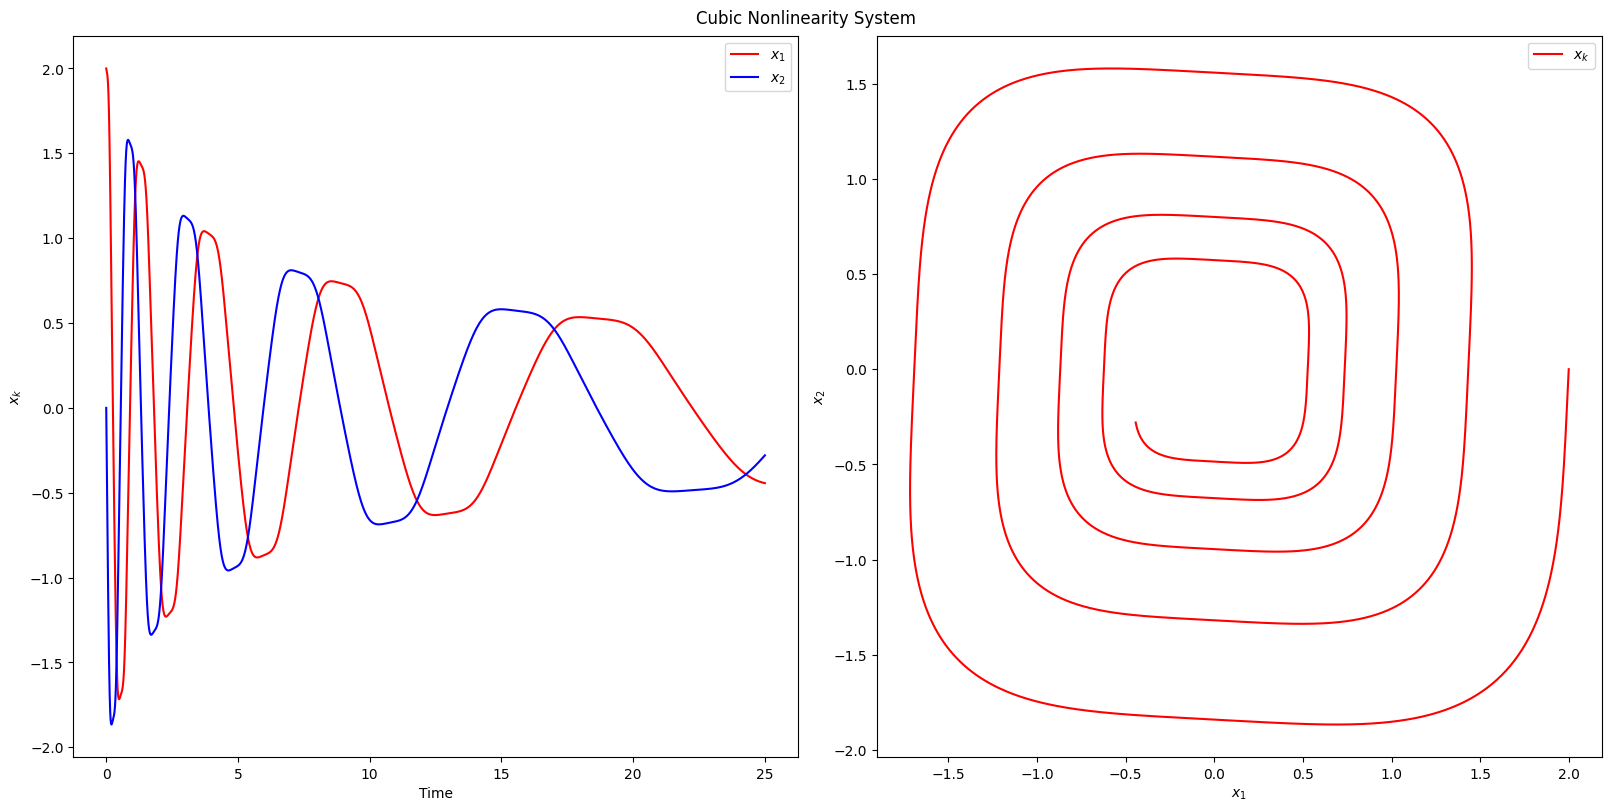

In [9]:
cub_fig, cub_axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(16,8))

cub_axes[0].plot(t_train, cub_evals[:,0], 'r-', label=r"$x_{1}$")
cub_axes[0].plot(t_train, cub_evals[:,1], 'b-', label=r"$x_{2}$")
cub_axes[0].set_xlabel("Time")
cub_axes[0].set_ylabel(r"$x_{k}$")
cub_axes[0].legend()

cub_axes[1].plot(cub_evals[:,0], cub_evals[:,1], 'r-', label=r"$x_{k}$")
cub_axes[1].set_xlabel(r"$x_{1}$")
cub_axes[1].set_ylabel(r"$x_{2}$")
cub_axes[1].legend()

cub_fig.suptitle("Cubic Nonlinearity System");

In [21]:
nDpnts = 5_000
nTst = nDpnts//4
# noise = 0.50
noise = 0.10

cub_t = cub_evals + rng.normal(loc=0.0, scale=cub_evals.std()*noise, size=cub_evals.shape, )

# normalize since the 3 outputs are in differing ranges
normalize=False
if normalize:
    cub_maxes = cub_t.max(0)
    cub_mins = cub_t.min(0)
else:
    cub_maxes = np.ones(shape=(2,))
    cub_mins = np.zeros(shape=(2,))

data = (cub_t - cub_mins) / (cub_maxes - cub_mins)

pnts = np.copy(sol_times[:, np.newaxis])

trn_ids = rng.choice(a=np.arange(cub_evals.shape[0]), size=nDpnts, replace=False, )
valNtst_ids = np.setdiff1d(ar1=np.arange(cub_evals.shape[0]), ar2=trn_ids,)
tst_ids = rng.choice(a=valNtst_ids, size=nTst, replace=False)
val_ids = np.setdiff1d(valNtst_ids, tst_ids)

t_trn = np.copy( pnts[trn_ids, :])
cub_trn = np.copy( data[trn_ids, :])
t_tst = np.copy( pnts[tst_ids, :])
cub_tst = np.copy( data[tst_ids, :])

cub_bnds = np.vstack((pnts.min(0), pnts.max(0)),).T

In [22]:
# cub_slvr = RFE(alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=5)
# cub_slvr = Cross_Val_RFE(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=ADO_iters)
# cub_slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
cub_slvr = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=6, thrshld_val=1e-8)
# cub_slvr = SSR(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), percent_redux=0.70, criteria="coefficient_value", ADO_iters=ADO_iters, normalize=True)

cub_libr = ODE_Poly_Deriv_Library(
        # poly_degree=2,
        poly_degree=4,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=0,
        include_bias=True,
        deriv_exclude_inds=None,
        device=dvc,
        data_type=torch.float32)


cub_d_dict = {"Train_Inputs":t_trn, "Train_Targets":cub_trn, "Test_Inputs":t_tst, "Test_Targets":cub_tst}

cub_col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=1, seed=None, 
                             bounds=cub_bnds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)   

In [23]:
prd_stuff = None
four_stuff = {'scale':2.0, 'inpt_dim':t_trn.shape[1], 'embd_dim':20}
rnd_wght_fct = True

# prd_stuff = None
# four_stuff = None
# rnd_wght_fct = False

numLyrsU = 5
nPrLU = 56

if prd_stuff or four_stuff or rnd_wght_fct:
    # net = Networks.MLP(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,out_dim=U_trn.shape[1],
    #                 #   activ_func=torch.nn.Tanh(),
    #                   activ_func=SinAct(),
    #                   prd_stuff=prd_stuff, four_stuff=four_stuff,
    #                   rnd_wght_fct=rnd_wght_fct).to(device=dvc)
    
    cub_net = Networks.PirateNet(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,
                             out_dim=cub_trn.shape[1],
                             activ_func=torch.nn.Tanh(),
                            #  activ_func=SinAct(), 
                             alpha=0.0,
                             prd_stuff=prd_stuff, 
                             four_stuff=four_stuff, 
                             rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    cub_net = torch.nn.Sequential(
            torch.nn.Linear(in_features=t_trn.shape[1], out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            # torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            # torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=cub_trn.shape[1], bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in cub_net.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)
    

In [24]:
cub_libr.fit(network=cub_net, inpts=torch.rand(size=(2,1), device=dvc, dtype=torch.float32))
lib_names = cub_libr.get_library_names(net_out_func_names=["x", "y",])
cub_bnds
# cub_init_lmbda = torch.zeros(size=(len(lib_names),2), device=dvc,)
cub_init_lmbda = torch.ones(size=(len(lib_names),2), device=dvc,)

cub_lrnr = EqLearner1D(net=cub_net,
        Lmbda=cub_init_lmbda.requires_grad_(True),
        lib_func=cub_libr,
        sprs_slvr=cub_slvr,
        data_dict=cub_d_dict,
        tmprl_ords=[1, 1],
        col_pnts_smplr=cub_col_smplr,
        N_col_pnts=50_000,
        ntwk_out_names=["x", "y"],
        device=dvc,
        data_type=torch.float32
)

In [25]:
run_time = 0
strt = perf_counter()
cub_lrnr.AdamsOptimTraining(mode="pre", alpha=0.001, gamma=1e-6, min_epochs=500, max_epochs=10_000, 
                        lrn_rt=0.001, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.28981e+00 | 4.38868e+01 | 3.0000e+01
            | Test Data  | 1.31692e+00 | 4.46023e+01 | 
Epoch   200 | Train Data | 3.25925e-02 | 1.33863e+01 | 2.6598e+01
            | Test Data  | 3.69698e-02 | 1.31442e+01 | 
Epoch   400 | Train Data | 1.38813e-02 | 1.03059e+01 | 2.2310e+01
            | Test Data  | 1.53697e-02 | 1.04134e+01 | 
Epoch   600 | Train Data | 1.03370e-02 | 6.99248e+00 | 1.7827e+01
            | Test Data  | 1.11139e-02 | 7.08804e+00 | 
Epoch   800 | Train Data | 8.90130e-03 | 4.61600e+00 | 1.3384e+01
            | Test Data  | 9.48315e-03 | 4.67321e+00 | 
Epoch  1000 | Train Data | 8.18756e-03 | 2.95204e+00 | 9.5902e+00
            | Test Data  | 8.69210e-03 | 2.96036e+00 | 
Epoch  1200 | Train Data | 7.86720e-03 | 1.84585e+00 | 7.7757e+00
            | Tes

In [26]:
cub_lrnr.Learned_EQ(output=True, sup_zeros=True, dec_rnd=8,);

The current Learned Equation(s) is(are) ... 
x_t = 2.72119000e-03*1 + 2.67339000e-03*x + -1.08591300e-02*y + 2.62740000e-04*(x)^2 + -2.54253900e-02*(x)(y) + -7.30000000e-07*(y)^2 + -1.13264860e-01*(x)^3 + 1.01732800e-02*(x)^2(y) + -5.18000000e-06*(x)(y)^2 + 2.03062415e+00*(y)^3 + -2.48596800e-02*(x)^4 + 3.31335000e-03*(x)^3(y) + 9.59198000e-02*(x)^2(y)^2 + 7.31236000e-03*(x)(y)^3 + -2.22679800e-02*(y)^4
y_t = 1.34842900e-02*1 + -3.28600970e-01*x + 1.01000000e-06*y + -5.06058800e-02*(x)^2 + -1.05464340e-01*(x)(y) + -1.35000000e-06*(y)^2 + -1.69899035e+00*(x)^3 + 2.89123900e-02*(x)^2(y) + -4.44422600e-02*(x)(y)^2 + -1.02668560e-01*(y)^3 + 1.17445900e-02*(x)^4 + 1.88923660e-01*(x)^3(y) + 7.45229400e-02*(x)^2(y)^2 + -8.79832300e-02*(x)(y)^3 + -1.57550500e-02*(y)^4


In [106]:
cub_lrnr.lmbda.data = torch.where(cub_lrnr.lmbda.data.abs()<5e-4, 0, cub_lrnr.lmbda.data)

In [16]:
cub_lrnr.lmbda.data

tensor([[ 7.2479e-02,  5.8625e-02],
        [ 8.1481e-03, -5.1933e-01],
        [ 1.1168e-01,  5.0161e-05],
        [ 5.6236e-03, -7.0395e-03],
        [ 9.6818e-02, -2.2501e-01],
        [ 1.2283e-02,  3.0276e-03],
        [-9.2164e-02, -8.4851e-01],
        [ 3.2741e-01,  2.4922e-01],
        [ 2.1208e-03, -6.5050e-01],
        [ 1.7775e+00, -1.9068e-01],
        [ 7.9299e-04,  9.3930e-02],
        [-1.4676e-02,  4.2038e-01],
        [ 1.7837e-02, -5.7527e-02],
        [-9.1309e-02, -1.5089e-01],
        [-7.9634e-02, -1.9945e-02]], device='cuda:0')

C:\Users\urzua\AppData\Local\Temp\ipykernel_14540\1759998982.py:7: RuntimeWarning: divide by zero encountered in divide
  mn_rel_errs = np.abs(cub_evals - cub_net_preds) / np.abs(cub_evals)


MSE = [3.59389165e-06 3.87319249e-06], Mean ABS = [0.00146169 0.00154788], Mean Rel Error = [0.02160586 0.01756053]


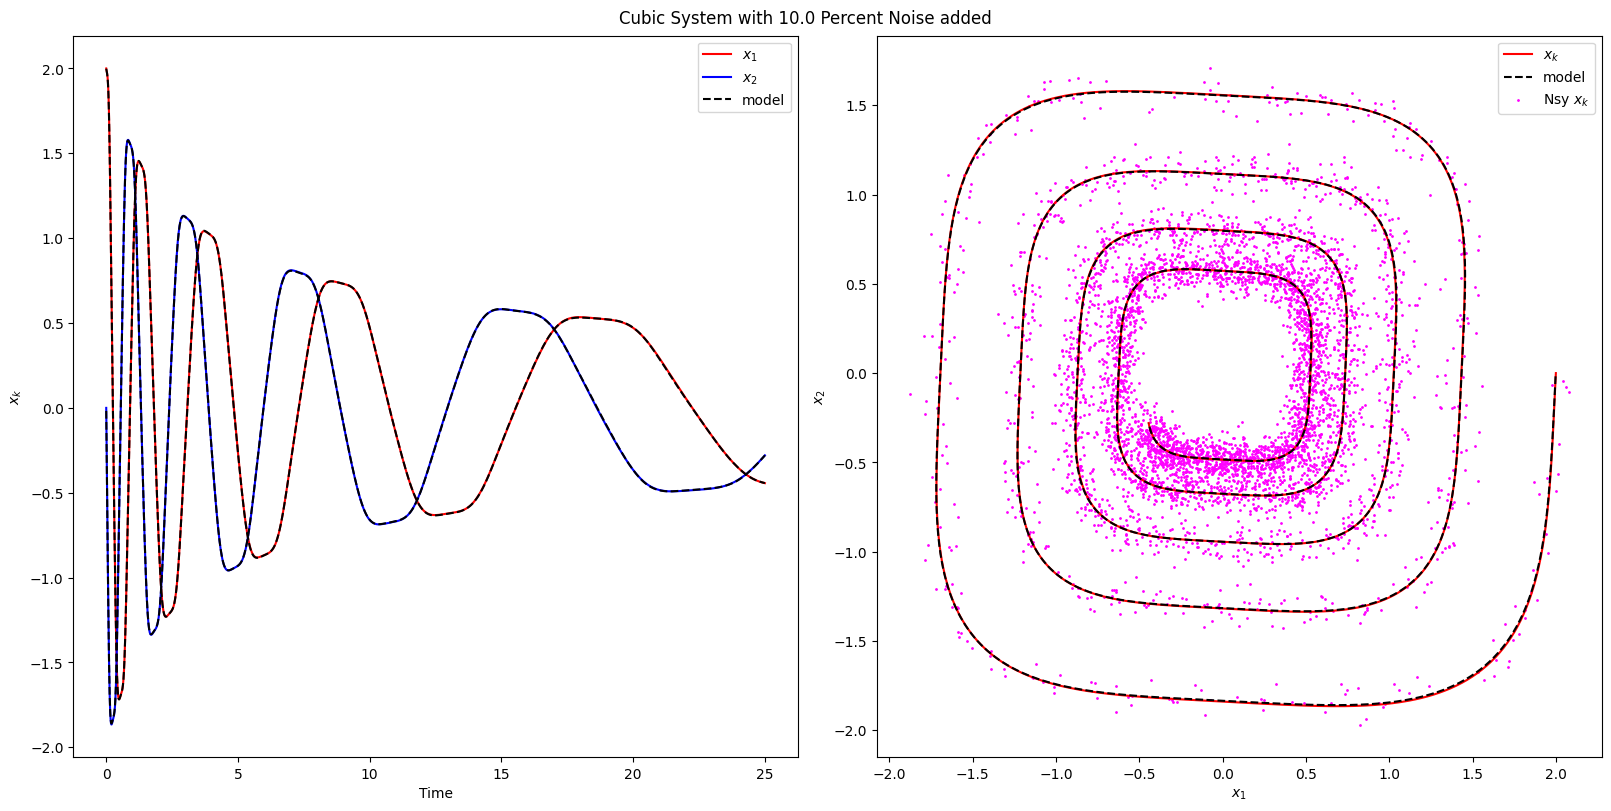

In [31]:
cub_net_preds = cub_lrnr.net(torch.from_numpy(sol_times[:,np.newaxis]).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

Cub_fig, cub_axes = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(16,8))

mse = np.mean((cub_evals - cub_net_preds)**2, axis=0)
mn_abs_err = np.mean(np.abs(cub_evals - cub_net_preds), axis=0)
mn_rel_errs = np.abs(cub_evals - cub_net_preds) / np.abs(cub_evals)
mn_rel_errs = np.where(np.logical_not(np.isfinite(mn_rel_errs)), np.abs(cub_evals - cub_net_preds), mn_rel_errs)
print(f"MSE = {mse}, Mean ABS = {mn_abs_err}, Mean Rel Error = {np.mean(mn_rel_errs, axis=0)}")

cub_axes[0].plot(t_train, cub_evals[:,0], 'r-', label=r"$x_{1}$")
cub_axes[0].plot(t_train, cub_evals[:,1], 'b-', label=r"$x_{2}$")
cub_axes[0].plot(t_train, cub_net_preds[:,0], 'k--', label="model")
# cub_axes[0].scatter(x=X_trn, y=U_trn[:,0], s=2.0, marker='.', color='red', label=r"noisy $x_{1}$")
# cub_axes[0].scatter(x=X_trn, y=U_trn[:,1], s=2.0, marker='.', color='blue', label=r"noisy $x_{2}$")
cub_axes[0].plot(t_train, cub_net_preds[:,1], 'k--', )
cub_axes[0].set_xlabel("Time")
cub_axes[0].set_ylabel(r"$x_{k}$")
cub_axes[0].legend()

cub_axes[1].plot(cub_evals[:,0], cub_evals[:,1], 'r-', label=r"$x_{k}$")
cub_axes[1].plot(cub_net_preds[:,0], cub_net_preds[:,1], 'k--', label="model")
cub_axes[1].scatter(x=cub_trn[:,0], y=cub_trn[:,1], s=4.0, marker=".",color="magenta", label=r"Nsy $x_{k}$")
# cub_axes[1].plot(U_trn[:,0], U_trn[:,1], 'm.', label=r"Nsy $x_k{k}$")

cub_axes[1].set_xlabel(r"$x_{1}$")
cub_axes[1].set_ylabel(r"$x_{2}$")
cub_axes[1].legend()

Cub_fig.suptitle(f"Cubic System with {noise*100} Percent Noise added");

In [133]:
cub_lrnr.AdamsOptimTraining(mode="ado", alpha=1.0, gamma=1e-3, min_epochs=None, max_epochs=cub_lrnr._AdamsPreTrnEpochs, 
                        lrn_rt=0.001, lp_ord=0.0001, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,);

Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.98452e-01 | 2.77894e-04 | 5.9994e+00
            | Test Data  | 3.08445e-01 | 6.41249e-01 | 
Epoch   200 | Train Data | 1.98593e-01 | 8.41614e-04 | 5.9993e+00
            | Test Data  | 1.99012e-01 | 8.33156e-04 | 


In [135]:
cub_lrnr.Learned_EQ(output=True, dec_rnd=8);

The current Learned Equation(s) is(are) ... 
x_t = -8.91199300e-02*(x)^3 + 1.66401000e-01*(x)^2(y) + 1.83352017e+00*(y)^3 
y_t = -1.87002861e+00*(x)^3 + -2.42499490e-01*(x)(y)^2 + -6.68912100e-02*(y)^3 


In [123]:
cub_lrnr.Learned_EQ(output=True, dec_rnd=8);

The current Learned Equation(s) is(are) ... 
x_t = -1.67231800e-01*(x)^3 + 1.85803860e-01*(x)^2(y) + 1.79123187e+00*(y)^3 
y_t = -1.84571242e+00*(x)^3 + -2.12369920e-01*(x)(y)^2 + -1.09000000e-06*(y)^3 


In [431]:
(1-0.001)*np.linspace(0,1.0,7)**0.5+ 0.001

array([0.001     , 0.40884004, 0.57777292, 0.70739967, 0.81668008,
       0.91295806, 1.        ])

In [126]:
col_pnts = torch.from_numpy(cub_col_smplr.sample(50_000)).to(device=dvc, dtype=cub_lrnr.data_type).requires_grad_(True)
col_prds = cub_net(col_pnts)
t_prtls = Nth_temporal_prtls(values=col_prds, pts=col_pnts, orders=cub_lrnr.tmprl_ords).detach()
lib_evals = cub_lrnr.lib_func.Calc(network=cub_lrnr.net, inpts=col_pnts).detach()

In [127]:
RFESparseRegression(A=lib_evals[:, torch.nonzero(cub_lrnr.lmbda.data[:,0]).ravel()], b=t_prtls[:,0:1], annealing_factor=2, best=True)

(tensor([[0.0000],
         [0.2727],
         [1.8313]], device='cuda:0'),
 tensor([[0.0000],
         [0.0000],
         [1.9137]], device='cuda:0'))

In [128]:
torch.nonzero(cub_lrnr.lmbda.data[:,0]).ravel()

tensor([6, 7, 9], device='cuda:0')

In [129]:
torch.nonzero(cub_lrnr.lmbda.data[:,1]).ravel()

tensor([6, 8, 9], device='cuda:0')

In [130]:
print(lib_names)

['1', 'x', 'y', '(x)^2', '(x)(y)', '(y)^2', '(x)^3', '(x)^2(y)', '(x)(y)^2', '(y)^3', '(x)^4', '(x)^3(y)', '(x)^2(y)^2', '(x)(y)^3', '(y)^4']


In [136]:
gready_coefs = Specified_Optim_Regres(A=lib_evals, b=t_prtls[:,:1], activ_ids=[ 6,7,9], alpha=0.0 )

In [137]:
gready_coefs

tensor([[ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [-0.1087, -0.1256,  0.0000,  0.0000],
        [ 0.2355,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 1.8380,  1.9084,  1.9137,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]], device='cuda:0')

In [138]:
torch.linalg.lstsq(lib_evals[:,[6,9]], t_prtls)[0]

tensor([[-0.1256, -1.9565],
        [ 1.9084, -0.0810]], device='cuda:0')

In [28]:
cub_lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=True, Save_File_Name=None, Early_RFE_Term=True, p=0.5)
# lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)
# lrnr.ADO_Training(iters=0, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
x_t = -3.13967300e-02*y + 2.83347000e-02*(x)^2 + -1.78649800e-02*(x)(y) + -1.14506940e-01*(x)^3 + 2.04604363e+00*(y)^3 + -3.72227000e-02*(x)^4 + 9.71100100e-02*(x)^2(y)^2 + -2.16896000e-02*(y)^4
y_t = 1.78726000e-02*1 + -1.16716820e-01*(x)^2 + -1.96842992e+00*(x)^3 + -8.97743000e-02*(y)^3 + 4.29292600e-02*(x)^4 + 6.99399200e-02*(x)^3(y) + 4.95690100e-02*(x)^2(y)^2 + -6.80514000e-02*(x)(y)^3 
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 7.34987e-03 | 1.16326e-01 | 4.8175e+00
            | Test Data  | 8.38434e-03 | 9.73320e-02 | 
Epoch   100 | Train Data | 7.80550e-03 | 1.02129e-03 | 4.7316e+00
            | Test Data  | 7.93330e-03 | 1.02031e-03 | 
Epoch   200 | Train Data | 7.79393e-03 | 3.16378e-04 | 4.6574e+00
            | Test Data  | 7.90046e-03

In [36]:
lrnd_eq = cub_lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
x_t = -1.02537080e-01*(x)^3 + 2.01146483e+00*(y)^3 
y_t = -1.99141324e+00*(x)^3 + -9.69797500e-02*(y)^3 


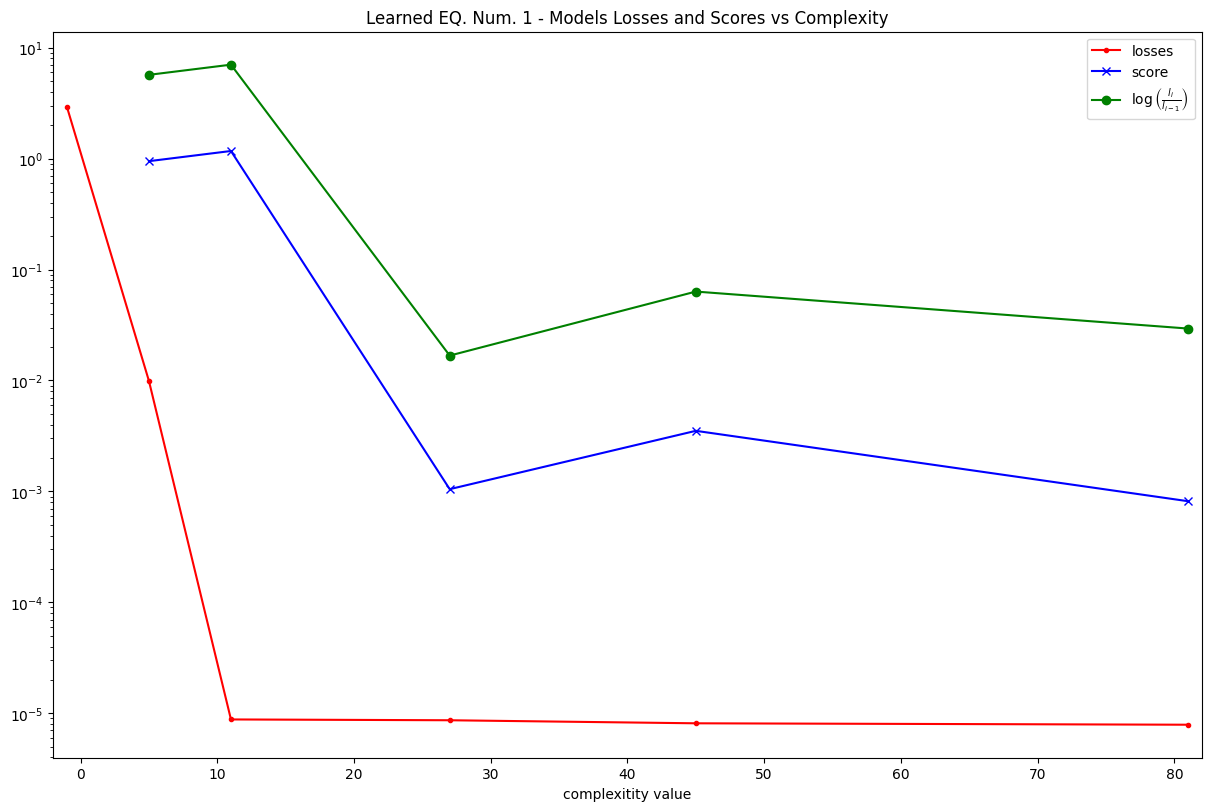

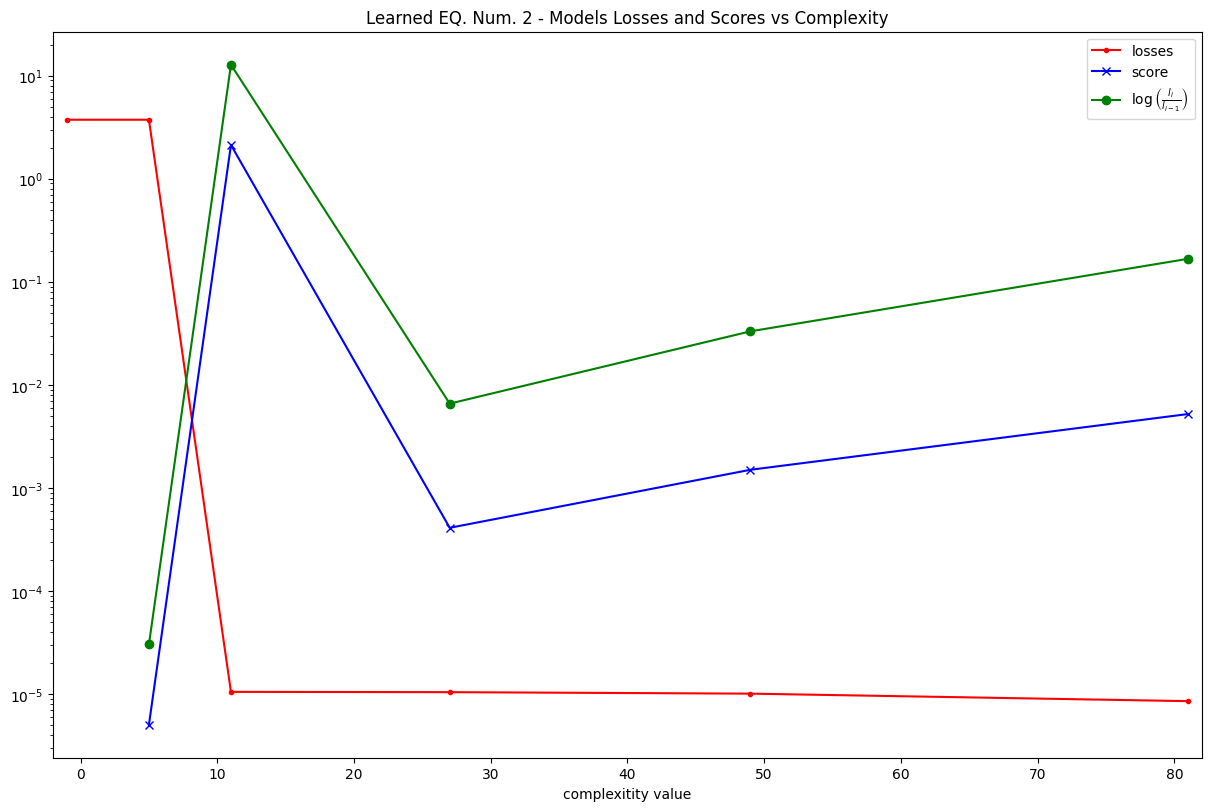

In [30]:
cub_lrnr.Loss_Score_Complexity_Plot(dataset_name="Testing", save_dir_name="CubicHarmonic", save_figs=False)

In [34]:
cub_lrnr.Save_Model(data_set="CubicDampedOscillator", fname="CorrectSolutionNoPostTrain")

Saved_Models Directory already exists so did not create it


In [ ]:
lrnd_lmbda = cub_lrnr.lmbda.data.cpu().numpy()
tru_lmbda = np.zeros_like(lrnd_lmbda)
tru_lmbda[6,0] = -0.1
tru_lmbda[9,0] = 2.0
tru_lmbda[6,1] = -2.0
tru_lmbda[9,1] = -0.1

lrnd_eqs = []
for k in range(2):
    lhs = "x_t = " if k==0 else  "y_t = "
    nz_indices = lrnd_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(lrnd_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    lrnd_eqs.append(lhs[:-3])
    
tru_eqs = []
for k in range(2):
    lhs = "x_t = " if k==0 else  "y_t = "
    nz_indices = tru_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(tru_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    tru_eqs.append(lhs[:-3])

print(lrnd_eqs)
print(tru_eqs)

In [ ]:
fig_title = "Learned EQs: " + lrnd_eqs[0] + "       True EQs: " + tru_eqs[0] + "\n    "
fig_title +="                    " + lrnd_eqs[1] + "                          " + tru_eqs[1] 
print(fig_title)

Learned EQs: x_t = -0.103(x)^3 + 2.0109(y)^3       True EQs: x_t = -0.100(x)^3 + 2.0(y)^3
                        y_t = -1.991(x)^3 + -0.097(y)^3                          y_t = -2.0(x)^3 + -0.100(y)^3


C:\Users\urzua\AppData\Local\Temp\ipykernel_14540\589100269.py:7: RuntimeWarning: divide by zero encountered in divide
  mn_rel_errs = np.abs(cub_evals - cub_net_preds) / np.abs(cub_evals)


MSE = [3.59389165e-06 3.87319249e-06], Mean ABS = [0.00146169 0.00154788], Mean Rel Error = [0.02160586 0.01756053]


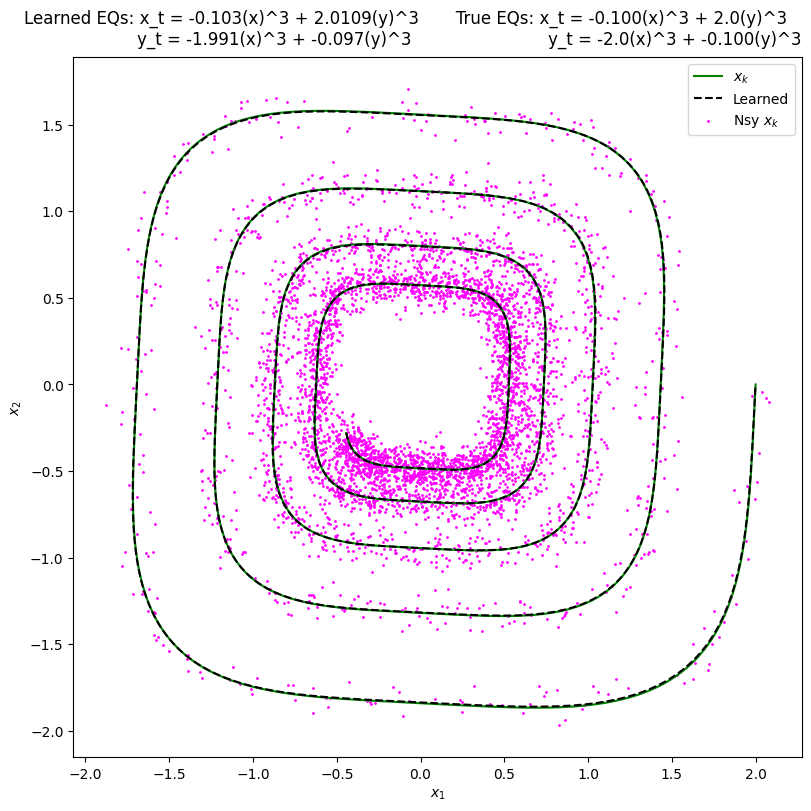

In [95]:
cub_net_preds = cub_lrnr.net(torch.from_numpy(sol_times[:,np.newaxis]).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

Cub_fig, cub_axes = plt.subplots(nrows=1, ncols=1, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(8,8))

mse = np.mean((cub_evals - cub_net_preds)**2, axis=0)
mn_abs_err = np.mean(np.abs(cub_evals - cub_net_preds), axis=0)
mn_rel_errs = np.abs(cub_evals - cub_net_preds) / np.abs(cub_evals)
mn_rel_errs = np.where(np.logical_not(np.isfinite(mn_rel_errs)), np.abs(cub_evals - cub_net_preds), mn_rel_errs)
print(f"MSE = {mse}, Mean ABS = {mn_abs_err}, Mean Rel Error = {np.mean(mn_rel_errs, axis=0)}")

cub_axes.plot(cub_evals[:,0], cub_evals[:,1], 'g-', label=r"$x_{k}$")
cub_axes.plot(cub_net_preds[:,0], cub_net_preds[:,1], 'k--', label="Learned")
cub_axes.scatter(x=cub_trn[:,0], y=cub_trn[:,1], s=4.0, marker=".",color="magenta", label=r"Nsy $x_{k}$")
# cub_axes.plot(U_trn[:,0], U_trn[:,1], 'm.', label=r"Nsy $x_k{k}$")

cub_axes.set_xlabel(r"$x_{1}$")
cub_axes.set_ylabel(r"$x_{2}$")
cub_axes.legend()

# Cub_fig.suptitle(f"Cubic System with {noise*100} Percent Noise added");
Cub_fig.suptitle(fig_title);

Cub_fig.savefig(fname="CubiOscillatorFig.png")

['x_t = -0.103(x)^3 + 2.0109(y)^3', 'y_t = -1.991(x)^3 + -0.097(y)^3']
['x_t = -0.100(x)^3 + 2.0(y)^3', 'y_t = -2.0(x)^3 + -0.100(y)^3']


In [65]:
str(np.round(lrnd_lmbda[ind,k],3).item())[:6]

'-0.097'

In [ ]:
lrn_lmbda

array([[ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [-0.1, -2. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 2. , -0.1],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ],
       [ 0. ,  0. ]], dtype=float32)

In [96]:
cub_lrnr._ADO_alphas

array([0.40884006, 0.57777292, 0.70739967])

In [97]:
run_time = 0
strt = perf_counter()
cub_lrnr.AdamsOptimTraining(mode="post", alpha=1.0, gamma=0.0, min_epochs=200, max_epochs=10_000, 
                        lrn_rt=0.001, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Post-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 7.80320e-03 | 2.02490e-05 | 4.2024e+00
            | Test Data  | 9.16952e-03 | 6.05589e-02 | 
Epoch   200 | Train Data | 7.81017e-03 | 1.76579e-05 | 4.2002e+00
            | Test Data  | 7.86693e-03 | 1.56462e-05 | 
Finished Adams Post Training


In [98]:
cub_lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
x_t = -1.04877170e-01*(x)^3 + 2.01257277e+00*(y)^3 
y_t = -1.99128544e+00*(x)^3 + -9.17143200e-02*(y)^3 


### 3D Linear

In [99]:
# Generate measurement data
linear_3D
dt = 0.001
t_train = np.arange(0, 50, dt)
t_train_span = (t_train[0], t_train[-1])
u0_train = [2, 0, 1]

lin_3D_ouput = solve_ivp(
    linear_3D, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
)

lin_3D_evals = lin_3D_ouput.y.T
sol_times = lin_3D_ouput.t.T
lin_3D_t = np.empty_like(lin_3D_evals)
lin_3D_t[1:-1] = (lin_3D_evals[2:] - lin_3D_evals[:-2])/(2*dt)
lin_3D_t[0] = (-3*lin_3D_evals[0] + 4*lin_3D_evals[1] - lin_3D_evals[2])/(2*dt)
lin_3D_t[-1] = (1*lin_3D_evals[-3] - 4*lin_3D_evals[-2] + 3*lin_3D_evals[-1])/(2*dt)

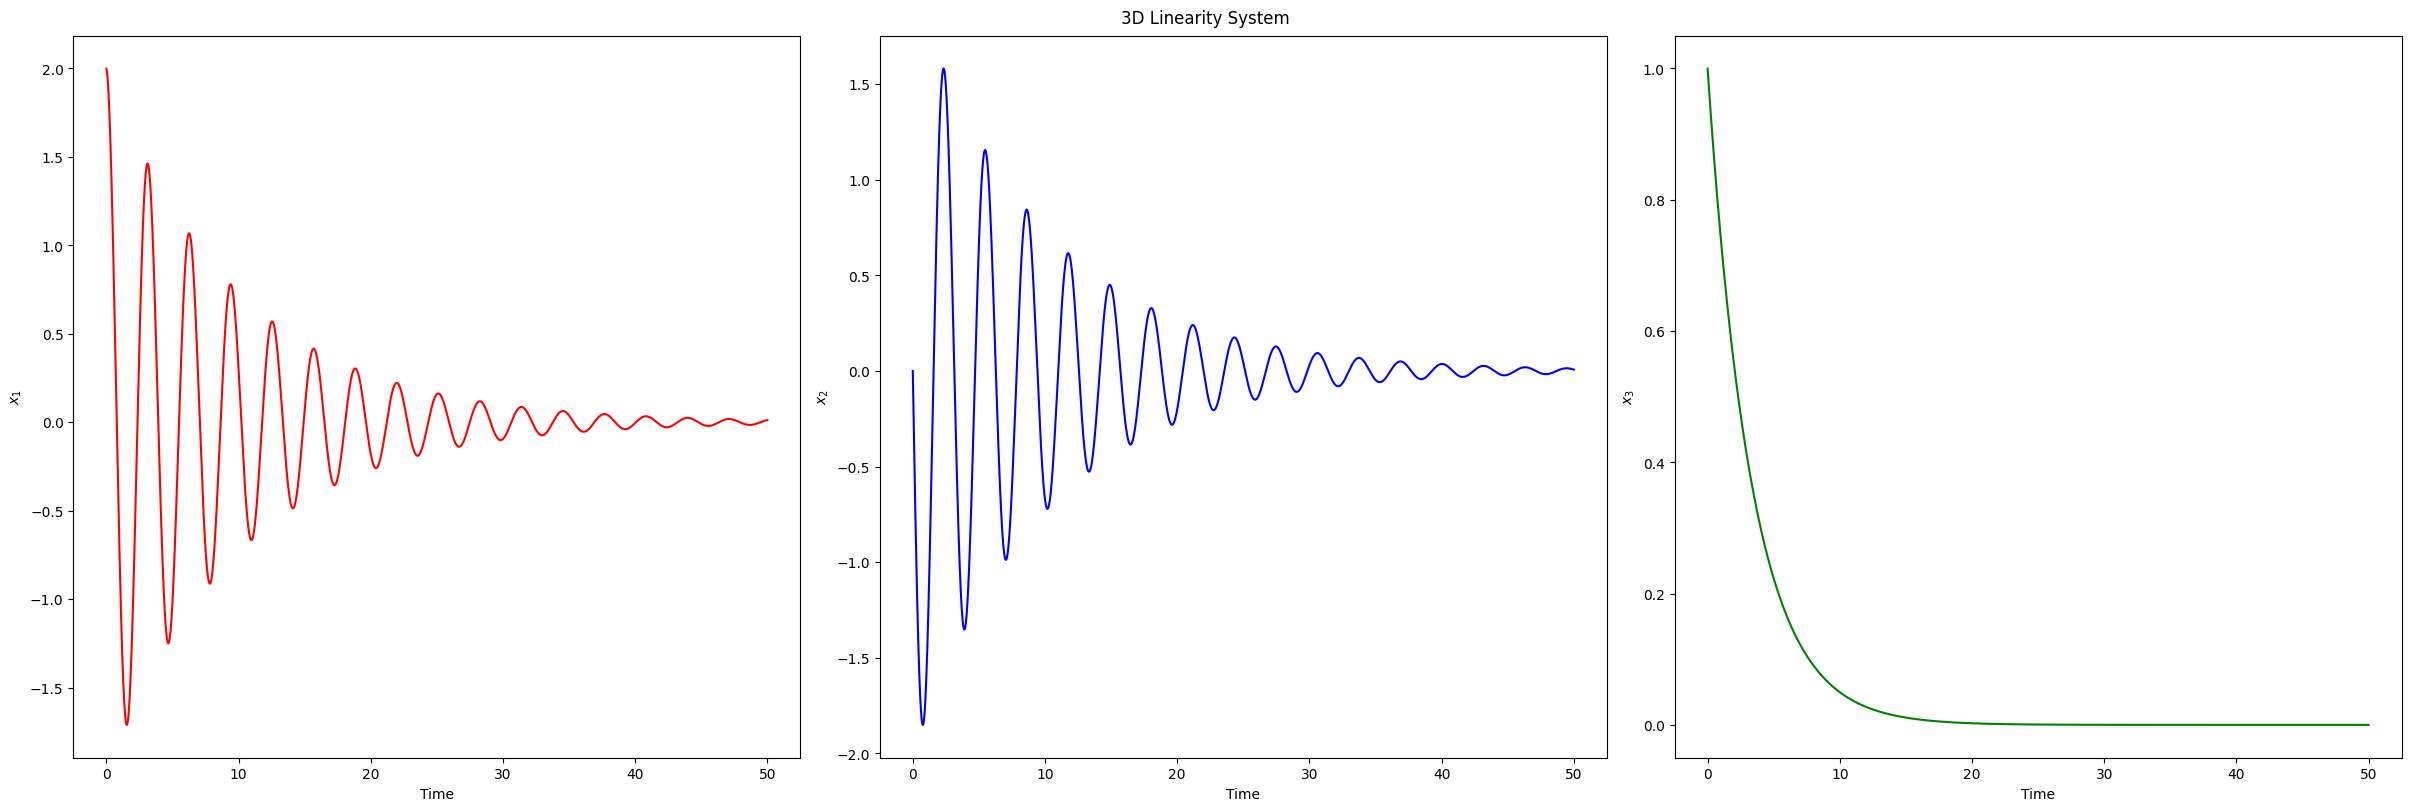

In [100]:
lin3D_fig, lin3D_axes = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(24,8))

lin3D_axes[0].plot(t_train, lin_3D_evals[:,0], 'r-', )
lin3D_axes[0].set_xlabel("Time")
lin3D_axes[0].set_ylabel(r"$x_{1}$")
# lin3D_axes[0].legend()


lin3D_axes[1].plot(t_train, lin_3D_evals[:,1], 'b-', )
lin3D_axes[1].set_xlabel("Time")
lin3D_axes[1].set_ylabel(r"$x_{2}$")
# lin3D_axes[1].legend()

lin3D_axes[2].plot(t_train, lin_3D_evals[:,2], 'g-', )
lin3D_axes[2].set_xlabel("Time")
lin3D_axes[2].set_ylabel(r"$x_{3}$")
# lin3D_axes[2].legend()

lin3D_fig.suptitle("3D Linearity System");

In [ ]:
nDpnts = 5_000
nTst = nDpnts//4
# noise = 0.50
noise = 0.05


lin3D_lrn_data = lin_3D_evals + rng.normal(loc=0.0, scale=lin_3D_evals.std()*noise, size=lin_3D_evals.shape, )

# normalize since the 3 outputs are in differing ranges
normalize=False
if normalize:
    lin3D_maxes = lin3D_lrn_data.max(0)
    lin3D_mins = lin3D_lrn_data.min(0)
else:
    lin3D_maxes = np.ones(shape=(lin3D_lrn_data.shape[1],))
    lin3D_mins = np.zeros(shape=(lin3D_lrn_data.shape[1],))

data = (lin3D_lrn_data - lin3D_mins) / (lin3D_maxes - lin3D_mins)

pnts = np.copy(sol_times[:, np.newaxis])

trn_ids = rng.choice(a=np.arange(lin_3D_evals.shape[0]), size=nDpnts, replace=False, )
valNtst_ids = np.setdiff1d(ar1=np.arange(lin_3D_evals.shape[0]), ar2=trn_ids,)
tst_ids = rng.choice(a=valNtst_ids, size=nTst, replace=False)
val_ids = np.setdiff1d(valNtst_ids, tst_ids)

lin3D_t_trn = np.copy( pnts[trn_ids, :])
lin3D_trn = np.copy( data[trn_ids, :])
lin3D_t_tst = np.copy( pnts[tst_ids, :])
lin3D_tst = np.copy( data[tst_ids, :])

lin3D_bnds = np.vstack((pnts.min(0), pnts.max(0)),).T

In [102]:
# lin3D_slvr = RFE(alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=5)
# lin3D_slvr = Cross_Val_RFE(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=ADO_iters)
# lin3D_slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
lin3D_slvr = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=6, thrshld_val=1e-8)
# lin3D_slvr = SSR(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), percent_redux=0.70, criteria="coefficient_value", ADO_iters=ADO_iters, normalize=True)

lin3D_libr = ODE_Poly_Deriv_Library(
        poly_degree=2,
        # poly_degree=4,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=0,
        include_bias=True,
        deriv_exclude_inds=None,
        device=dvc,
        data_type=torch.float32)


lin3D_d_dict = {"Train_Inputs":lin3D_t_trn, "Train_Targets":lin3D_trn, "Test_Inputs":lin3D_t_tst, "Test_Targets":lin3D_tst}

lin3D_col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=1, seed=None, 
                             bounds=lin3D_bnds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)   

prd_stuff = None
four_stuff = {'scale':2.0, 'inpt_dim':t_trn.shape[1], 'embd_dim':20}
rnd_wght_fct = True

# prd_stuff = None
# four_stuff = None
# rnd_wght_fct = False

numLyrsU = 5
nPrLU = 56

if prd_stuff or four_stuff or rnd_wght_fct:
    # net = Networks.MLP(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,out_dim=U_trn.shape[1],
    #                 #   activ_func=torch.nn.Tanh(),
    #                   activ_func=SinAct(),
    #                   prd_stuff=prd_stuff, four_stuff=four_stuff,
    #                   rnd_wght_fct=rnd_wght_fct).to(device=dvc)
    
    lin3D_net = Networks.PirateNet(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,
                             out_dim=lin3D_trn.shape[1],
                             activ_func=torch.nn.Tanh(),
                            #  activ_func=SinAct(), 
                             alpha=0.0,
                             prd_stuff=prd_stuff, 
                             four_stuff=four_stuff, 
                             rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    lin3D_net = torch.nn.Sequential(
            torch.nn.Linear(in_features=t_trn.shape[1], out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            # torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            # torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # Rational(),
            torch.nn.Tanh(),
            # SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=cub_trn.shape[1], bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in lin3D_net.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)
    

In [103]:
lib_names

['1',
 'x',
 'y',
 '(x)^2',
 '(x)(y)',
 '(y)^2',
 '(x)^3',
 '(x)^2(y)',
 '(x)(y)^2',
 '(y)^3',
 '(x)^4',
 '(x)^3(y)',
 '(x)^2(y)^2',
 '(x)(y)^3',
 '(y)^4']

In [104]:
lin3D_libr.fit(network=lin3D_net, inpts=torch.rand(size=(2,1), device=dvc, dtype=torch.float32))
lib_names = lin3D_libr.get_library_names(net_out_func_names=["x", "y","z"])
lin3D_bnds
# cub_init_lmbda = torch.zeros(size=(len(lib_names),3), device=dvc,)
lin3D_init_lmbda = torch.ones(size=(len(lib_names),3), device=dvc,)

lin3D_lrnr = EqLearner1D(net=lin3D_net,
        Lmbda=lin3D_init_lmbda.requires_grad_(True),
        lib_func=lin3D_libr,
        sprs_slvr=lin3D_slvr,
        data_dict=lin3D_d_dict,
        tmprl_ords=[1, 1, 1],
        col_pnts_smplr=lin3D_col_smplr,
        N_col_pnts=50_000,
        ntwk_out_names=["x", "y","z"],
        device=dvc,
        data_type=torch.float32
)

In [105]:
run_time = 0
strt = perf_counter()
lin3D_lrnr.AdamsOptimTraining(mode="pre", alpha=0.001, gamma=1e-6, min_epochs=500, max_epochs=10_000, 
                        lrn_rt=0.001, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.32366e+00 | 1.40998e+01 | 3.0000e+01
            | Test Data  | 1.21931e+00 | 1.39965e+01 | 
Epoch   200 | Train Data | 2.31942e-02 | 6.25381e+00 | 2.7166e+01
            | Test Data  | 2.00953e-02 | 5.87766e+00 | 
Epoch   400 | Train Data | 1.81979e-03 | 4.77059e+00 | 2.3004e+01
            | Test Data  | 1.75357e-03 | 4.42948e+00 | 
Epoch   600 | Train Data | 1.27912e-03 | 2.94119e+00 | 1.8452e+01
            | Test Data  | 1.30665e-03 | 2.71377e+00 | 
Epoch   800 | Train Data | 1.12530e-03 | 1.79127e+00 | 1.4399e+01
            | Test Data  | 1.17451e-03 | 1.64770e+00 | 
Epoch  1000 | Train Data | 1.07069e-03 | 1.09953e+00 | 1.1638e+01
            | Test Data  | 1.13069e-03 | 1.01090e+00 | 
Epoch  1200 | Train Data | 1.04838e-03 | 6.94161e-01 | 9.5803e+00
            | Tes

C:\Users\urzua\AppData\Local\Temp\ipykernel_14540\933540427.py:7: RuntimeWarning: divide by zero encountered in divide
  mn_rel_errs = np.abs(lin_3D_evals - lin3D_net_preds) / np.abs(lin_3D_evals)


MSE = [1.10355648e-06 1.12886539e-06 1.16632104e-06], Mean ABS = [0.00086278 0.00084967 0.00084518], Mean Rel Error = [7.32773893e-02 6.69055428e-02 1.58252780e+02]


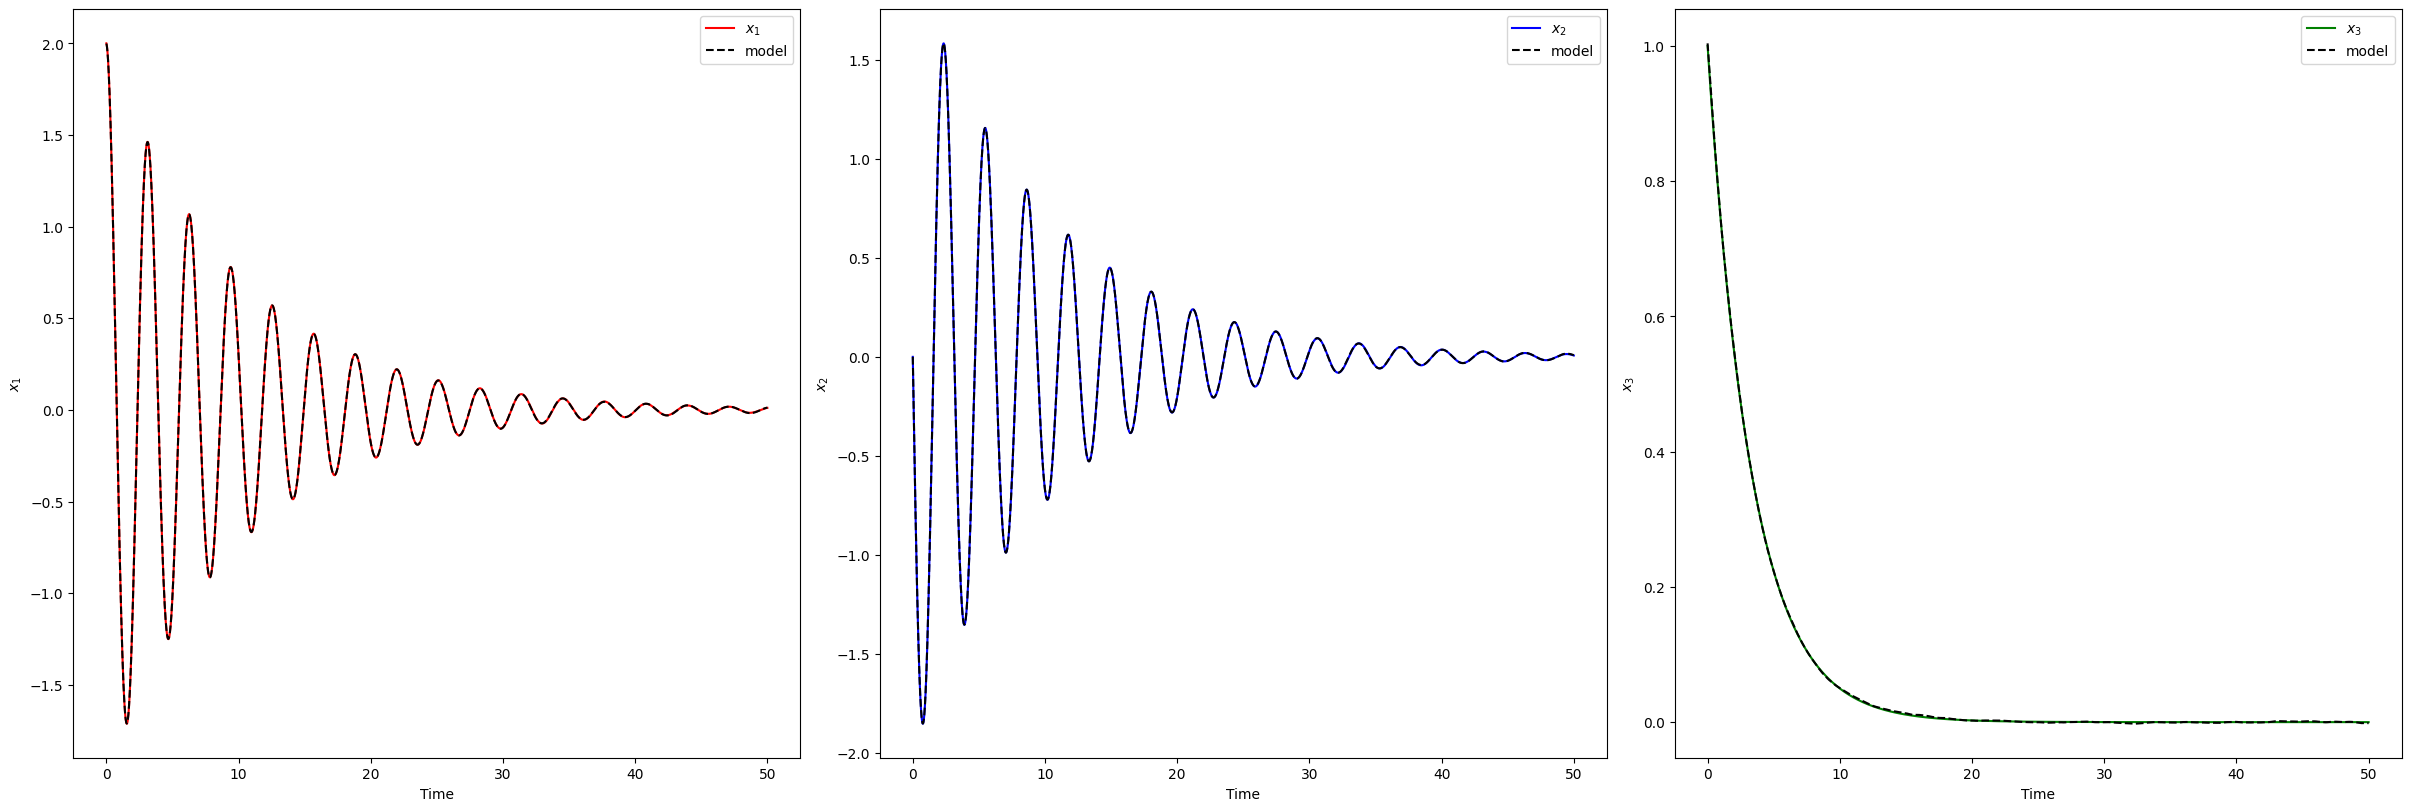

In [112]:
lin3D_net_preds = lin3D_lrnr.net(torch.from_numpy(sol_times[:,np.newaxis]).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()

lin3D_fig, lin3D_axes = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, layout='constrained', squeeze=True, figsize=(24,8))

mse = np.mean((lin_3D_evals - lin3D_net_preds)**2, axis=0)
mn_abs_err = np.mean(np.abs(lin_3D_evals - lin3D_net_preds), axis=0)
mn_rel_errs = np.abs(lin_3D_evals - lin3D_net_preds) / np.abs(lin_3D_evals)
mn_rel_errs = np.where(np.logical_not(np.isfinite(mn_rel_errs)), np.abs(lin_3D_evals - lin3D_net_preds), mn_rel_errs)
print(f"MSE = {mse}, Mean ABS = {mn_abs_err}, Mean Rel Error = {np.mean(mn_rel_errs, axis=0)}")

lin3D_axes[0].plot(t_train, lin_3D_evals[:,0], 'r-', label=r"$x_{1}$")
# lin3D_axes[0].scatter(x=X_trn, y=U_trn[:,0], s=2.0, marker='.', color='red', label=r"noisy $x_{1}$")
lin3D_axes[0].plot(t_train, lin3D_net_preds[:,0], 'k--', label="model")
# lin3D_axes[0].plot(t_train, lin3D_net_preds[:,1], 'k--', )
# lin3D_axes[0].plot(t_train, lin_3D_evals[:,1], 'b-', label=r"$x_{2}$")
# lin3D_axes[0].scatter(x=X_trn, y=U_trn[:,1], s=2.0, marker='.', color='blue', label=r"noisy $x_{2}$")
lin3D_axes[0].set_xlabel("Time")
lin3D_axes[0].set_ylabel(r"$x_{1}$")
lin3D_axes[0].legend()

lin3D_axes[1].plot(t_train, lin_3D_evals[:,1], 'b-', label=r"$x_{2}$")
lin3D_axes[1].plot(t_train, lin3D_net_preds[:,1], 'k--', label="model")
# lin3D_axes[1].scatter(x=X_trn, y=U_trn[:,1], s=2.0, marker='.', color='blue', label=r"noisy $x_{2}$")
lin3D_axes[1].set_xlabel("Time")
lin3D_axes[1].set_ylabel(r"$x_{2}$")
lin3D_axes[1].legend()

lin3D_axes[2].plot(t_train, lin_3D_evals[:,2], 'g-', label=r"$x_{3}$")
lin3D_axes[2].plot(t_train, lin3D_net_preds[:,2], 'k--', label="model")
# lin3D_axes[2].scatter(x=X_trn, y=U_trn[:,2], s=2.0, marker='.', color='green', label=r"noisy $x_{3}$")
lin3D_axes[2].set_xlabel("Time")
lin3D_axes[2].set_ylabel(r"$x_{3}$")
lin3D_axes[2].legend()


Cub_fig.suptitle(f"Cubic System with {noise*100} Percent Noise added");

In [108]:
lin3D_lrnr.Learned_EQ(output=True, );

The current Learned Equation(s) is(are) ... 
x_t = 4.62000000e-06*1 + -9.47223400e-02*x + 1.97901118e+00*y + -3.61300000e-05*z + -7.85716000e-03*(x)^2 + 6.55700000e-05*(x)(y) + -2.11400000e-05*(x)(z) + -1.22015700e-02*(y)^2 + 5.49186300e-02*(y)(z) + 1.21817180e-01*(z)^2
y_t = 1.75000000e-06*1 + -1.80685461e+00*x + -9.50037500e-02*y + -1.83900000e-05*z + -9.19694000e-03*(x)^2 + -3.55406500e-02*(x)(y) + -4.11369030e-01*(x)(z) + -1.98056100e-02*(y)^2 + -9.55400000e-05*(y)(z) + 1.85842950e-01*(z)^2
z_t = 1.65054000e-03*1 + -3.49700000e-05*x + 1.68400000e-05*y + -2.44100000e-05*z + -5.47961300e-02*(x)^2 + 2.42400000e-04*(x)(y) + -7.28000000e-06*(x)(z) + -5.89632000e-02*(y)^2 + 6.20814000e-03*(y)(z) + -7.40000000e-06*(z)^2


In [109]:
lin3D_lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", LBFGS=False, lbfgs_epochs=10, Early_Term=True, Save_File_Name=None, Early_RFE_Term=True, p=0.5)
# lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)
# lrnr.ADO_Training(iters=0, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
x_t = -9.92064800e-02*x + 2.00217009e+00*y + -2.61744920e-01*z + 4.03522100e-02*(x)^2 + 3.10889800e-02*(y)^2 + 1.49149430e-01*(z)^2
y_t = 2.84666000e-03*1 + -2.00052238e+00*x + -9.66872400e-02*y + -3.73409000e-03*(x)^2 + -5.64299000e-03*(x)(y) + -9.55384000e-03*(y)(z) 
z_t = -4.17465000e-03*y + -4.10758110e-01*z + 1.23322600e-02*(x)^2 + 9.49306000e-03*(y)^2 + 2.22657600e-02*(y)(z) + 1.12413250e-01*(z)^2
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 9.98538e-04 | 1.36228e-02 | 5.2741e+00
            | Test Data  | 1.44568e-03 | 1.42280e-02 | 
Epoch   100 | Train Data | 1.07065e-03 | 2.90758e-04 | 5.2715e+00
            | Test Data  | 1.04624e-03 | 2.87943e-04 | 
Epoch   200 | Train Data | 1.07232e-03 | 8.70047e-05 | 5.2195e+00
            | Test Data  |

In [110]:
lin3D_lrnr.Learned_EQ(output=True, );

The current Learned Equation(s) is(are) ... 
x_t = -9.99908000e-02*x + 1.99961126e+00*y 
y_t = -2.00070381e+00*x + -1.00096950e-01*y 
z_t = -3.00835190e-01*z 


In [111]:
lin3D_lrnr.Save_Model(data_set="Lin3DOscillator", fname="GoodResWith5Pnoise")

Saved_Models Directory already exists so did not create it


In [ ]:
# lin_3D_evals
lin_3D_prds = lin3D_lrnr.net(torch.from_numpy(sol_times[:,np.newaxis]).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()
# lin3D_lrn_data

array([[ 1.98102394e+00, -1.41173354e-02,  9.73066148e-01],
       [ 1.99129296e+00, -1.12554845e-02,  1.00100324e+00],
       [ 1.98275166e+00, -2.52192406e-02,  1.01154087e+00],
       ...,
       [ 4.16413042e-02,  1.70755939e-03, -4.10805619e-03],
       [ 7.36812327e-03, -2.73376154e-02, -2.03088932e-02],
       [ 3.81859944e-02,  1.24908265e-02, -1.35991932e-02]],
      shape=(50000, 3))

In [133]:
lrnd_lmbda = lin3D_lrnr.lmbda.data.cpu().numpy()
tru_lmbda = np.zeros_like(lrnd_lmbda)
tru_lmbda[1,0] = -0.1
tru_lmbda[2,0] = 2.0
tru_lmbda[1,1] = 2.0
tru_lmbda[2,1] = -0.1
tru_lmbda[3,2] = -0.3

lrnd_eqs = []
for k in range(3):
    if k==0:
        lhs = "x_t = "
    elif k==1:
        lhs = "y_t = "
    else:
        lhs = "z_t = "
    nz_indices = lrnd_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(lrnd_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    lrnd_eqs.append(lhs[:-3])
    
tru_eqs = []
for k in range(3):
    if k==0:
        lhs = "x_t = "
    elif k==1:
        lhs = "y_t = "
    else:
        lhs = "z_t = "
    nz_indices = tru_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(tru_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    tru_eqs.append(lhs[:-3])

# print(lrnd_eqs)
# print(tru_eqs)

In [ ]:

fig_title = "Learned EQs: " + lrnd_eqs[0] + "       True EQs: " + tru_eqs[0] + "\n    "
fig_title +="                    " + lrnd_eqs[1] + "                 " + tru_eqs[1] + "\n    "
fig_title +="        " + lrnd_eqs[2] + "                                " + tru_eqs[2] 
print(fig_title)

Learned EQs: x_t = -0.100x + 2.0y       True EQs: x_t = -0.100x + 2.0y
                        y_t = -2.000x + -0.100y                 y_t = 2.0x + -0.100y
            z_t = -0.300z                                z_t = -0.300z


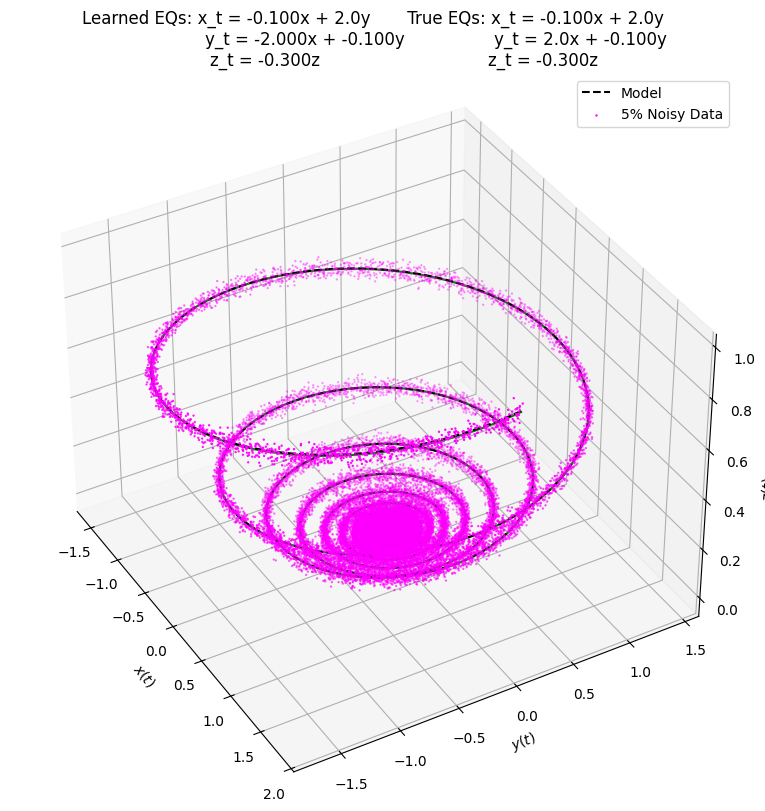

In [ ]:

anim_fig = plt.figure(figsize=(8,8), layout="constrained")
ax = anim_fig.add_subplot(projection='3d', )

# k = int(i*spdx)
x_min, y_min, z_min = lin3D_lrn_data.min(0)
x_max, y_max, z_max = lin3D_lrn_data.max(0)
ax.clear()
ax.view_init(elev=37, azim=-30, roll=0)
ax.plot(lin_3D_evals[:,0], lin_3D_evals[:,1], lin_3D_evals[:,2], 'g-',)
ax.plot(lin_3D_prds[:,0], lin_3D_prds[:,1], lin_3D_prds[:,2], 'k--', label="Model")
ax.scatter3D(xs=lin3D_lrn_data[:,0], ys=lin3D_lrn_data[:,1], zs=lin3D_lrn_data[:,2], s=2.0, marker='.', color="magenta", label='5% Noisy Data')
ax.set_xlabel(r"$x\left( t\right)$")
ax.set_xlim(left=x_min, right=x_max)
ax.set_ylabel(r"$y\left( t\right)$")
ax.set_ylim(bottom=y_min, top=y_max)
ax.set_zlabel(r"$z\left( t\right)$")
ax.set_zlim(bottom=z_min, top=z_max)
ax.legend()
# ax.set_title(r'$x\left( t\right), y\left( t \right)$ and $z\left(t\right)$ at time $t$')
ax.set_title(fig_title);
# ax.legend()

anim_fig.savefig(fname="Lin3DOscillatorFig.png")

### Lorenz Chaotic System

In [5]:
# Generate measurement data
dt = 0.001
t_train = np.arange(0, 10, dt)
t_train_span = (t_train[0], t_train[-1])
u0_train = [-8, 8, 27]
sol_output = solve_ivp(
    lorenz, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
)

sol_evals = sol_output.y.T
sol_times = sol_output.t.T
sol_t = np.empty_like(sol_evals)
sol_t[1:-1] = (sol_evals[2:] - sol_evals[:-2])/(2*dt)
sol_t[0] = (-3*sol_evals[0] + 4*sol_evals[1] - sol_evals[2])/(2*dt)
sol_t[-1] = (1*sol_evals[-3] - 4*sol_evals[-2] + 3*sol_evals[-1])/(2*dt)

In [6]:
(sol_times == t_train).sum()

np.int64(10000)

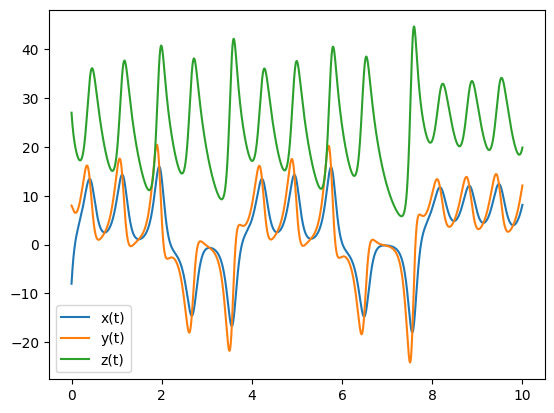

In [7]:
plt.plot(t_train, sol_evals[:,0] , label="x(t)")
plt.plot(t_train, sol_evals[:,1] , label="y(t)")
plt.plot(t_train, sol_evals[:,2] , label="z(t)")
plt.legend()

In [8]:
spdx = 20

In [9]:
def learned_animation(i, ax, time_vals:np.ndarray, func_vals:np.ndarray, azim_val:np.ndarray, maxs:list, mins:list, dgt:int,):
    k = int(i*spdx)
    x_min, y_min, z_min = mins
    x_max, y_max, z_max = maxs
    ax.clear()
    ax.view_init(elev=30, azim=azim_val[k], roll=0)
    ax.plot(func_vals[:k,0], func_vals[:k,1], func_vals[:k,2], )
    ax.set_xlabel(r"$x\left( t\right)$")
    ax.set_xlim(left=x_min, right=x_max)
    ax.set_ylabel(r"$y\left( t\right)$")
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.set_zlabel(r"$z\left( t\right)$")
    ax.set_zlim(bottom=z_min, top=z_max)
    ax.set_title(r'$x\left( t\right), y\left( t \right)$ and $z\left(t\right)$ at time $t$= ' + str(time_vals[k].round(dgt)))
    # ax.legend()

In [10]:

# rnd = -int(np.log10(np.min(sol_times[1:]-sol_times[:-1]))) 


# mins = sol_evals.min(0)
# maxs = sol_evals.max(0)

# phi_vals = np.linspace(-60, 300, sol_times.shape[0])

# anim_fig = plt.figure(figsize=(8,8), layout="constrained")
# ax = anim_fig.add_subplot(projection='3d', )
    
# ani_plot = animation.FuncAnimation(
#     anim_fig, learned_animation, fargs=(ax, sol_times, sol_evals, phi_vals, maxs, mins, rnd), save_count=50, 
#     frames=int(sol_times.shape[0]/spdx), interval=100, repeat=True, blit=False)
# # anim_fig.suptitle(fig_title,fontsize=10)
# writer = animation.FFMpegWriter(fps=60, codec='mpeg4', metadata=dict(artist='Me'), bitrate=-1)
# ani_plot.save('LorenzSystemAnimation2.gif', writer=writer)
# # ani_plot.save(os.path.join(sv_dir, ani_title+'.gif'), writer=writer)

In [11]:

# slvr = RFE(alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=5)
# slvr = Cross_Val_RFE(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", ADO_iters=ADO_iters)
# slvr = Cross_Val_RFE_V2(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=ADO_iters, thrshld_val=1e-8)
slvr = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=6, thrshld_val=1e-8)
# slvr = SSR(Kfolds=Kfolds, alpha=torch.zeros(size=(1,), device=dvc), percent_redux=0.70, criteria="coefficient_value", ADO_iters=ADO_iters, normalize=True)


# saveName = 'ResultsForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
# sv_mdl_name = 'LrnrForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
# Optim Results Names
# saveName = 'OptimalVer4ResultsForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)
# sv_mdl_name = 'OptimalVer4LrnrForSlurmJob'+str(jobID)+'ArrayNum'+str(jobVer)

In [ ]:
nDpnts = 4000
nTst = 1000
noise = 0.0

u_t = sol_evals + rng.normal(loc=0.0, scale=sol_evals.std()*noise, size=sol_evals.shape, )

# normalize since the 3 outputs are in differing ranges
normalize=False
if normalize:
    u_maxes = u_t.max(0)
    u_mins = u_t.min(0)
else:
    u_maxes = np.ones(shape=(3,))
    u_mins = np.zeros(shape=(3,))

data = (u_t - u_mins) / (u_maxes - u_mins)

pnts = np.copy(sol_times[:, np.newaxis])

trn_ids = rng.choice(a=np.arange(sol_evals.shape[0]), size=nDpnts, replace=False, )
valNtst_ids = np.setdiff1d(ar1=np.arange(sol_evals.shape[0]), ar2=trn_ids,)
tst_ids = rng.choice(a=valNtst_ids, size=nTst, replace=False)
val_ids = np.setdiff1d(valNtst_ids, tst_ids)

X_trn = np.copy( pnts[trn_ids, :])
U_trn = np.copy( data[trn_ids, :])
X_tst = np.copy( pnts[tst_ids, :])
U_tst = np.copy( data[tst_ids, :])


bounds = np.vstack((pnts.min(0), pnts.max(0)),).T


In [13]:
libr = ODE_Poly_Deriv_Library(
        poly_degree=2,
        include_poly_interaction=True,
        poly_interaction_only=False,
        derivative_order=0,
        include_bias=False,
        deriv_exclude_inds=None,
        device=dvc,
        data_type=torch.float32)

d_dict = {"Train_Inputs":X_trn, "Train_Targets":U_trn, "Test_Inputs":X_tst, "Test_Targets":U_tst}

col_smplr = Rand_Col_Sampler(sampler='halton', 
                             dims=1, seed=None, 
                             bounds=bounds, requires_grad=True, 
                             device=dvc, data_type=torch.float32)   

In [14]:
# prd_stuff = None
# four_stuff = {'scale':2.0, 'inpt_dim':X_trn.shape[1], 'embd_dim':20}
# rnd_wght_fct = True

prd_stuff = None
four_stuff = None
rnd_wght_fct = False

numLyrsU = 5
nPrLU = 128

In [15]:
if prd_stuff or four_stuff or rnd_wght_fct:
    # net = Networks.MLP(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,out_dim=U_trn.shape[1],
    #                 #   activ_func=torch.nn.Tanh(),
    #                   activ_func=SinAct(),
    #                   prd_stuff=prd_stuff, four_stuff=four_stuff,
    #                   rnd_wght_fct=rnd_wght_fct).to(device=dvc)
    
    net = Networks.PirateNet(in_dim=four_stuff["embd_dim"], num_layers=numLyrsU, hid_dim=nPrLU,
                             out_dim=U_trn.shape[1],
                             activ_func=torch.nn.Tanh(),
                            #  activ_func=SinAct(), 
                             alpha=0.0,
                             prd_stuff=prd_stuff, 
                             four_stuff=four_stuff, 
                             rnd_wght_fct=rnd_wght_fct).to(device=dvc)

else:
    net = torch.nn.Sequential(
            torch.nn.Linear(in_features=X_trn.shape[1], out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=U_trn.shape[1], bias=True)
    ).to(device=dvc, dtype=torch.float32)

    # # for param in net.parameters():
    # #     if param.ndim==2:
    # #         torch.nn.init.xavier_normal_(param, gain=1.41)
    # #     elif param.ndim==1:
    # #         torch.nn.init.zeros_(param)

    for name, param in net.named_parameters(): 
        if 'weight'in name:
            torch.nn.init.xavier_normal_(param.data, gain=1.41)
        # if 'bias' in name:
        #     torch.nn.init.zeros_(param.data)
    

In [16]:
libr.fit(network=net, inpts=torch.rand(size=(2,1), device=dvc, dtype=torch.float32))
lib_names = libr.get_library_names(net_out_func_names=["x", "y", "z"])

init_lmbda = torch.zeros(size=(len(lib_names),3), device=dvc,)
# init_lmbda = torch.rand(size=(len(lib_names),3), device=dvc,)


In [17]:
lrnr = EqLearner1D(net=net,
        Lmbda=init_lmbda.requires_grad_(True),
        lib_func=libr,
        sprs_slvr=slvr,
        data_dict=d_dict,
        tmprl_ords=[1, 1, 1],
        col_pnts_smplr=col_smplr,
        N_col_pnts=50_000,
        ntwk_out_names=["x", "y", "z"],
        device=dvc,
        data_type=torch.float32
)

In [18]:
run_time = 0
strt = perf_counter()
lrnr.AdamsOptimTraining(mode="pre", alpha=0.001, gamma=1e-6, min_epochs=500, max_epochs=10_000, 
                        lrn_rt=0.001, lp_ord=1.0, outputFreq=200,
                        betas=(0.9, 0.999), threshold=False,)
run_time += (perf_counter() - strt)

Beginning Adams Pre-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 8.24823e+02 | 1.22834e-01 | 0.0000e+00
            | Test Data  | 6.57036e+02 | 1.47680e-01 | 
Epoch   200 | Train Data | 8.42521e+01 | 5.39148e+02 | 3.7101e+00
            | Test Data  | 8.26661e+01 | 5.36843e+02 | 
Epoch   400 | Train Data | 2.41514e+01 | 1.15727e+03 | 6.6189e+00
            | Test Data  | 2.27428e+01 | 1.18012e+03 | 
Epoch   600 | Train Data | 4.00880e+00 | 1.03686e+03 | 7.2319e+00
            | Test Data  | 4.12067e+00 | 1.03856e+03 | 
Epoch   800 | Train Data | 1.91697e+00 | 9.16624e+02 | 8.9733e+00
            | Test Data  | 1.88826e+00 | 9.02975e+02 | 
Epoch  1000 | Train Data | 9.26532e-01 | 8.49806e+02 | 1.0500e+01
            | Test Data  | 9.13995e-01 | 8.46098e+02 | 
Epoch  1200 | Train Data | 1.88573e+00 | 7.72734e+02 | 1.1673e+01
            | Tes

In [19]:
evl_pnts = torch.from_numpy(pnts).to(device=dvc, dtype=torch.float32).requires_grad_(True)
evals = net(evl_pnts)
t_prtls = Nth_temporal_prtls(values=evals, pts=evl_pnts, orders=[1, 1, 1]).detach().cpu().numpy() *(u_maxes - u_mins) 

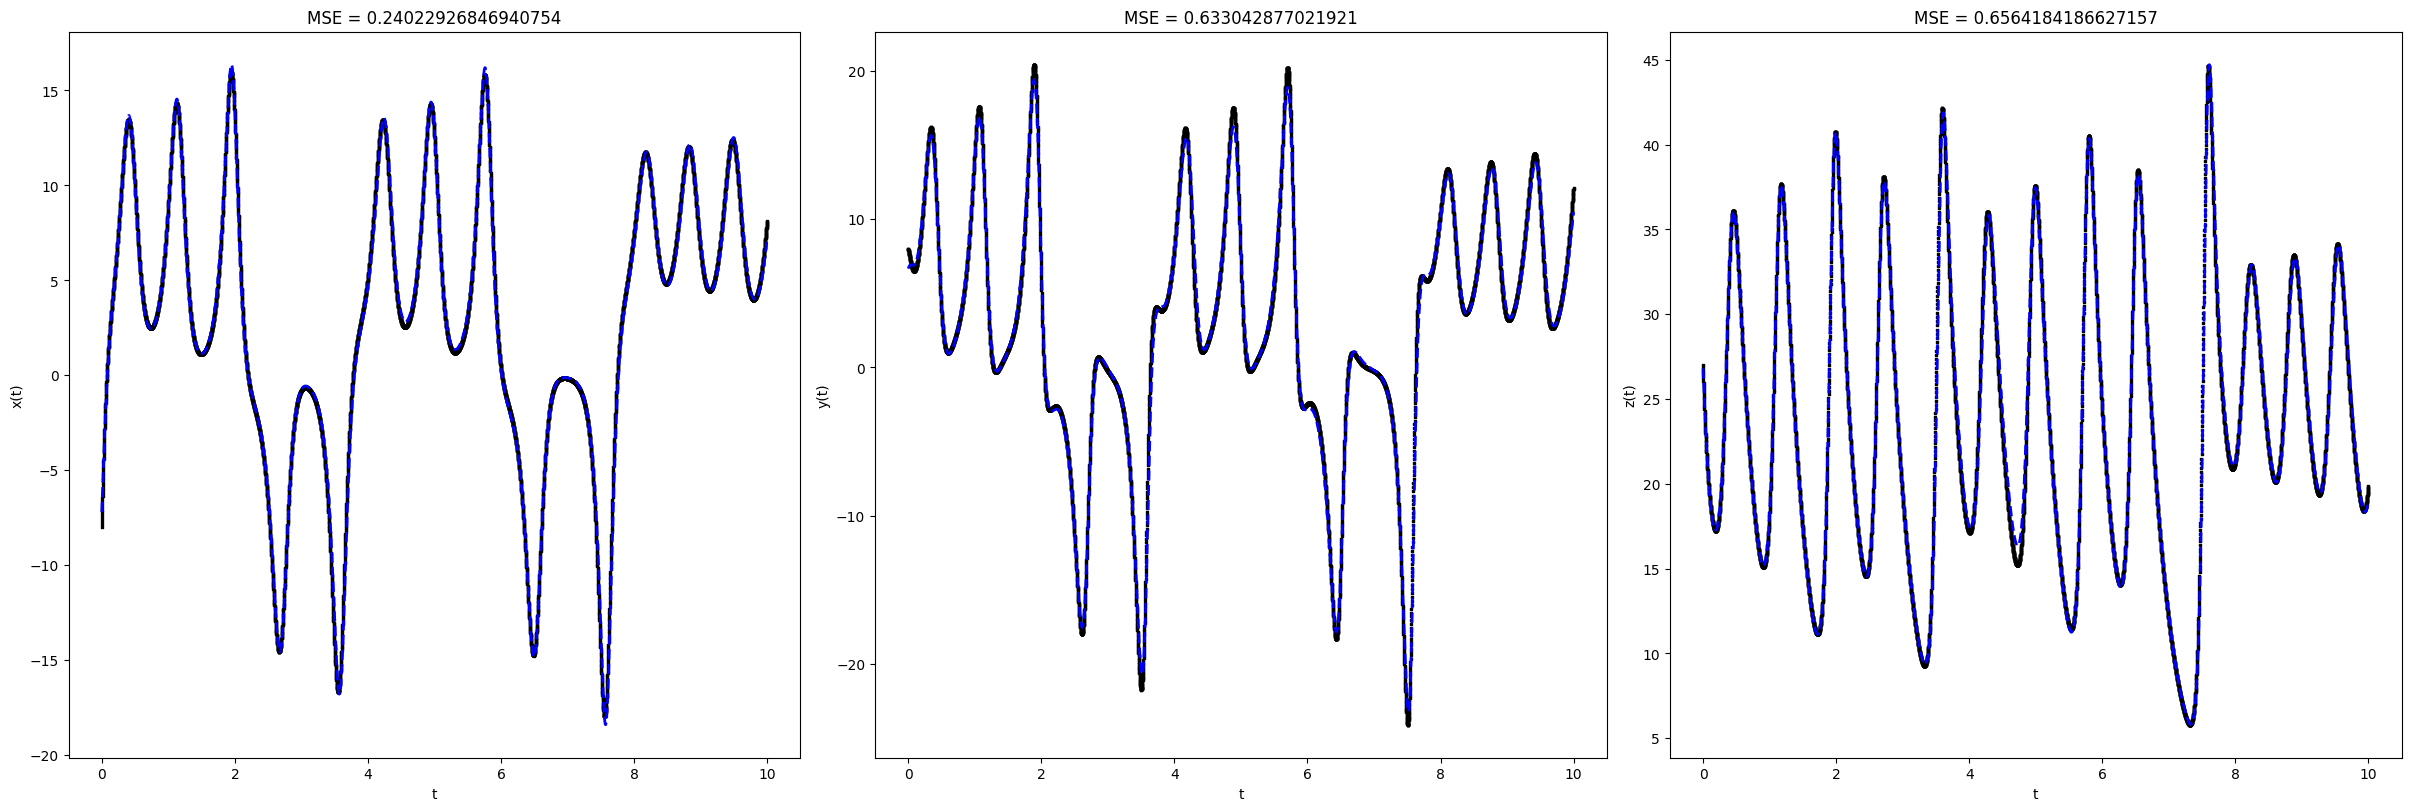

In [22]:
_, axes = plt.subplots(nrows=1, ncols=3, sharey=False, sharex=True, layout='constrained', figsize=(24,8))

mid_net_evals = evals.detach().cpu().numpy() *(u_maxes - u_mins) + u_mins
# mse = np.mean((mid_net_evals - (sol_evals - u_mins)/(u_maxes - u_mins))**2, axis=0)
mse = np.mean((mid_net_evals - sol_evals )**2, axis=0)

evals_t = np.zeros_like(sol_t)
evals_t[1:-1] = (mid_net_evals[2:] - mid_net_evals[:-2])/(2*dt)
evals_t[0] = (-3*mid_net_evals[0] + 4*mid_net_evals[1] - mid_net_evals[2])/(2*dt)
evals_t[-1] = (1*mid_net_evals[-3] - 4*mid_net_evals[-2] + 3*mid_net_evals[-1])/(2*dt)

axes[0].plot(pnts, mid_net_evals[:,0], 'b--', linewidth=2.0)
# axes[0].scatter(x=pnts, y=(sol_evals[:,0] - u_mins[0])/(u_maxes[0] - u_mins[0]), marker=',', s=4.0, color='k')
axes[0].scatter(x=pnts, y=sol_evals[:,0], marker=',', s=4.0, color='k')
axes[0].set_ylabel("x(t)")
axes[0].set_xlabel("t")
axes[0].set_title(f"MSE = {mse[0]}")

axes[1].plot(pnts, mid_net_evals[:,1], 'b--', linewidth=2.0)
# axes[1].scatter(x=pnts, y=(sol_evals[:,1] - u_mins[1])/(u_maxes[1] - u_mins[1]), marker=',', s=4.0, color='k')
axes[1].scatter(x=pnts, y=sol_evals[:,1], marker=',', s=4.0, color='k')
axes[1].set_ylabel("y(t)")
axes[1].set_xlabel("t")
axes[1].set_title(f"MSE = {mse[1]}")

axes[2].plot(pnts, mid_net_evals[:,2], 'b--', linewidth=2.0)
# axes[2].scatter(x=pnts, y=(sol_evals[:,2] - u_mins[2])/(u_maxes[2] - u_mins[2]), marker=',', s=4.0, color='k')
axes[2].scatter(x=pnts, y=sol_evals[:,2], marker=',', s=4.0, color='k')
axes[2].set_ylabel("z(t)")
axes[2].set_xlabel("t")
axes[2].set_title(f"MSE = {mse[2]}");


# axes[0].plot(pnts, evals_t[:,0], 'b--', linewidth=2.0)
# # axes[0].plot(pnts, t_prtls[:,0], 'r.-', linewidth=2.0)
# axes[0].scatter(x=pnts, y=sol_t[:,0], marker=',', s=2.0, color='k')
# axes[0].set_ylabel(r"$x^{\prime}(t)$")
# axes[0].set_xlabel("t")

# axes[1].plot(pnts, evals_t[:,1], 'b--', linewidth=2.0)
# # axes[1].plot(pnts, t_prtls[:,1], 'r.-', linewidth=2.0)
# axes[1].scatter(x=pnts, y=sol_t[:,1], marker=',', s=2.0, color='k')
# axes[1].set_ylabel(r"$y^{\prime}(t)$")
# axes[1].set_xlabel("t")

# axes[2].plot(pnts, evals_t[:,2], 'b--', linewidth=2.0)
# # axes[2].plot(pnts, t_prtls[:,2], 'r.-', linewidth=2.0)
# axes[2].scatter(x=pnts, y=sol_t[:,2], marker=',', s=2.0, color='k')
# axes[2].set_ylabel(r"$z^{\prime}(t)$")
# axes[2].set_xlabel("t")


In [23]:
sol_evals[0]

array([-8.,  8., 27.])

In [24]:
mid_net_evals[0]

array([-7.20120525,  6.66789103, 26.81539536])

In [25]:
np.mean((evals_t[1000:3000] - t_prtls[1000:3000])**2, axis=0)

array([2.64198794e-05, 4.87070671e-05, 7.38460646e-05])

In [26]:
np.mean((evals_t[1000:3000] - sol_t[1000:3000])**2, axis=0)

array([16.44510892, 85.68665725, 25.94593679])

In [27]:
np.mean((sol_t[1000:3000] - t_prtls[1000:3000])**2, axis=0)

array([16.45532599, 85.64877058, 25.94127947])

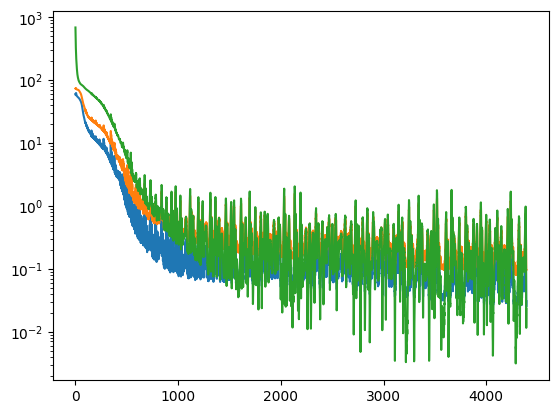

In [28]:
plt.semilogy(lrnr.AdamsPreTrnDataLoss)

In [29]:
sol_evals[0:2,:]

array([[-8.        ,  8.        , 27.        ],
       [-7.84087857,  7.9835534 , 26.86488244]])

In [30]:
mid_net_evals[0:2,:]

array([[-7.20120525,  6.66789103, 26.81539536],
       [-7.09920979,  6.68306446, 26.71695137]])

In [31]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [32]:
tst_lib = np.concat((mid_net_evals, mid_net_evals[:,0:1]*mid_net_evals, mid_net_evals[:,1:2]*mid_net_evals[:,1:], mid_net_evals[:,2:3]**2), axis=1)
trch_tst_lib = torch.from_numpy(tst_lib).to(dtype=torch.float32)
torch_evals_t = torch.from_numpy(evals_t).to(dtype=torch.float32)

In [33]:
act_lib = np.concat((sol_evals, sol_evals[:,0:1]*sol_evals, sol_evals[:,1:2]*sol_evals[:1:], sol_evals[:,2:3]**2), axis=1)
trch_sol_lib = torch.from_numpy(act_lib).to(dtype=torch.float32)
torch_sol_t = torch.from_numpy(sol_t).to(dtype=torch.float32)

In [34]:
print(np.linalg.lstsq(a=tst_lib[:,[0,1]], b=evals_t[:,0:1], rcond=None )[0])
print(np.linalg.lstsq(a=act_lib[:,[0,1]], b=sol_t[:,0:1], rcond=None )[0])

[[-10.39432069]
 [ 10.41686561]]
[[-9.99980203]
 [ 9.99980186]]


In [35]:
print(np.linalg.lstsq(a=tst_lib[:,[0,1,5]], b=evals_t[:,1:2], rcond=None )[0])
print(np.linalg.lstsq(a=act_lib[:,[0,1,5]], b=sol_t[:,1:2], rcond=None )[0])

[[22.40544551]
 [ 0.44994131]
 [-0.85480277]]
[[27.99804455]
 [-0.99962724]
 [-0.9999448 ]]


In [36]:
print(np.linalg.lstsq(a=tst_lib[:,[2,4]], b=evals_t[:,2:3], rcond=None )[0])
print(np.linalg.lstsq(a=act_lib[:,[2,4]], b=sol_t[:,2:3], rcond=None )[0])

[[-2.74392469]
 [ 1.02845644]]
[[-2.66659357]
 [ 0.99997082]]


In [40]:
tst_slvr = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device='cpu'), normalize=True, annealing_factor=1, criteria="coefficient_value", selection="individual", best=True,)
# tst_slvr = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device=dvc), normalize=False, annealing_factor=1, criteria="coefficient_value", selection="individual", best=True,)
# tst_slvr = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device='cpu'), normalize=True, annealing_factor=1, criteria="model_residual", selection="individual", best=True,)
# tst_slvr = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device='cpu'), normalize=False, annealing_factor=1, criteria="model_residual", selection="individual", best=True,)

In [41]:
print(RFESparseRegression(A=trch_tst_lib, b=torch_evals_t[:,0:1], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_tst_lib, b=torch_evals_t[:,0:1]))

(tensor([[-5.4390e+00],
        [ 7.0243e+00],
        [-1.7053e-01],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [-1.3696e-01],
        [ 0.0000e+00],
        [ 8.8351e-02],
        [ 4.7815e-03]]), tensor([[-10.0824],
        [  9.9114],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000]]))
tensor([[-10.0824],
        [  9.9113],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000],
        [  0.0000]])


In [42]:
mags = torch.linalg.vector_norm(trch_sol_lib, ord=2, dim=0)
m = trch_sol_lib.shape[1]
# below are some tensor (arrays) to store the cs that come from removing a feature and the
# storing of the RLS values for later.
cs = torch.zeros(size=(m,m+1), dtype=trch_sol_lib.dtype, device=trch_sol_lib.device)
Rls = torch.empty(size=(m+1,), dtype=trch_sol_lib.dtype, device=trch_sol_lib.device)
ids = [i for i in range(m)]
# now scale the A matrix
Ap = trch_sol_lib/mags

In [43]:
i=-1

In [44]:
ids

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [45]:
torch.linalg.lstsq(Ap[:, [0, 2, 5, 6, 7, 8, 9]].cpu(), torch_sol_t[:,1:2].cpu())[0]

tensor([[ 2.2018e+04],
        [ 1.4073e-01],
        [-2.4281e+04],
        [ 2.9946e+02],
        [-2.9946e+02],
        [-2.9942e+02],
        [-1.2045e-01]])

In [46]:
Ap[:, [0, 2, 5, 6, 7, 8, 9]].pinverse() @ torch_sol_t[:,1:2]

tensor([[ 2.2018e+04],
        [ 1.4697e-01],
        [-2.4281e+04],
        [ 2.4992e+05],
        [ 2.4277e+05],
        [ 5.8610e+03],
        [-1.6198e-01]])

In [182]:
# for i in range(0, m):
#     cp = torch.linalg.lstsq(Ap[:, ids], b)[0]                   # Get the new candidate solution with the new Lt matrix
#     cs[ids,i:i+1] = cp
#     # get the least important feature
#     lst = cp.abs().argmin()
#     ids.pop(lst)                                        # Remove this feature from being updates in the Cs that tracks the removal of feature
i+=1
cp = torch.linalg.lstsq(Ap[:, ids], torch_sol_t[:,1:2])[0]                   # Get the new candidate solution with the new Lt matrix
cs[ids,i:i+1] = cp
# get the least important feature
lst = cp.abs().argmin()
ids.pop(lst)                                        # Remove this feature from being updates in the Cs that tracks the removal of feature

4

In [183]:
cp

tensor([[ 2.2018e+04],
        [-2.2476e+02],
        [ 2.3131e+01],
        [ 2.5550e+01],
        [-1.7857e+01],
        [-2.4281e+04],
        [ 2.2476e+02],
        [-2.2476e+02],
        [-2.2476e+02],
        [-3.2732e+01]])

In [184]:
ids

[0, 1, 2, 3, 5, 6, 7, 8, 9]

In [185]:
[4,3]

[4, 3]

In [186]:
# Ok so now cp and ids only have one element meaning that Lt and B have one feature and element
# after the loop cp should be an all zeros vector
Rls[:] = torch.linalg.vector_norm(Ap@cs - torch_sol_t[:,1:2], ord=2, dim=0,).pow(2)
metrics = Rls[1:]/Rls[:-1]   

In [47]:
print(RFESparseRegression(A=trch_sol_lib, b=torch_sol_t[:,0:1], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_sol_lib, b=torch_sol_t[:,0:1]))

(tensor([[-9.9998e+00],
        [ 2.4999e+00],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [ 7.5507e-07],
        [ 0.0000e+00],
        [-3.1249e-01],
        [ 3.1249e-01],
        [ 9.2591e-02],
        [ 0.0000e+00]]), tensor([[-9.9998],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.3704],
        [ 0.0000]]))
tensor([[-9.9998],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.3704],
        [ 0.0000]])


In [48]:
print(RFESparseRegression(A=trch_tst_lib, b=torch_evals_t[:,1:2], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_tst_lib, b=torch_evals_t[:,1:2]))

(tensor([[ 2.2586e+01],
        [ 1.8927e+00],
        [-2.5270e-01],
        [ 0.0000e+00],
        [ 0.0000e+00],
        [-8.6367e-01],
        [ 0.0000e+00],
        [-5.9231e-02],
        [ 8.8555e-03]]), tensor([[25.1102],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.9389],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]]))
tensor([[25.1103],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.9389],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]])


In [50]:
print(RFESparseRegression(A=trch_sol_lib, b=torch_sol_t[:,1:2], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_sol_lib, b=torch_sol_t[:,1:2]))

(tensor([[ 2.7998e+01],
        [-2.5010e-01],
        [ 9.2606e-03],
        [ 2.7265e-03],
        [-1.7482e-03],
        [-9.9993e-01],
        [ 3.1263e-02],
        [-3.1263e-02],
        [-9.2632e-03],
        [-4.3428e-04]]), tensor([[ 2.7998e+01],
        [-2.4990e-01],
        [ 5.6909e-05],
        [-1.2572e-06],
        [ 0.0000e+00],
        [-9.9994e-01],
        [ 3.1238e-02],
        [-3.1238e-02],
        [-9.2561e-03],
        [-1.4710e-06]]))
tensor([[ 2.7998e+01],
        [-4.9981e-01],
        [ 5.6419e-05],
        [-1.2619e-06],
        [ 0.0000e+00],
        [-9.9994e-01],
        [ 0.0000e+00],
        [-6.2476e-02],
        [ 0.0000e+00],
        [-1.4549e-06]])


In [51]:
print(RFESparseRegression(A=trch_tst_lib, b=torch_evals_t[:,2:3], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_tst_lib, b=torch_evals_t[:,2:3]))

(tensor([[-5.8870],
        [ 3.1854],
        [-2.6113],
        [ 0.0000],
        [ 1.0170],
        [ 0.1596],
        [ 0.0000],
        [-0.1057],
        [ 0.0000]]), tensor([[ 0.0000],
        [ 0.0000],
        [-2.7253],
        [ 0.0000],
        [ 1.0068],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]]))
tensor([[ 0.0000],
        [ 0.0000],
        [-2.7253],
        [ 0.0000],
        [ 1.0068],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]])


In [52]:
print(RFESparseRegression(A=trch_sol_lib, b=torch_sol_t[:,2:3], annealing_factor=2.0, best=True))
print(tst_slvr.solve(A=trch_sol_lib, b=torch_sol_t[:,2:3]))

(tensor([[ 0.0000e+00],
        [ 0.0000e+00],
        [-2.6663e+00],
        [ 1.2048e-04],
        [ 9.9989e-01],
        [ 3.9150e-07],
        [ 0.0000e+00],
        [ 3.2784e-07],
        [ 0.0000e+00],
        [-1.3836e-05]]), tensor([[ 0.0000],
        [ 0.0000],
        [-2.6666],
        [ 0.0000],
        [ 1.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]]))
tensor([[ 0.0000],
        [ 0.0000],
        [-2.6666],
        [ 0.0000],
        [ 1.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000]])


In [ ]:
if lrnr.lmbda.nonzero().size(0)==0:
    lrnr.lmbda.data = torch.ones_like(lrnr.lmbda.data)

# if lrnr._AdamsPreTrnAlpha==0:
#     lrnr._AdamsPreTrnAlpha=1e-5

In [37]:
lrnr.ADO_Training(iters=6, optim_alpha_grwth_methd="poly", Early_Term=True, p=0.5)

lmbda at ADO iter 0 is ...
The current Learned Equation(s) is(are) ... 
x_t = -5.13706350e+00*x + 6.02776146e+00*y + -1.26442600e-02*(x)^2 + -1.68592260e-01*(x)(z) + 1.57293510e-01*(y)(z) 
y_t = 2.13684349e+01*x + 1.16584480e+00*y + 9.42402000e-03*(x)(y) + -8.24091490e-01*(x)(z) + -2.34705800e-02*(y)(z) 
z_t = -2.85320163e+00*z + -1.38181120e-01*(x)^2 + 1.12335980e+00*(x)(y) + -1.81241000e-03*(x)(z) + 9.33218000e-03*(z)^2
Beginning Adams ADO-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 1.54998e+00 | 4.02861e+01 | 3.9021e+01
            | Test Data  | 1.30477e+02 | 8.27506e+03 | 
Epoch   100 | Train Data | 1.46900e+01 | 1.60265e+01 | 3.8971e+01
            | Test Data  | 1.35959e+01 | 1.51178e+01 | 
Epoch   200 | Train Data | 5.19600e+00 | 7.83172e+00 | 3.8951e+01
            | Test Data  | 4.77091e+00 | 7.32242e+00 | 
Epoch   300 | Train Dat

In [38]:
lrnr.Learned_EQ(output=True, );

The current Learned Equation(s) is(are) ... 
x_t = -1.06354723e+01*x + 1.06497679e+01*y 
y_t = 2.27583466e+01*x + 4.05993760e-01*y + -8.61762640e-01*(x)(z) 
z_t = -2.72734380e+00*z + -1.04036590e-01*(x)^2 + 1.10841119e+00*(x)(y) 



\begin{align*}
       x^{\prime}(t) &= -10x(t) + 10y(t)\\
       y^{\prime}(t) &=  28x(t) - y(t) + x(t)z(t)\\
       z^{\prime}(t) &= -2.66667z(t) + x(t)y(t)\\
\end{align*}

In [41]:
lrnr.Save_Model(data_set="LorenzSystem", fname="Close_PosterMlp_Model")

Saved_Models Directory already exists so did not create it
LorenzSystem Directory already exists so did not create it


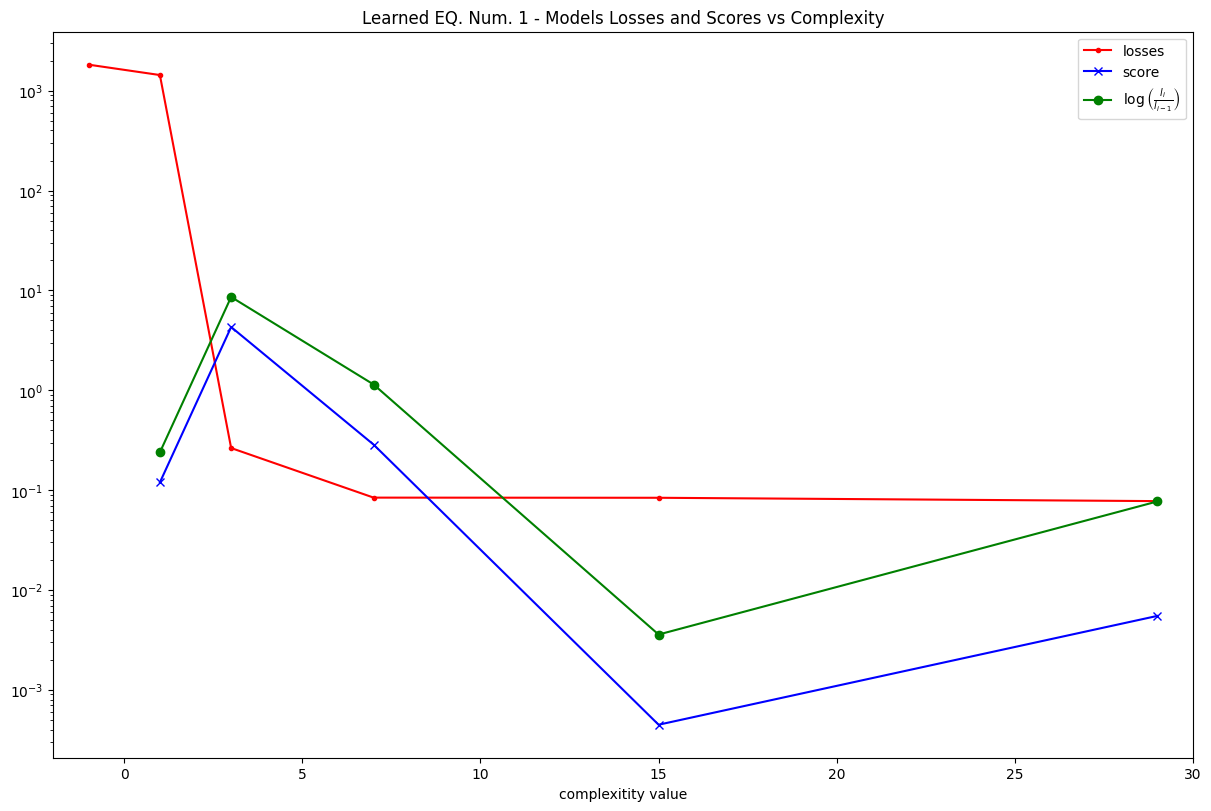

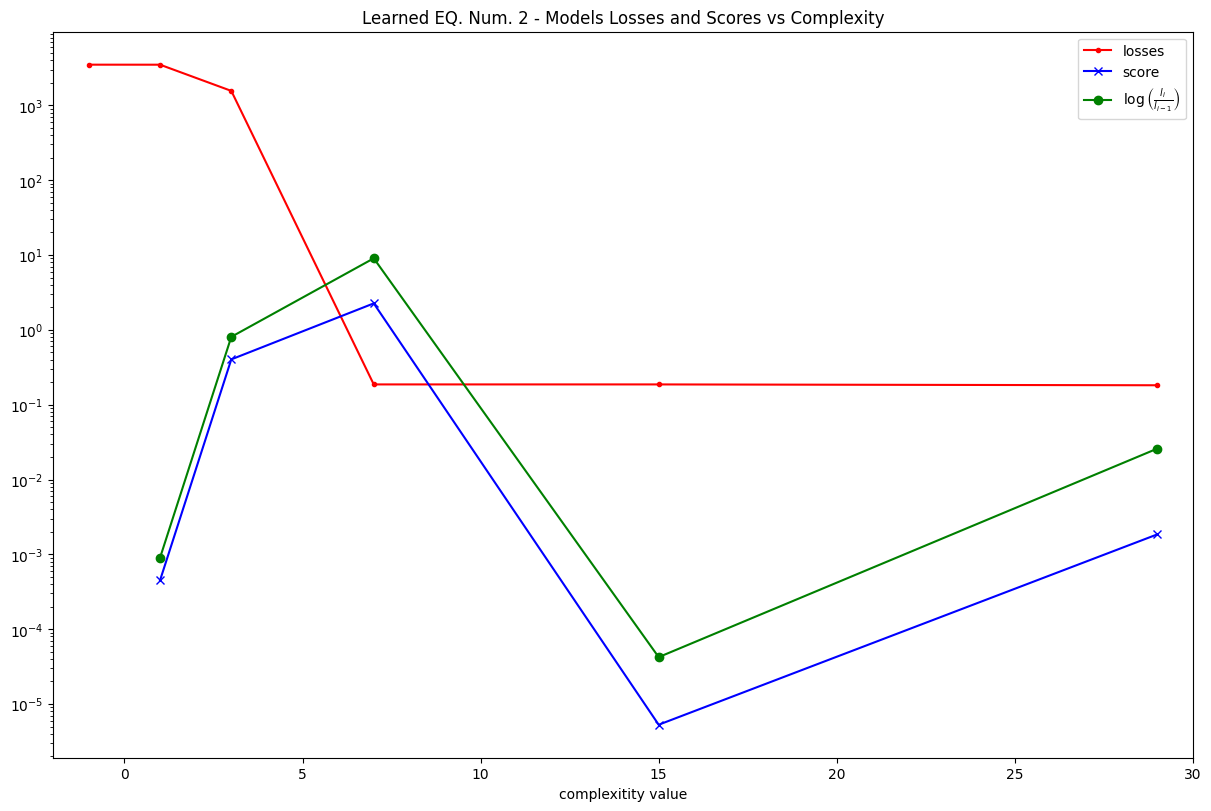

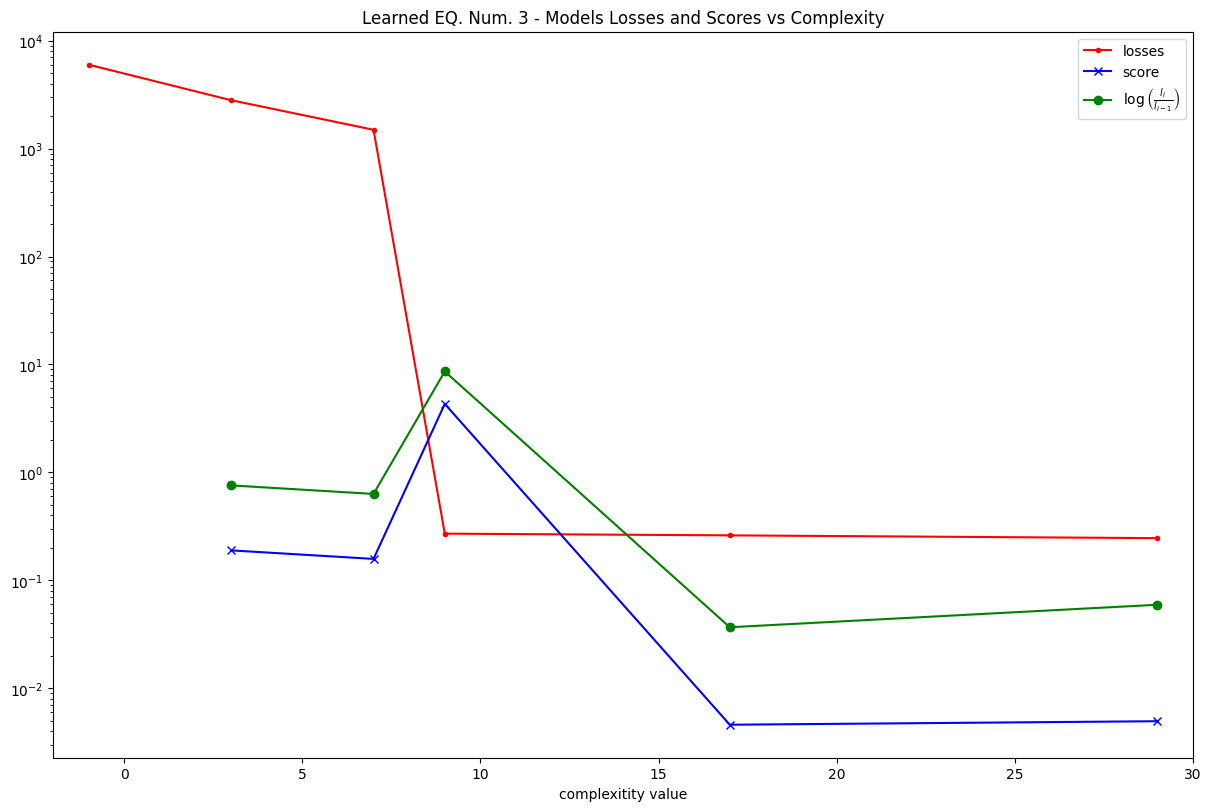

In [42]:
lrnr.Loss_Score_Complexity_Plot(dataset_name="LorenzSystem", save_dir_name="Close_PosterMlp_Model", save_figs=True)

\begin{align*}
       x^{\prime}(t) &= -10x(t) + 10y(t)\\
       y^{\prime}(t) &=  28x(t) - y(t) + x(t)z(t)\\
       z^{\prime}(t) &= -2.66667z(t) + x(t)y(t)\\
\end{align*}

In [43]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [44]:
lrnd_lmbda = lrnr.lmbda.data.cpu().numpy()
tru_lmbda = np.zeros_like(lrnd_lmbda)
tru_lmbda[0,0] = -10
tru_lmbda[1,0] = 10

tru_lmbda[0,1] = 28.0
tru_lmbda[1,1] = -1.0
tru_lmbda[5,1] = 1.0

tru_lmbda[2,2] = -8/3
tru_lmbda[4,2] = 1.0

lrnd_eqs = []
for k in range(3):
    if k==0:
        lhs = "x_t = "
    elif k==1:
        lhs = "y_t = "
    else:
        lhs = "z_t = "
    nz_indices = lrnd_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(lrnd_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    lrnd_eqs.append(lhs[:-3])
    
tru_eqs = []
for k in range(3):
    if k==0:
        lhs = "x_t = "
    elif k==1:
        lhs = "y_t = "
    else:
        lhs = "z_t = "
    nz_indices = tru_lmbda[:,k].nonzero()[0]
    for ind in nz_indices:
        lhs += str(np.round(tru_lmbda[ind,k],3).item())[:6]+lib_names[ind] + " + "
    tru_eqs.append(lhs[:-3])


In [45]:
print(lrnd_eqs)
print(tru_eqs)

['x_t = -10.63x + 10.649y', 'y_t = 22.757x + 0.4059y + -0.861(x)(z)', 'z_t = -2.726z + -0.104(x)^2 + 1.1080(x)(y)']
['x_t = -10.0x + 10.0y', 'y_t = 28.0x + -1.0y + 1.0(x)(z)', 'z_t = -2.667z + 1.0(x)(y)']


In [ ]:
lrnz_prds = lrnr.net(torch.from_numpy(pnts).to(device=dvc, dtype=torch.float32)).detach().cpu().numpy()
# sol_evals
# sol_times
# pnts

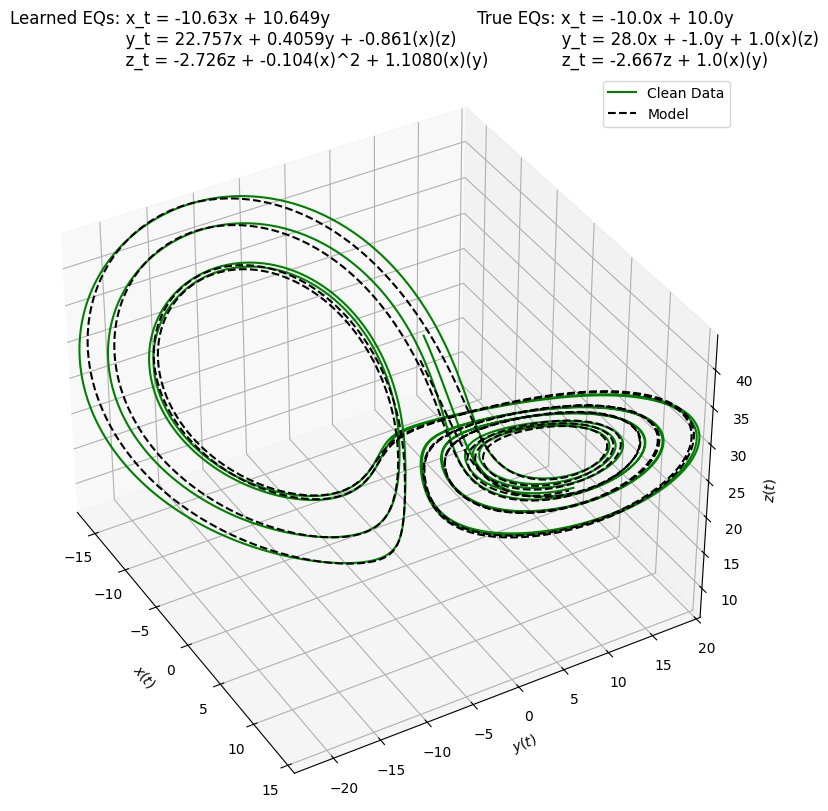

In [62]:
# print(lrnd_eqs)
# print(tru_eqs)
fig_title = "Learned EQs: " + lrnd_eqs[0] + "                            True EQs: " + tru_eqs[0] + "\n    "
fig_title +="                  " + lrnd_eqs[1] + "                    " + tru_eqs[1] + "\n    "
fig_title +="                  " + lrnd_eqs[2] + "              " + tru_eqs[2] 
# print(fig_title)

lrnz_fig = plt.figure(figsize=(8,8), layout="constrained")
lrnz_ax = lrnz_fig.add_subplot(projection='3d', )

# k = int(i*spdx)
x_min, y_min, z_min = sol_evals.min(0)
x_max, y_max, z_max = sol_evals.max(0)
lrnz_ax.clear()
lrnz_ax.view_init(elev=37, azim=-30, roll=0)
lrnz_ax.plot(sol_evals[:,0], sol_evals[:,1], sol_evals[:,2], 'g-', label='Clean Data')
lrnz_ax.plot(lrnz_prds[:,0], lrnz_prds[:,1], lrnz_prds[:,2], 'k--', label="Model")
# lrnz_ax.scatter3D(xs=lin3D_lrn_data[:,0], ys=lin3D_lrn_data[:,1], zs=lin3D_lrn_data[:,2], s=2.0, marker='.', color="magenta", label='5% Noisy Data')
lrnz_ax.set_xlabel(r"$x\left( t\right)$")
lrnz_ax.set_xlim(left=x_min, right=x_max)
lrnz_ax.set_ylabel(r"$y\left( t\right)$")
lrnz_ax.set_ylim(bottom=y_min, top=y_max)
lrnz_ax.set_zlabel(r"$z\left( t\right)$")
lrnz_ax.set_zlim(bottom=z_min, top=z_max)
lrnz_ax.legend()
# ax.set_title(r'$x\left( t\right), y\left( t \right)$ and $z\left(t\right)$ at time $t$')
lrnz_ax.set_title(fig_title, loc='Left');
# ax.legend()

lrnz_fig.savefig(fname="LorenzSystemFig.png")

In [90]:

n_trgts = 3

In [91]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [111]:
train_inputs = torch.from_numpy(lrnr.data_dict['Train_Inputs']).to(device=lrnr.device, dtype=lrnr.data_type)
test_inputs = torch.from_numpy(lrnr.data_dict['Test_Inputs']).to(device=lrnr.device, dtype=lrnr.data_type).requires_grad_(True)

# iter_lmbdas = [torch.ones_like(init_lmbda),
#                torch.tensor(
#                    [[-1.45575561e+01,-1.54857712e+01,1.89922428e+01],
#                     [1.25531673e+01,1.62842159e+01,-3.61521339e+01],
#                     [-9.04923500e-01,0,1.15076675e+01],
#                     [0,-7.23740816e+00,6.04128504e+00],
#                     [8.86408997e+00,2.43156223e+01,0],
#                     [0,0,-2.95799046e+01],
#                     [-4.54004860e+00,-1.79114971e+01,2.31170635e+01],
#                     [0,0,5.51476908e+00],
#                     [0,0,0]]
#                ,device=lrnr.device, dtype=lrnr.data_type),
#                torch.tensor(
#                    [[-1.20543003e+01,-1.00351601e+01,2.54422340e+01],
#                     [1.08296938e+01,1.03573971e+01,-4.14225845e+01],
#                     [0,0,1.12350025e+01],
#                     [0,0,0],
#                     [2.22322679e+00,0,0],
#                     [0,0,-2.32472496e+01],|
#                     [0,-1.81010950e-01,2.83080635e+01],
#                     [0,0,0],
#                     [0,0,0],]
#                ,device=lrnr.device, dtype=lrnr.data_type),
#                torch.tensor(
#                    [[-1.06658478e+01,-1.05266504e+01,2.43237267e+01],
#                     [1.06080379e+01,1.12082501e+01,-3.93908844e+01],
#                     [0,0,1.12662134e+01],
#                     [0,0,0],
#                     [4.36118960e-01,0,0],
#                     [0,0,-2.26794319e+01],
#                     [0,-7.73250940e-01,2.68221741e+01],
#                     [0,0,0],
#                     [0,0,0],]
#                ,device=lrnr.device, dtype=lrnr.data_type)
#                ]

In [120]:
nzs = [ [i.item() for i in lrnr.lmbda.data[:,j].nonzero()] for j in range(3)]
nzs = [ list(range(9)) for _ in range(3)]
iter_lmbdas = [torch.ones_like(init_lmbda), lrnr.lmbda.data]
iter_lmbdas.append(torch.zeros(size= lrnr.lmbda.data.size(), device=lrnr.device, dtype=lrnr.data_type))

model_losses = []
model_complxtys = []
model_scores = []

# get the evaluation of the library functions over the collocation points for later. 
np_colpnts = lrnr.col_pnts_smplr.sample(n_pnts=lrnr.N_col_pnts)
colpnts = torch.from_numpy(np_colpnts).to(device=lrnr.device, dtype=lrnr.data_type).requires_grad_(True)
col_preds = lrnr.net(colpnts)
t_prtls = Nth_temporal_prtls(values=col_preds, pts=colpnts, orders=lrnr.tmprl_ords).detach()
lib_evals = lrnr.lib_func.Calc(network=lrnr.net, inpts=colpnts).detach()

tst_col_preds = lrnr.net(test_inputs)
tst_t_prtls = Nth_temporal_prtls(values=tst_col_preds, pts=test_inputs, orders=lrnr.tmprl_ords).detach_()
tst_lib_evals = lrnr.lib_func.Calc(network=lrnr.net, inpts=test_inputs).detach()
# need the complexity of each library term for choosing the best equation bellow. 
lib_complexities = lrnr.lib_func.Get_Lib_Complexities()
n_lib_trms = lrnr.lmbda.shape[0]
# need to store which equations were considered throughout the optimization steps and here. 
eqs_ids = [[np.arange(n_lib_trms)] for _ in range(n_trgts)]
pre_ids = [np.arange(n_lib_trms) for _ in range(n_trgts)]
eq_complexities = [[lib_complexities.sum().item() + n_lib_trms - 1] for _ in range(n_trgts)]
slctd_eqs_indices = []

regress_alphas = lrnr.sprs_slvr.alpha

In [121]:
# torch.linalg.lstsq(lib_evals[2:], t_prtls[:,q:q+1], rcond=None, driver=None)[0]
print(lib_evals.shape,t_prtls.shape)
list(range(5))

torch.Size([50000, 9]) torch.Size([50000, 3])


[0, 1, 2, 3, 4]

In [122]:
for q in range(n_trgts):
    print(q)
    # recall each of the n targeted equation might have a different number of functions selected after optimization step. 
    n_act_funcs = len(nzs[q])
    # since the library should be greated culled after the K optim step, just do a greedy sparse regression to 
    # consider remaining models until the Null/Empty model. These are the extra lambdas.
    extra_lmbdas = Specified_Optim_Regres(A=lib_evals, b=t_prtls[:,q:q+1], activ_ids=nzs[q], alpha=regress_alphas).cpu().numpy()
    # last/remaining models
    lst_models = np.reshape(extra_lmbdas, shape=(n_act_funcs*n_lib_trms + n_lib_trms,), order="F").reshape((n_act_funcs+1,n_lib_trms,1), order="C")
    # all models considered throughout tryining/optim. step. 
    # ado_models = np.concat((iter_lmbdas[:-1, :,q:q+1].detach().cpu().numpy(), lst_models), axis=0)
    ado_models = np.concat(([lmb[:,q:q+1].detach().cpu().numpy() for lmb in iter_lmbdas[:-1]], lst_models), axis=0)
    # get the complexity of each distinct model as it is possible to have some combination of the lib. funcs repeated 
    # from one optim step to the next.
    for lm in ado_models:
        idx = np.nonzero(lm[:,0])[0]    
        if idx.size==pre_ids[q].size:
            continue
        pre_ids[q] = idx
        eqs_ids[q].append(idx)
        eq_complexities[q].append(lib_complexities[idx].sum().item() + idx.size - 1)
    # number of distinct library func. combinations. 
    n_eqs = len(eqs_ids[q])
    eq_losses = torch.empty(size=(n_eqs,), device=lrnr.device, dtype=lrnr.data_type)
    for j in range(n_eqs):
        # Now get the equation coefficients for the each model and the loss on the test library. 
        # eq_coefs = torch.linalg.lstsq(lib_evals[:,eqs_ids[q][j]],t_prtls[:,q:q+1])[0]
        eq_coefs = solve_svd(lib_evals[:,eqs_ids[q][j]],t_prtls[:,q:q+1], alphas=regress_alphas)
        eq_losses[j] = torch.mean( (tst_lib_evals[:,eqs_ids[q][j]]@eq_coefs -tst_t_prtls[:,q:q+1] ) **2 )
            
    eq_lsses = eq_losses.cpu().numpy()
    model_complexities = np.asarray(eq_complexities[q])
    # flippig the order of the matrix valyes since want the complexity to increase as we go down across (-->) matrix
    # so model loss will then decrease as we get more and more complex equation (reading complexity vs loss curver right left. )
    flppd_eq_losses = np.flipud(eq_lsses)
    model_losses.append(flppd_eq_losses)
    flppd_model_cmplx = np.flipud(model_complexities)
    model_complxtys.append(flppd_model_cmplx)
    # if this is not done, the complexity of the null/empty model is -1 : so make it 0 as no model had no complexity. 
    # flppd_model_cmplx[0] = np.int64(0)
    scores = -np.log(flppd_eq_losses[1:]/flppd_eq_losses[:-1]) / (flppd_model_cmplx[1:] - flppd_model_cmplx[:-1])
    model_scores.append(scores)
    max_scr_idx = scores.argmax()+1
    slctd_eqs_indices.append(eqs_ids[q][len(eqs_ids[q]) - max_scr_idx-1])


0
1
2


In [123]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [124]:
slctd_eqs_indices

[array([0, 1]), array([2, 5]), array([0, 1, 3, 4, 5, 8])]

In [131]:
eqs_ids[2]

[array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 3, 4, 5, 8]),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 3, 4, 5, 6, 7, 8]),
 array([0, 1, 3, 4, 5, 7, 8]),
 array([0, 1, 3, 4, 5, 8]),
 array([0, 1, 4, 5, 8]),
 array([1, 4, 5, 8]),
 array([1, 4, 5]),
 array([1, 4]),
 array([4]),
 array([], dtype=int64)]

In [32]:
torch.linalg.lstsq(lib_evals[:,[2,4]], t_prtls[:,2:3])[0]

tensor([[-1.2808],
        [ 1.6411]], device='cuda:0')

In [33]:
ado_models

array([[[ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ],
        [ 1.        ]],

       [[ 0.        ],
        [ 0.        ],
        [-2.6615088 ],
        [-0.07056399],
        [ 1.0759792 ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]],

       [[ 0.        ],
        [ 0.        ],
        [ 0.0912172 ],
        [-0.06153025],
        [ 0.0450896 ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]],

       [[ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [-0.03169974],
        [ 0.03465098],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]],

       [[ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ],
        [ 0.00761553],
        [ 0.        ],
        [ 0.        ],
   

In [31]:
slctd_eqs_indices

[array([0, 1]), array([0, 5, 7]), array([2, 3, 4])]

In [32]:
model_scores

[array([0.15316914, 3.48149371, 0.07884591]),
 array([0.01791965, 0.16167741, 4.32094049, 0.0121358 ]),
 array([0.23166306, 0.14127208, 3.94069767, 0.01397893])]

In [36]:
lrnr.AdamsOptimTraining(mode="post", alpha=1.0, gamma=0.0, min_epochs=1000, max_epochs=10_000, lrn_rt=0.001, lp_ord=1.0, outputFreq=200, betas=(0.9, 0.999), );

Beginning Adams Post-Training Optimization Now
            | Data  Type |  Data Loss  |  Pde Loss   | Lp Loss
---------------------------------------------------------------------------
Epoch     0 | Train Data | 8.90675e-02 | 2.09296e+00 | 5.0261e+01
            | Test Data  | 2.08739e+01 | 1.40302e+03 | 
Epoch   200 | Train Data | 1.91676e-01 | 1.74816e-01 | 5.0213e+01
            | Test Data  | 2.67631e-01 | 2.09049e-01 | 
Epoch   400 | Train Data | 1.21687e-01 | 9.93178e-02 | 5.0226e+01
            | Test Data  | 1.72784e-01 | 1.34210e-01 | 
Epoch   600 | Train Data | 9.52610e-02 | 8.62158e-02 | 5.0239e+01
            | Test Data  | 1.34091e-01 | 1.21804e-01 | 
Epoch   800 | Train Data | 9.72320e-02 | 1.68621e+00 | 5.0250e+01
            | Test Data  | 1.48392e-01 | 2.55244e+00 | 
Finished Adams Post Training


In [37]:
lrnr.Learned_EQ(output=True);

The current Learned Equation(s) is(are) ... 
x_t = -1.01174841e+01*x + 1.01394825e+01*y 
y_t = 2.52599316e+01*x + -9.24715280e-01*(x)(z) + -1.25254600e-02*(y)(z) 
z_t = -2.66250873e+00*z + -6.95639900e-02*(x)^2 + 1.07697928e+00*(x)(y) 


In [16]:
x_net =  torch.nn.Sequential(
            torch.nn.Linear(in_features=1, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
    ).to(device=dvc, dtype=torch.float32)

# # for param in net.parameters():
# #     if param.ndim==2:
# #         torch.nn.init.xavier_normal_(param, gain=1.41)
# #     elif param.ndim==1:
# #         torch.nn.init.zeros_(param)

for name, param in x_net.named_parameters(): 
    if 'weight'in name:
        torch.nn.init.xavier_normal_(param.data, gain=1.41)
    # if 'bias' in name:
    #     torch.nn.init.zeros_(param.data)

y_net =  torch.nn.Sequential(
            torch.nn.Linear(in_features=1, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
    ).to(device=dvc, dtype=torch.float32)

# # for param in net.parameters():
# #     if param.ndim==2:
# #         torch.nn.init.xavier_normal_(param, gain=1.41)
# #     elif param.ndim==1:
# #         torch.nn.init.zeros_(param)

for name, param in y_net.named_parameters(): 
    if 'weight'in name:
        torch.nn.init.xavier_normal_(param.data, gain=1.41)
    # if 'bias' in name:
    #     torch.nn.init.zeros_(param.data)


z_net =  torch.nn.Sequential(
            torch.nn.Linear(in_features=1, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=nPrLU, bias=True),
            # torch.nn.Tanh(),
            SinAct(),
            torch.nn.Linear(in_features=nPrLU, out_features=1, bias=True)
    ).to(device=dvc, dtype=torch.float32)

# # for param in net.parameters():
# #     if param.ndim==2:
# #         torch.nn.init.xavier_normal_(param, gain=1.41)
# #     elif param.ndim==1:
# #         torch.nn.init.zeros_(param)

for name, param in z_net.named_parameters(): 
    if 'weight'in name:
        torch.nn.init.xavier_normal_(param.data, gain=1.41)
    # if 'bias' in name:
    #     torch.nn.init.zeros_(param.data)

In [17]:
x_trn = np.copy(data[trn_ids, 0:1])
trn_x = torch.from_numpy(pnts[trn_ids]).to(device=dvc, dtype=torch.float32)
trgts_x = torch.from_numpy(sol_evals[trn_ids, 0:1]).to(device=dvc, dtype=torch.float32)
x_tst = np.copy(data[tst_ids, 0:1])
tst_x = torch.from_numpy(pnts[tst_ids]).to(device=dvc, dtype=torch.float32)
tst_trgts_x = torch.from_numpy(sol_evals[tst_ids, 0:1]).to(device=dvc, dtype=torch.float32)

y_trn = np.copy(data[trn_ids, 1:2])
trn_y = torch.from_numpy(pnts[trn_ids]).to(device=dvc, dtype=torch.float32)
trgts_y = torch.from_numpy(sol_evals[trn_ids, 1:2]).to(device=dvc, dtype=torch.float32)
y_tst = np.copy(data[tst_ids, 1:2])
tst_y = torch.from_numpy(pnts[tst_ids]).to(device=dvc, dtype=torch.float32)
tst_trgts_y = torch.from_numpy(sol_evals[tst_ids, 1:2]).to(device=dvc, dtype=torch.float32)




z_tst = np.copy(data[tst_ids, 2:3])
trn_z = torch.from_numpy(pnts[trn_ids]).to(device=dvc, dtype=torch.float32)
trgts_z = torch.from_numpy(sol_evals[trn_ids, 2:3]).to(device=dvc, dtype=torch.float32)
z_trn = np.copy(data[trn_ids, 2:3])
tst_z = torch.from_numpy(pnts[tst_ids]).to(device=dvc, dtype=torch.float32)
tst_trgts_z = torch.from_numpy(sol_evals[tst_ids, 2:3]).to(device=dvc, dtype=torch.float32)


x_lmbda = torch.zeros(size=(9,1), device=dvc, dtype=torch.float32, requires_grad=True)
y_lmbda = torch.zeros(size=(9,1), device=dvc, dtype=torch.float32, requires_grad=True)
z_lmbda = torch.zeros(size=(9,1), device=dvc, dtype=torch.float32, requires_grad=True)


In [18]:
criteria = torch.nn.MSELoss(reduction='mean')

In [19]:
optim_x = torch.optim.Adam(params=x_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_x.param_groups[0]['params'].append(x_lmbda)
optim_y = torch.optim.Adam(params=y_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_y.param_groups[0]['params'].append(y_lmbda)
optim_z = torch.optim.Adam(params=z_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_z.param_groups[0]['params'].append(z_lmbda)

In [20]:
print(trn_x.shape)
print(trgts_x.shape)
print(trn_y.shape)
print(trgts_y.shape)
print(trn_z.shape)
print(trgts_z.shape)
print("~"*30)
print(tst_x.shape)
print(tst_trgts_x.shape)
print(tst_y.shape)
print(tst_trgts_y.shape)
print(tst_z.shape)
print(tst_trgts_z.shape)

torch.Size([4000, 1])
torch.Size([4000, 1])
torch.Size([4000, 1])
torch.Size([4000, 1])
torch.Size([4000, 1])
torch.Size([4000, 1])
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
torch.Size([1000, 1])
torch.Size([1000, 1])
torch.Size([1000, 1])
torch.Size([1000, 1])
torch.Size([1000, 1])
torch.Size([1000, 1])


In [21]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
for k in range(5_000):
    optim_x.zero_grad(None)
    optim_y.zero_grad(None)
    optim_z.zero_grad(None)
    x_net.train()
    y_net.train()
    z_net.train()

    x_d_loss = criteria(x_net(trn_x), trgts_x)
    y_d_loss = criteria(y_net(trn_y), trgts_y)
    z_d_loss = criteria(z_net(trn_z), trgts_z)

    x_col_vals = x_net(col_pnts)
    x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1])
    y_col_vals = y_net(col_pnts)
    y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1])
    z_col_vals = z_net(col_pnts)
    z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1])

    library  = torch.concat((x_col_vals, y_col_vals, z_col_vals, x_col_vals.pow(2), x_col_vals*y_col_vals, x_col_vals*z_col_vals,  y_col_vals.pow(2), y_col_vals*z_col_vals, z_col_vals.pow(2),), dim=1)

    x_eq_loss = criteria(x_t, library@x_lmbda)
    y_eq_loss = criteria(y_t, library@y_lmbda)
    z_eq_loss = criteria(z_t, library@z_lmbda)

    loss = x_d_loss + y_d_loss + z_d_loss + 1e-3*x_eq_loss + 1e-3*y_eq_loss + 1e-3*z_eq_loss + 1e-6*Torch_Lp_Loss(x_lmbda, p=1.0) + 1e-6*Torch_Lp_Loss(y_lmbda, p=1.0) + 1e-6*Torch_Lp_Loss(z_lmbda, p=1.0) 
    loss.backward()

    optim_x.step()
    optim_y.step()
    optim_z.step()

    if (k+1)%500==0:
        x_net.eval()
        y_net.eval()
        z_net.eval()
        tst_loss = criteria(x_net(tst_x), tst_trgts_x).detach() + criteria(y_net(tst_y), tst_trgts_y).detach() + criteria(z_net(tst_z), tst_trgts_z).detach()
        print(tst_loss)

    

tensor(4.8049, device='cuda:0')
tensor(0.8444, device='cuda:0')
tensor(1.7910, device='cuda:0')
tensor(0.7445, device='cuda:0')
tensor(0.5411, device='cuda:0')
tensor(1.5105, device='cuda:0')
tensor(0.5378, device='cuda:0')
tensor(0.4280, device='cuda:0')
tensor(0.4204, device='cuda:0')
tensor(0.4101, device='cuda:0')


In [74]:
evl_pnts =torch.from_numpy(pnts).to(device=dvc, dtype=torch.float32).requires_grad_(True)
tmp_x = x_net(evl_pnts)
x_t_evals = Nth_temporal_prtls(values=tmp_x, pts=evl_pnts, orders=[1]).detach().cpu().numpy()
tmp_y = y_net(evl_pnts)
y_t_evals = Nth_temporal_prtls(values=tmp_y, pts=evl_pnts, orders=[1]).detach().cpu().numpy()
tmp_z = z_net(evl_pnts)
z_t_evals = Nth_temporal_prtls(values=tmp_z, pts=evl_pnts, orders=[1]).detach().cpu().numpy()



x_net_evals = tmp_x.detach().cpu().numpy()* (u_maxes[0] - u_mins[0]) + u_mins[0]
y_net_evals = tmp_y.detach().cpu().numpy()* (u_maxes[1] - u_mins[1]) + u_mins[1]
z_net_evals = tmp_z.detach().cpu().numpy()* (u_maxes[2] - u_mins[2]) + u_mins[2]

mid_net_evals = np.concat((x_net_evals, y_net_evals, z_net_evals), axis=1)

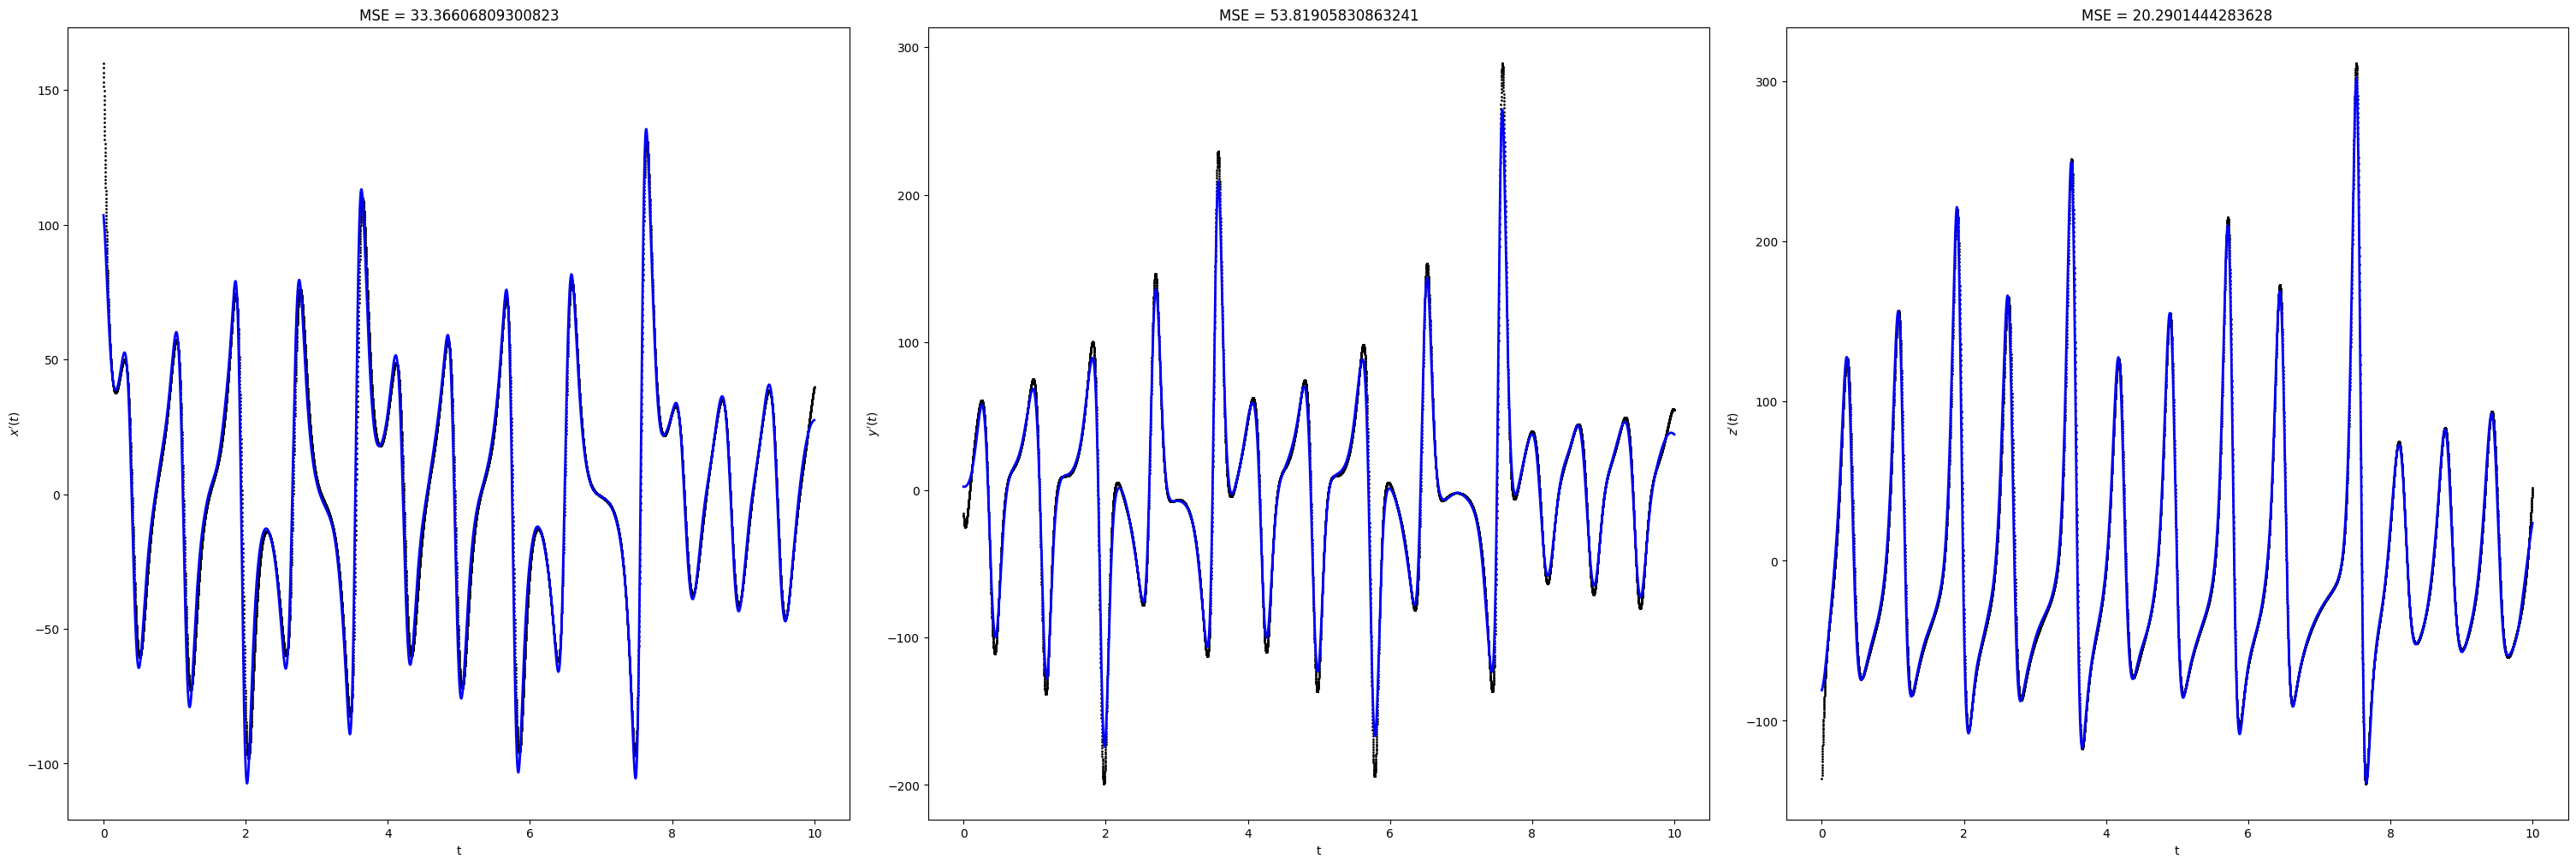

In [86]:
_, axes = plt.subplots(nrows=1, ncols=3, sharey=False, sharex=True, layout='constrained', figsize=(30,10))

mse = np.mean((mid_net_evals - sol_evals)**2, axis=0)

# print(np.mean(np.abs(x_net_evals - sol_evals[:,0]) / np.abs(sol_evals[:,0])))

# axes[0].plot(pnts, x_net_evals, 'b--', linewidth=2.0)
# axes[0].scatter(x=pnts, y=sol_evals[:,0], marker=',', s=4.0, color='k')
# axes[0].set_ylabel("x(t)")
# axes[0].set_xlabel("t")
# axes[0].set_title(f"MSE = {np.mean((x_net_evals - sol_evals[:,0:1])**2)}")

# axes[1].plot(pnts, y_net_evals, 'b--', linewidth=2.0)
# axes[1].scatter(x=pnts, y=sol_evals[:,1], marker=',', s=4.0, color='k')
# axes[1].set_ylabel("y(t)")
# axes[1].set_xlabel("t")
# axes[1].set_title(f"MSE = {np.mean((y_net_evals - sol_evals[:,1:2])**2)}")

# axes[2].plot(pnts, z_net_evals, 'b--', linewidth=2.0)
# axes[2].scatter(x=pnts, y=sol_evals[:,2], marker=',', s=4.0, color='k')
# axes[2].set_ylabel("z(t)")
# axes[2].set_xlabel("t")
# axes[2].set_title(f"MSE = {np.mean((z_net_evals - sol_evals[:,2:3])**2)}")


axes[0].plot(pnts, x_t_evals, 'b-', linewidth=2.0)
axes[0].scatter(x=pnts, y=sol_t[:,0], marker='.', s=4.0, color='k')
axes[0].set_ylabel(r"$x^{\prime}(t)$")
axes[0].set_xlabel("t")
axes[0].set_title(f"MSE = {np.mean((x_t_evals - sol_t[:,0:1])**2)}")

axes[1].plot(pnts, y_t_evals, 'b-', linewidth=2.0)
axes[1].scatter(x=pnts, y=sol_t[:,1], marker='.', s=4.0, color='k')
axes[1].set_ylabel(r"$y^{\prime}(t)$")
axes[1].set_xlabel("t")
axes[1].set_title(f"MSE = {np.mean((y_t_evals - sol_t[:,1:2])**2)}")

axes[2].plot(pnts, z_t_evals, 'b-', linewidth=2.0)
axes[2].scatter(x=pnts, y=sol_t[:,2], marker='.', s=4.0, color='k')
axes[2].set_ylabel(r"$z^{\prime}(t)$")
axes[2].set_xlabel("t")
axes[2].set_title(f"MSE = {np.mean((z_t_evals - sol_t[:,2:3])**2)}");

In [24]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=5_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_preds = x_net(col_pnts)
y_preds = y_net(col_pnts)
z_preds = z_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_preds, pts=col_pnts, orders=[1])
y_t = Nth_temporal_prtls(values=y_preds, pts=col_pnts, orders=[1])
z_t = Nth_temporal_prtls(values=z_preds, pts=col_pnts, orders=[1])

In [25]:
x_t - 10*(y_preds - x_preds)

tensor([[ 6.3343],
        [-0.9102],
        [ 0.6596],
        ...,
        [-1.1316],
        [16.3061],
        [ 1.9603]], device='cuda:0', grad_fn=<SubBackward0>)

In [26]:
torch.linalg.lstsq(torch.concat((x_preds, y_preds), axis=1), x_t)[0] 

tensor([[-11.6950],
        [ 11.4196]], device='cuda:0', grad_fn=<LinalgLstsqBackward0>)

In [27]:
torch.mean(x_t - torch.concat((x_preds, y_preds), axis=1) @ torch.linalg.lstsq(torch.concat((x_preds, y_preds), axis=1), x_t)[0] )

tensor(0.5475, device='cuda:0', grad_fn=<MeanBackward0>)

In [28]:
torch.mean(x_t - (11.2074*y_preds -11.4166*x_preds))

tensor(0.4010, device='cuda:0', grad_fn=<MeanBackward0>)

In [29]:
torch.linalg.lstsq(torch.concat((x_preds, y_preds, x_preds*z_preds), axis=1), y_t)[0] 

tensor([[21.5862],
        [ 0.9868],
        [-0.8491]], device='cuda:0', grad_fn=<LinalgLstsqBackward0>)

In [30]:
torch.linalg.lstsq(torch.concat((z_preds, x_preds*y_preds), axis=1), z_t)[0] 

tensor([[-2.7521],
        [ 1.0022]], device='cuda:0', grad_fn=<LinalgLstsqBackward0>)

In [32]:
torch.concat((x_lmbda, y_lmbda, z_lmbda), dim=1).detach()

tensor([[ 4.0340e-01,  4.0707e+00, -9.2039e-02],
        [ 2.8744e+00,  4.7646e+00, -3.6354e-02],
        [ 2.5258e-02,  9.4924e-01, -1.5027e+00],
        [-1.5245e-01, -3.3627e-01,  5.8244e-01],
        [ 2.2399e-01,  8.0272e-01,  4.4204e-01],
        [-3.5474e-01, -4.5489e-01,  1.5229e-02],
        [-8.6499e-02, -4.2701e-01,  1.0711e-01],
        [ 2.6247e-01,  2.9949e-02, -8.9014e-03],
        [-2.4602e-04, -1.8375e-02, -5.9674e-02]], device='cuda:0')

In [ ]:
extr_sprse_slvr = Cross_Val_RFE_V2(Kfolds=1, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=True,)
# extr_sprse_slvr = Cross_Val_RFE_V2(Kfolds=10, alpha=torch.zeros(size=(1,), device=dvc), normalize=True, annealing_factor=2, criteria="coefficient_value", selection="individual", best=False, ADO_iters=6, thrshld_val=1e-8)


In [34]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)
cmbnd_lmbdas = torch.concat((x_t, y_t, z_t), dim=1)

In [35]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [38]:
extr_sprse_slvr.solve(A = library, b=cmbnd_lmbdas[:,0:1])

tensor([[-2.6336],
        [ 6.0093],
        [ 0.0000],
        [-0.0186],
        [ 0.0000],
        [-0.2582],
        [ 0.0000],
        [ 0.1519],
        [ 0.0000]], device='cuda:0')

In [45]:
RFESparseRegression(A=library, b=x_t, annealing_factor=1, best=False)

tensor([[ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [ 0.0000],
        [-0.3786],
        [ 0.0000],
        [ 0.3978],
        [ 0.0000]], device='cuda:0')

In [43]:
x_lmbda.data = RFESparseRegression(A=library, b=x_t, annealing_factor=2, best=False)
y_lmbda.data = RFESparseRegression(A=library, b=y_t, annealing_factor=2, best=False)
z_lmbda.data = RFESparseRegression(A=library, b=z_t, annealing_factor=2, best=False)

In [44]:
(1-1e-3)*np.linspace(0,1,7)**0.5 + 1e-3

array([0.001     , 0.40884004, 0.57777292, 0.70739967, 0.81668008,
       0.91295806, 1.        ])

In [45]:
print(x_lmbda.data)
print(y_lmbda.data)
print(z_lmbda.data)

tensor([[-6.8490],
        [ 6.2724],
        [ 0.0000],
        [-0.0378],
        [ 0.0240],
        [-0.0999],
        [ 0.0000],
        [ 0.1460],
        [ 0.0000]], device='cuda:0')
tensor([[ 1.9211e+01],
        [ 3.8255e+00],
        [ 0.0000e+00],
        [ 2.2019e-02],
        [ 0.0000e+00],
        [-7.2492e-01],
        [ 5.8786e-03],
        [-1.7275e-01],
        [ 0.0000e+00]], device='cuda:0')
tensor([[ 0.0000],
        [ 0.0000],
        [-2.5368],
        [ 0.1785],
        [ 0.9591],
        [-0.0055],
        [-0.0414],
        [ 0.0000],
        [-0.0106]], device='cuda:0')


In [46]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)


x_nzs = [el.item() for el in x_lmbda.data[:,0].nonzero()]
y_nzs = [el.item() for el in y_lmbda.data[:,0].nonzero()]
z_nzs = [el.item() for el in z_lmbda.data[:,0].nonzero()]

In [47]:
print(x_nzs)
print(y_nzs)
print(z_nzs)

[0, 1, 3, 4, 5, 7]
[0, 1, 3, 5, 6, 7]
[2, 3, 4, 5, 6, 8]


In [48]:
optim_x = torch.optim.Adam(params=x_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_x.param_groups[0]['params'].append(x_lmbda)
optim_y = torch.optim.Adam(params=y_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_y.param_groups[0]['params'].append(y_lmbda)
optim_z = torch.optim.Adam(params=z_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_z.param_groups[0]['params'].append(z_lmbda)

In [49]:

for k in range(5_000):
    optim_x.zero_grad(None)
    optim_y.zero_grad(None)
    optim_z.zero_grad(None)
    x_net.train()
    y_net.train()
    z_net.train()

    x_d_loss = criteria(x_net(trn_x), trgts_x)
    y_d_loss = criteria(y_net(trn_y), trgts_y)
    z_d_loss = criteria(z_net(trn_z), trgts_z)

    x_col_vals = x_net(col_pnts)
    x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1])
    y_col_vals = y_net(col_pnts)
    y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1])
    z_col_vals = z_net(col_pnts)
    z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1])

    library  = torch.concat((x_col_vals, y_col_vals, z_col_vals, x_col_vals.pow(2), x_col_vals*y_col_vals, x_col_vals*z_col_vals,  y_col_vals.pow(2), y_col_vals*z_col_vals, z_col_vals.pow(2),), dim=1)

    x_eq_loss = criteria(x_t, library[:, x_nzs] @ x_lmbda[x_nzs])
    y_eq_loss = criteria(y_t, library[:, y_nzs] @ y_lmbda[y_nzs])
    z_eq_loss = criteria(z_t, library[:, z_nzs] @ z_lmbda[z_nzs])

    loss = x_d_loss + y_d_loss + z_d_loss + 0.40884004*x_eq_loss + 0.40884004*y_eq_loss + 0.40884004*z_eq_loss  
    loss.backward()

    optim_x.step()
    optim_y.step()
    optim_z.step()

    if (k+1)%500==0:
        x_net.eval()
        y_net.eval()
        z_net.eval()
        tst_loss = criteria(x_net(tst_x), tst_trgts_x).detach() + criteria(y_net(tst_y), tst_trgts_y).detach() + criteria(z_net(tst_z), tst_trgts_z).detach()
        print(tst_loss)

    

tensor(60.0174, device='cuda:0')
tensor(55.3858, device='cuda:0')
tensor(56.9332, device='cuda:0')
tensor(51.6140, device='cuda:0')
tensor(51.4989, device='cuda:0')
tensor(51.0726, device='cuda:0')
tensor(52.1083, device='cuda:0')
tensor(48.9572, device='cuda:0')
tensor(48.7688, device='cuda:0')
tensor(48.9499, device='cuda:0')


In [50]:
library[:, x_nzs] @ x_lmbda[x_nzs]

tensor([[-4.4022e+01],
        [ 3.3172e-02],
        [ 8.1745e+00],
        ...,
        [ 2.5378e+01],
        [-7.8128e+00],
        [-2.0065e+01]], device='cuda:0', grad_fn=<MmBackward0>)

In [53]:
z_lmbda[z_nzs]

tensor([[-1.5229],
        [ 0.0980],
        [ 0.8795],
        [-0.0510],
        [ 0.2438],
        [-0.0249]], device='cuda:0', grad_fn=<IndexBackward0>)

In [54]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)
cmbnd_lmbdas = torch.concat((x_t, y_t, z_t), dim=1)

In [55]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.4295e+00,  1.8909e+01,  0.0000e+00],
        [ 6.7614e+00,  3.5831e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00, -1.5229e+00],
        [ 1.0096e-01,  1.3560e-01,  9.8003e-02],
        [-2.8161e-02,  0.0000e+00,  8.7945e-01],
        [-2.1470e-02, -8.5073e-01, -5.1023e-02],
        [ 0.0000e+00, -5.6965e-02,  2.4376e-01],
        [-9.9394e-03, -5.9616e-02,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00, -2.4879e-02]], device='cuda:0')

In [59]:
x_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
x_lmbda.data[x_nzs] = RFESparseRegression(A=library[:, x_nzs], b=x_t, annealing_factor=2, best=False)
y_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
y_lmbda.data[y_nzs] = RFESparseRegression(A=library[:, y_nzs], b=y_t, annealing_factor=2, best=False)
z_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
z_lmbda.data[z_nzs] = RFESparseRegression(A=library[:, z_nzs], b=z_t, annealing_factor=2, best=False)

In [60]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.7753e+00,  1.9675e+01,  0.0000e+00],
        [ 6.8732e+00,  3.1375e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00, -1.8844e+00],
        [ 0.0000e+00,  0.0000e+00, -2.9211e-01],
        [ 0.0000e+00,  0.0000e+00,  9.9605e-01],
        [ 1.3709e-02, -8.4293e-01,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  2.6961e-01],
        [-2.0989e-02, -6.3412e-02,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00]], device='cuda:0')

In [62]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)


x_nzs = [el.item() for el in x_lmbda.data[:,0].nonzero()]
y_nzs = [el.item() for el in y_lmbda.data[:,0].nonzero()]
z_nzs = [el.item() for el in z_lmbda.data[:,0].nonzero()]

In [63]:
print(x_nzs)
print(y_nzs)
print(z_nzs)

[0, 1, 5, 7]
[0, 1, 5, 7]
[2, 3, 4, 6]


In [64]:
optim_x = torch.optim.Adam(params=x_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_x.param_groups[0]['params'].append(x_lmbda)
optim_y = torch.optim.Adam(params=y_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_y.param_groups[0]['params'].append(y_lmbda)
optim_z = torch.optim.Adam(params=z_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_z.param_groups[0]['params'].append(z_lmbda)

In [65]:

for k in range(5_000):
    optim_x.zero_grad(None)
    optim_y.zero_grad(None)
    optim_z.zero_grad(None)
    x_net.train()
    y_net.train()
    z_net.train()

    x_d_loss = criteria(x_net(trn_x), trgts_x)
    y_d_loss = criteria(y_net(trn_y), trgts_y)
    z_d_loss = criteria(z_net(trn_z), trgts_z)

    x_col_vals = x_net(col_pnts)
    x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1])
    y_col_vals = y_net(col_pnts)
    y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1])
    z_col_vals = z_net(col_pnts)
    z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1])

    library  = torch.concat((x_col_vals, y_col_vals, z_col_vals, x_col_vals.pow(2), x_col_vals*y_col_vals, x_col_vals*z_col_vals,  y_col_vals.pow(2), y_col_vals*z_col_vals, z_col_vals.pow(2),), dim=1)

    x_eq_loss = criteria(x_t, library[:, x_nzs] @ x_lmbda[x_nzs])
    y_eq_loss = criteria(y_t, library[:, y_nzs] @ y_lmbda[y_nzs])
    z_eq_loss = criteria(z_t, library[:, z_nzs] @ z_lmbda[z_nzs])

    loss = x_d_loss + y_d_loss + z_d_loss + 0.57777292*x_eq_loss + 0.57777292*y_eq_loss + 0.57777292*z_eq_loss  
    loss.backward()

    optim_x.step()
    optim_y.step()
    optim_z.step()

    if (k+1)%500==0:
        x_net.eval()
        y_net.eval()
        z_net.eval()
        tst_loss = criteria(x_net(tst_x), tst_trgts_x).detach() + criteria(y_net(tst_y), tst_trgts_y).detach() + criteria(z_net(tst_z), tst_trgts_z).detach()
        print(tst_loss)

    

tensor(66.4327, device='cuda:0')
tensor(65.2585, device='cuda:0')
tensor(65.5419, device='cuda:0')
tensor(61.9495, device='cuda:0')
tensor(64.2949, device='cuda:0')
tensor(62.3016, device='cuda:0')
tensor(61.2858, device='cuda:0')
tensor(62.5884, device='cuda:0')
tensor(59.5876, device='cuda:0')
tensor(59.2907, device='cuda:0')


In [66]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)
cmbnd_lmbdas = torch.concat((x_t, y_t, z_t), dim=1)

In [67]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.3097, 19.5112,  0.0000],
        [ 7.5887,  2.9545,  0.0000],
        [ 0.0000,  0.0000, -2.1723],
        [ 0.0000,  0.0000, -0.1957],
        [ 0.0000,  0.0000,  1.0472],
        [ 0.0279, -0.8639,  0.0000],
        [ 0.0000,  0.0000,  0.5882],
        [-0.0837, -0.0318,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

In [69]:
x_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
x_lmbda.data[x_nzs] = RFESparseRegression(A=library[:, x_nzs], b=x_t, annealing_factor=2, best=False)
y_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
y_lmbda.data[y_nzs] = RFESparseRegression(A=library[:, y_nzs], b=y_t, annealing_factor=2, best=False)
z_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
z_lmbda.data[z_nzs] = RFESparseRegression(A=library[:, z_nzs], b=z_t, annealing_factor=2, best=False)

In [71]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-5.5093, 20.4547,  0.0000],
        [ 7.1671,  2.1268,  0.0000],
        [ 0.0000,  0.0000, -2.3171],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.8059],
        [ 0.0000, -0.8975,  0.0000],
        [ 0.0000,  0.0000,  0.6989],
        [-0.0681,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

In [ ]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)


x_nzs = [el.item() for el in x_lmbda.data[:,0].nonzero()]
y_nzs = [el.item() for el in y_lmbda.data[:,0].nonzero()]
z_nzs = [el.item() for el in z_lmbda.data[:,0].nonzero()]

In [ ]:
optim_x = torch.optim.Adam(params=x_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_x.param_groups[0]['params'].append(x_lmbda)
optim_y = torch.optim.Adam(params=y_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_y.param_groups[0]['params'].append(y_lmbda)
optim_z = torch.optim.Adam(params=z_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_z.param_groups[0]['params'].append(z_lmbda)

In [73]:

for k in range(5_000):
    optim_x.zero_grad(None)
    optim_y.zero_grad(None)
    optim_z.zero_grad(None)
    x_net.train()
    y_net.train()
    z_net.train()

    x_d_loss = criteria(x_net(trn_x), trgts_x)
    y_d_loss = criteria(y_net(trn_y), trgts_y)
    z_d_loss = criteria(z_net(trn_z), trgts_z)

    x_col_vals = x_net(col_pnts)
    x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1])
    y_col_vals = y_net(col_pnts)
    y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1])
    z_col_vals = z_net(col_pnts)
    z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1])

    library  = torch.concat((x_col_vals, y_col_vals, z_col_vals, x_col_vals.pow(2), x_col_vals*y_col_vals, x_col_vals*z_col_vals,  y_col_vals.pow(2), y_col_vals*z_col_vals, z_col_vals.pow(2),), dim=1)

    x_eq_loss = criteria(x_t, library[:, x_nzs] @ x_lmbda[x_nzs])
    y_eq_loss = criteria(y_t, library[:, y_nzs] @ y_lmbda[y_nzs])
    z_eq_loss = criteria(z_t, library[:, z_nzs] @ z_lmbda[z_nzs])

    loss = x_d_loss + y_d_loss + z_d_loss + 0.70739967*x_eq_loss + 0.70739967*y_eq_loss + 0.70739967*z_eq_loss  
    loss.backward()

    optim_x.step()
    optim_y.step()
    optim_z.step()

    if (k+1)%500==0:
        x_net.eval()
        y_net.eval()
        z_net.eval()
        tst_loss = criteria(x_net(tst_x), tst_trgts_x).detach() + criteria(y_net(tst_y), tst_trgts_y).detach() + criteria(z_net(tst_z), tst_trgts_z).detach()
        print(tst_loss)

    

tensor(57.8104, device='cuda:0')
tensor(58.5870, device='cuda:0')
tensor(55.6852, device='cuda:0')
tensor(56.5711, device='cuda:0')
tensor(55.2752, device='cuda:0')
tensor(54.9387, device='cuda:0')
tensor(54.1612, device='cuda:0')
tensor(53.9838, device='cuda:0')
tensor(54.3274, device='cuda:0')
tensor(54.2489, device='cuda:0')


In [74]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)
cmbnd_lmbdas = torch.concat((x_t, y_t, z_t), dim=1)

In [ ]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-5.3973, 19.8612,  0.0000],
        [ 7.5888,  1.4934,  0.0000],
        [ 0.0000,  0.0000, -2.6255],
        [ 0.0000,  0.0000,  0.1362],
        [ 0.0000,  0.0000,  0.6810],
        [-0.0365, -0.8635,  0.0000],
        [ 0.0000,  0.0000,  0.7792],
        [-0.0577,  0.0296,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

In [76]:
x_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
x_lmbda.data[x_nzs] = RFESparseRegression(A=library[:, x_nzs], b=x_t, annealing_factor=2, best=False)
y_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
y_lmbda.data[y_nzs] = RFESparseRegression(A=library[:, y_nzs], b=y_t, annealing_factor=2, best=False)
z_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
z_lmbda.data[z_nzs] = RFESparseRegression(A=library[:, z_nzs], b=z_t, annealing_factor=2, best=False)

In [78]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.3987, 19.6276,  0.0000],
        [ 7.9448,  1.7984,  0.0000],
        [ 0.0000,  0.0000, -2.5590],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0379],
        [ 0.0000, -0.8397,  0.0000],
        [ 0.0000,  0.0000,  0.5828],
        [-0.0714,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

In [79]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)


x_nzs = [el.item() for el in x_lmbda.data[:,0].nonzero()]
y_nzs = [el.item() for el in y_lmbda.data[:,0].nonzero()]
z_nzs = [el.item() for el in z_lmbda.data[:,0].nonzero()]

In [80]:
optim_x = torch.optim.Adam(params=x_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_x.param_groups[0]['params'].append(x_lmbda)
optim_y = torch.optim.Adam(params=y_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_y.param_groups[0]['params'].append(y_lmbda)
optim_z = torch.optim.Adam(params=z_net.parameters(), lr=0.001, betas=(0.9, 0.999), )
optim_z.param_groups[0]['params'].append(z_lmbda)

In [ ]:

for k in range(5_000):
    optim_x.zero_grad(None)
    optim_y.zero_grad(None)
    optim_z.zero_grad(None)
    x_net.train()
    y_net.train()
    z_net.train()

    x_d_loss = criteria(x_net(trn_x), trgts_x)
    y_d_loss = criteria(y_net(trn_y), trgts_y)
    z_d_loss = criteria(z_net(trn_z), trgts_z)

    x_col_vals = x_net(col_pnts)
    x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1])
    y_col_vals = y_net(col_pnts)
    y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1])
    z_col_vals = z_net(col_pnts)
    z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1])

    library  = torch.concat((x_col_vals, y_col_vals, z_col_vals, x_col_vals.pow(2), x_col_vals*y_col_vals, x_col_vals*z_col_vals,  y_col_vals.pow(2), y_col_vals*z_col_vals, z_col_vals.pow(2),), dim=1)

    x_eq_loss = criteria(x_t, library[:, x_nzs] @ x_lmbda[x_nzs])
    y_eq_loss = criteria(y_t, library[:, y_nzs] @ y_lmbda[y_nzs])
    z_eq_loss = criteria(z_t, library[:, z_nzs] @ z_lmbda[z_nzs])

    loss = x_d_loss + y_d_loss + z_d_loss + 0.81668008*x_eq_loss + 0.81668008*y_eq_loss + 0.81668008*z_eq_loss  
    loss.backward()

    optim_x.step()
    optim_y.step()
    optim_z.step()

    if (k+1)%500==0:
        x_net.eval()
        y_net.eval()
        z_net.eval()
        tst_loss = criteria(x_net(tst_x), tst_trgts_x).detach() + criteria(y_net(tst_y), tst_trgts_y).detach() + criteria(z_net(tst_z), tst_trgts_z).detach()
        print(tst_loss)

    

tensor(57.8780, device='cuda:0')
tensor(57.0763, device='cuda:0')
tensor(55.7630, device='cuda:0')
tensor(55.2467, device='cuda:0')
tensor(74.5035, device='cuda:0')
tensor(57.1331, device='cuda:0')
tensor(56.8358, device='cuda:0')
tensor(58.1225, device='cuda:0')
tensor(54.1024, device='cuda:0')
tensor(54.0479, device='cuda:0')


In [82]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)
cmbnd_lmbdas = torch.concat((x_t, y_t, z_t), dim=1)

torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.4102, 19.4569,  0.0000],
        [ 8.0258,  1.7967,  0.0000],
        [ 0.0000,  0.0000, -2.4851],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.9135],
        [ 0.0000, -0.8290,  0.0000],
        [ 0.0000,  0.0000,  0.6667],
        [-0.0555,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

In [83]:
x_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
x_lmbda.data[x_nzs] = RFESparseRegression(A=library[:, x_nzs], b=x_t, annealing_factor=2, best=False)
y_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
y_lmbda.data[y_nzs] = RFESparseRegression(A=library[:, y_nzs], b=y_t, annealing_factor=2, best=False)
z_lmbda.data = torch.zeros((9,1), device=dvc, dtype=torch.float32)
z_lmbda.data[z_nzs] = RFESparseRegression(A=library[:, z_nzs], b=z_t, annealing_factor=2, best=False)

In [85]:
lib_names

['x', 'y', 'z', '(x)^2', '(x)(y)', '(x)(z)', '(y)^2', '(y)(z)', '(z)^2']

In [86]:
torch.concat((x_lmbda.data, y_lmbda.data, z_lmbda.data), dim=1)

tensor([[-6.4084, 19.8535,  0.0000],
        [ 8.1200,  1.6959,  0.0000],
        [ 0.0000,  0.0000, -2.5079],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.9237],
        [ 0.0000, -0.8389,  0.0000],
        [ 0.0000,  0.0000,  0.6655],
        [-0.0589,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]], device='cuda:0')

\begin{align*}
       x^{\prime}(t) &= -10x(t) + 10y(t)\\
       y^{\prime}(t) &=  28x(t) - y(t) + x(t)z(t)\\
       z^{\prime}(t) &= -2.66667z(t) + x(t)y(t)\\
\end{align*}

In [87]:
col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)


x_nzs = [el.item() for el in x_lmbda.data[:,0].nonzero()]
y_nzs = [el.item() for el in y_lmbda.data[:,0].nonzero()]
z_nzs = [el.item() for el in z_lmbda.data[:,0].nonzero()]

col_pnts = torch.from_numpy(col_smplr.sample(n_pnts=25_000)).to(device=dvc, dtype=torch.float32).requires_grad_(True)
x_col_vals = x_net(col_pnts)
x_t = Nth_temporal_prtls(values=x_col_vals, pts=col_pnts, orders=[1]).detach()
y_col_vals = y_net(col_pnts)
y_t = Nth_temporal_prtls(values=y_col_vals, pts=col_pnts, orders=[1]).detach()
z_col_vals = z_net(col_pnts)
z_t = Nth_temporal_prtls(values=z_col_vals, pts=col_pnts, orders=[1]).detach()

library  = torch.concat((x_col_vals.detach(), y_col_vals.detach(), z_col_vals.detach(), x_col_vals.detach().pow(2), x_col_vals.detach()*y_col_vals.detach(), x_col_vals.detach()*z_col_vals.detach(),  y_col_vals.detach().pow(2), y_col_vals.detach()*z_col_vals.detach(), z_col_vals.detach().pow(2),), dim=1)


# iter_lmbdas.append(torch.zeros(size= self.lmbda.data.size(), device=self.device, dtype=self.data_type))

model_losses = []
model_complxtys = []
model_scores = []


# need the complexity of each library term for choosing the best equation bellow. 
lib_complexities = np.array([1,1,1,3,3,3,3,3,3])
n_lib_trms = len(lib_names)
# need to store which equations were considered throughout the optimization steps and here. 
eqs_ids = [[np.arange(n_lib_trms)] for _ in range(n_trgts)]
pre_ids = [np.arange(n_lib_trms) for _ in range(n_trgts)]
eq_complexities = [[lib_complexities.sum().item() + n_lib_trms - 1] for _ in range(n_trgts)]
slctd_eqs_indices = []

regress_alphas = 0.0

        

In [91]:
RFESparseRegression(A=library[:,x_nzs], b=x_t, annealing_factor=1, best=False).cpu().numpy()

array([[-6.800544 ],
       [ 6.9785056],
       [ 0.       ]], dtype=float32)

In [88]:
Specified_Optim_Regres(A=library, b=x_t, activ_ids=x_nzs, alpha=regress_alphas).cpu().numpy()

array([[-6.408176  , -6.800544  ,  0.        ,  0.        ],
       [ 8.1205015 ,  6.9785056 ,  1.6765144 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-0.05892591,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]],
      dtype=float32)

In [92]:
RFESparseRegression(A=library[:,y_nzs], b=y_t, annealing_factor=1, best=False).cpu().numpy()

array([[23.55917  ],
       [ 0.       ],
       [-0.9123731]], dtype=float32)

In [89]:
Specified_Optim_Regres(A=library, b=y_t, activ_ids=y_nzs, alpha=regress_alphas).cpu().numpy()

array([[19.853556  , 23.559172  ,  0.        ,  0.        ],
       [ 1.6961237 ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-0.8389191 , -0.9123732 , -0.10755707,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]],
      dtype=float32)

In [93]:
RFESparseRegression(A=library[:,z_nzs], b=z_t, annealing_factor=1, best=False).cpu().numpy()

array([[-2.507891  ],
       [ 0.92359483],
       [ 0.6655227 ]], dtype=float32)

In [90]:
Specified_Optim_Regres(A=library, b=z_t, activ_ids=z_nzs, alpha=regress_alphas).cpu().numpy()

array([[ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [-2.507891  , -2.2088528 ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.92359483,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.6655227 ,  1.2618523 ,  0.6770963 ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]],
      dtype=float32)

In [94]:
tst_pnts = torch.from_numpy(pnts[tst_ids]).to(device=dvc, dtype=torch.float32).requires_grad_(True)
# tst_trgts_x = torch.from_numpy(sol_evals[tst_ids, 0:1]).to(device=dvc, dtype=torch.float32)
# tst_trgts_y = torch.from_numpy(sol_evals[tst_ids, 1:2]).to(device=dvc, dtype=torch.float32)
# tst_trgts_z = torch.from_numpy(sol_evals[tst_ids, 2:3]).to(device=dvc, dtype=torch.float32)



tst_x_col_vals = x_net(tst_pnts)
tst_x_t = Nth_temporal_prtls(values=tst_x_col_vals, pts=tst_pnts, orders=[1]).detach()
tst_y_col_vals = y_net(tst_pnts)
tst_y_t = Nth_temporal_prtls(values=tst_y_col_vals, pts=tst_pnts, orders=[1]).detach()
tst_z_col_vals = z_net(tst_pnts)
tst_z_t = Nth_temporal_prtls(values=tst_z_col_vals, pts=tst_pnts, orders=[1]).detach()

tst_library  = torch.concat((tst_x_t.detach(), tst_y_t.detach(), tst_z_t.detach(), tst_x_t.detach().pow(2), tst_x_t.detach()*tst_y_t.detach(), tst_x_t.detach()*tst_z_t.detach(),  tst_y_t.detach().pow(2), tst_y_t.detach()*tst_z_t.detach(), tst_z_t.detach().pow(2),), dim=1)


In [95]:
iter_lmbdas = [torch.tensor([[ 2.5640e-01,  4.0335e+00, -4.4547e-02],
                [ 2.5484e+00,  4.8129e+00,  5.7808e-02],
                [-6.0555e-02,  8.7732e-01, -1.4691e+00],
                [-8.3445e-02, -3.1840e-01,  5.5781e-01],
                [ 1.1850e-01,  7.0982e-01,  4.3059e-01],
                [-3.2131e-01, -4.2455e-01,  1.0355e-02],
                [-4.4897e-02, -3.7073e-01,  1.5789e-01],
                [ 2.5639e-01,  5.1931e-04, -8.7860e-03],
                [ 1.1865e-03, -1.3331e-02, -6.3130e-02]], device='cuda:0'),

        torch.tensor([[-6.4295e+00,  1.8909e+01,  0.0000e+00],
                [ 6.7614e+00,  3.5831e+00,  0.0000e+00],
                [ 0.0000e+00,  0.0000e+00, -1.5229e+00],
                [ 1.0096e-01,  1.3560e-01,  9.8003e-02],
                [-2.8161e-02,  0.0000e+00,  8.7945e-01],
                [-2.1470e-02, -8.5073e-01, -5.1023e-02],
                [ 0.0000e+00, -5.6965e-02,  2.4376e-01],
                [-9.9394e-03, -5.9616e-02,  0.0000e+00],
                [ 0.0000e+00,  0.0000e+00, -2.4879e-02]], device='cuda:0'),

        torch.tensor([[-6.3097, 19.5112,  0.0000],
                [ 7.5887,  2.9545,  0.0000],
                [ 0.0000,  0.0000, -2.1723],
                [ 0.0000,  0.0000, -0.1957],
                [ 0.0000,  0.0000,  1.0472],
                [ 0.0279, -0.8639,  0.0000],
                [ 0.0000,  0.0000,  0.5882],
                [-0.0837, -0.0318,  0.0000],
                [ 0.0000,  0.0000,  0.0000]], device='cuda:0'),

        torch.tensor([[-5.3973, 19.8612,  0.0000],
                [ 7.5888,  1.4934,  0.0000],
                [ 0.0000,  0.0000, -2.6255],
                [ 0.0000,  0.0000,  0.1362],
                [ 0.0000,  0.0000,  0.6810],
                [-0.0365, -0.8635,  0.0000],
                [ 0.0000,  0.0000,  0.7792],
                [-0.0577,  0.0296,  0.0000],
                [ 0.0000,  0.0000,  0.0000]], device='cuda:0'),

        torch.tensor([[-6.4102, 19.4569,  0.0000],
                [ 8.0258,  1.7967,  0.0000],
                [ 0.0000,  0.0000, -2.4851],
                [ 0.0000,  0.0000,  0.0000],
                [ 0.0000,  0.0000,  0.9135],
                [ 0.0000, -0.8290,  0.0000],
                [ 0.0000,  0.0000,  0.6667],
                [-0.0555,  0.0000,  0.0000],
                [ 0.0000,  0.0000,  0.0000]], device='cuda:0')]

In [98]:
eqs_ids = [[np.arange(n_lib_trms)] for _ in range(n_trgts)]
pre_ids = [np.arange(n_lib_trms) for _ in range(n_trgts)]
eq_complexities = [[lib_complexities.sum().item() + n_lib_trms - 1] for _ in range(n_trgts)]
slctd_eqs_indices = []

In [99]:
q=0

In [101]:
n_act_funcs = len(x_nzs)
# consider remaining models until the Null/Empty model. These are the extra lambdas.
extra_lmbdas = Specified_Optim_Regres(A=tst_library, b=tst_x_t, activ_ids=x_nzs, alpha=regress_alphas).cpu().numpy()
# last/remaining models
lst_models = np.reshape(extra_lmbdas, shape=(n_act_funcs*n_lib_trms + n_lib_trms,), order="F").reshape((n_act_funcs+1,n_lib_trms,1), order="C")
# all models considered throughout tryining/optim. step. 
# ado_models = np.concat((iter_lmbdas[:-1, :,q:q+1].detach().cpu().numpy(), lst_models), axis=0)
ado_models = np.concat(([lmb[:,0:0+1].detach().cpu().numpy() for lmb in iter_lmbdas[:-1]], lst_models), axis=0)
# get the complexity of each distinct model as it is possible to have some combination of the lib. funcs repeated 
# from one optim step to the next.
for lm in ado_models:
    idx = np.nonzero(lm[:,0])[0]    
    if idx.size==pre_ids[0].size:
        continue
    pre_ids[0] = idx
    eqs_ids[0].append(idx)
    eq_complexities[0].append(lib_complexities[idx].sum().item() + idx.size - 1)
# number of distinct library func. combinations. 
n_eqs = len(eqs_ids[0])
eq_losses = torch.empty(size=(n_eqs,), device=dvc, dtype=torch.float32)



In [109]:
for j in range(n_eqs):
    # Now get the equation coefficients for the each model and the loss on the test library. 
    # eq_coefs = torch.linalg.lstsq(lib_evals[:,eqs_ids[q][j]],t_prtls[:,q:q+1])[0]
    eq_coefs = solve_svd(library[:,eqs_ids[q][j]],x_t[:,q:q+1], alphas=regress_alphas)
    eq_losses[j] = torch.mean( (tst_library[:,eqs_ids[q][j]]@eq_coefs -tst_x_t[:,q:q+1] ) **2 )

eq_lsses = eq_losses.cpu().numpy()
model_complexities = np.asarray(eq_complexities[q])
# flippig the order of the matrix valyes since want the complexity to increase as we go down across (-->) matrix
# so model loss will then decrease as we get more and more complex equation (reading complexity vs loss curver right left. )
flppd_eq_losses = np.flipud(eq_lsses)
model_losses.append(flppd_eq_losses)
flppd_model_cmplx = np.flipud(model_complexities)
model_complxtys.append(flppd_model_cmplx)
# if this is not done, the complexity of the null/empty model is -1 : so make it 0 as no model had no complexity. 
# flppd_model_cmplx[0] = np.int64(0)
scores = -np.log(flppd_eq_losses[1:]/flppd_eq_losses[:-1]) / (flppd_model_cmplx[1:] - flppd_model_cmplx[:-1])
model_scores.append(scores)
max_scr_idx = scores.argmax()+1
slctd_eqs_indices.append(eqs_ids[q][len(eqs_ids[q]) - max_scr_idx-1])

In [111]:
scores

array([ 1.43787963e-02, -2.11545801e+00, -6.90904483e-02,  8.31973506e-04,
        3.38087295e-04,  5.53174131e-04])

In [115]:
print(eqs_ids[0])
print(eq_lsses)

[array([0, 1, 2, 3, 4, 5, 6, 7, 8]), array([0, 1, 3, 4, 5, 7]), array([0, 1, 5, 7]), array([0, 1, 7]), array([0, 1]), array([0]), array([], dtype=int64)]
[44484.184   44730.94    44852.09    45001.6     34135.445     496.29758
   510.7771 ]


In [114]:
flppd_eq_losses[1:]/flppd_eq_losses[:-1]

array([ 0.971652  , 68.7802    ,  1.3183247 ,  0.99667764,  0.99729896,
        0.99448353], dtype=float32)

In [113]:
flppd_model_cmplx[1:] - flppd_model_cmplx[:-1]

array([ 2,  2,  4,  4,  8, 10])

In [ ]:
for q in range(n_trgts):
    # recall each of the n targeted equation might have a different number of functions selected after optimization step. 
    n_act_funcs = len(nzs[q])
    # since the library should be greated culled after the K optim step, just do a greedy sparse regression to 
    # consider remaining models until the Null/Empty model. These are the extra lambdas.
    extra_lmbdas = Specified_Optim_Regres(A=lib_evals, b=t_prtls, activ_ids=nzs[q], alpha=regress_alphas).cpu().numpy()
    # last/remaining models
    lst_models = np.reshape(extra_lmbdas, shape=(n_act_funcs*n_lib_trms + n_lib_trms,), order="F").reshape((n_act_funcs+1,n_lib_trms,1), order="C")
    # all models considered throughout tryining/optim. step. 
    # ado_models = np.concat((iter_lmbdas[:-1, :,q:q+1].detach().cpu().numpy(), lst_models), axis=0)
    ado_models = np.concat(([lmb[:,q:q+1].detach().cpu().numpy() for lmb in iter_lmbdas[:-1]], lst_models), axis=0)
    # get the complexity of each distinct model as it is possible to have some combination of the lib. funcs repeated 
    # from one optim step to the next.
    for lm in ado_models:
        idx = np.nonzero(lm[:,0])[0]    
        if idx.size==pre_ids[q].size:
            continue
        pre_ids[q] = idx
        eqs_ids[q].append(idx)
        eq_complexities[q].append(lib_complexities[idx].sum().item() + idx.size - 1)
    # number of distinct library func. combinations. 
    n_eqs = len(eqs_ids[q])
    eq_losses = torch.empty(size=(n_eqs,), device=dvc, dtype=torch.float32)
    
    for j in range(n_eqs):
        # Now get the equation coefficients for the each model and the loss on the test library. 
        # eq_coefs = torch.linalg.lstsq(lib_evals[:,eqs_ids[q][j]],t_prtls[:,q:q+1])[0]
        eq_coefs = solve_svd(lib_evals[:,eqs_ids[q][j]],t_prtls[:,q:q+1], alphas=regress_alphas)
        eq_losses[j] = torch.mean( (tst_lib_evals[:,eqs_ids[q][j]]@eq_coefs -tst_t_prtls[:,q:q+1] ) **2 )
    
    eq_lsses = eq_losses.cpu().numpy()
    model_complexities = np.asarray(eq_complexities[q])
    # flippig the order of the matrix valyes since want the complexity to increase as we go down across (-->) matrix
    # so model loss will then decrease as we get more and more complex equation (reading complexity vs loss curver right left. )
    flppd_eq_losses = np.flipud(eq_lsses)
    model_losses.append(flppd_eq_losses)
    flppd_model_cmplx = np.flipud(model_complexities)
    model_complxtys.append(flppd_model_cmplx)
    # if this is not done, the complexity of the null/empty model is -1 : so make it 0 as no model had no complexity. 
    # flppd_model_cmplx[0] = np.int64(0)
    scores = -np.log(flppd_eq_losses[1:]/flppd_eq_losses[:-1]) / (flppd_model_cmplx[1:] - flppd_model_cmplx[:-1])
    model_scores.append(scores)
    max_scr_idx = scores.argmax()+1
    slctd_eqs_indices.append(eqs_ids[q][len(eqs_ids[q]) - max_scr_idx-1])